# Unfactorized attention model for realistic data

In [52]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
import os
import seaborn as sns
import string
from matplotlib.patches import Rectangle

In [53]:
run_id = "20251217_1517" # sans mask
# run_id = "20251217_1517" # avec mask
# run_id = "20251217_1517" # S sym 

run_dir = f"../results/run_{run_id}/"
config_path = f"../results/run_{run_id}/config.csv"
base_path = f"../results/run_{run_id}/summary.csv"

plot_path = f"../results/run_{run_id}/plots/"
os.makedirs(plot_path, exist_ok=True)

In [54]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'figure.dpi': 300,
    'savefig.bbox': 'tight',
})

## 1. experiment config

In [55]:
# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

⚙️ Config loaded (15 rows) from ../results/run_20251217_1517/config.csv


,D,L,T,d_mlp_list,alpha,rho,beta,lambda_candidates,k_folds,samples,...,run_index,seed,batch_size,R,N_alpha,N_ft,N_train,N,MLP_dim,lambda
0,100,15,30,[100],0.010000,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,0,42,64,100,100,0,100,2100,100,0.00010
1,100,15,30,[100],0.151429,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,2,42,64,100,1514,0,1514,3514,100,0.00010
2,100,15,30,[100],0.080714,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,1,42,64,100,807,0,807,2807,100,0.00010
3,100,15,30,[100],0.222143,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,3,42,64,100,2221,0,2221,4221,100,0.00001
4,100,15,30,[100],0.434286,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,6,42,64,100,4342,0,4342,6342,100,0.00010
5,100,15,30,[100],0.363571,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,5,42,64,100,3635,0,3635,5635,100,0.00001
6,100,15,30,[100],0.505000,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,7,42,64,100,5050,0,5050,7050,100,0.00001
7,100,15,30,[100],0.292857,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,4,42,64,100,2928,0,2928,4928,100,0.00001
8,100,15,30,[100],0.575714,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,8,42,64,100,5757,0,5757,7757,100,0.00001
9,100,15,30,[100],0.858571,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,12,42,64,100,8585,0,8585,10585,100,0.00001


## 2. Metrics for parameters ($\alpha$, $d_{MLP}$, $p_{ft}$)

✅ Summary loaded (15 rows) from ../results/run_20251217_1517/summary.csv


,alpha,MLP_dim,rho,p_ft,lamda,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,...,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.010000,100,1.0,0.0,0.00010,0.784717,0.020970,0.000047,0.000023,0.000070,...,0.215283,0.020970,NaN,NaN,0.825830,0.217864,100.0,0.000000,100.0,0.000000
1,0.151429,100,1.0,0.0,0.00010,0.515765,0.049527,0.000125,0.000020,0.000145,...,0.484235,0.049527,NaN,NaN,0.531923,0.051794,98.5,0.707107,98.5,0.707107
2,0.080714,100,1.0,0.0,0.00010,0.539913,0.095058,0.000112,0.000024,0.000136,...,0.460087,0.095058,NaN,NaN,0.565409,0.136588,98.8,1.398412,98.8,1.398412
3,0.222143,100,1.0,0.0,0.00001,0.442643,0.066018,0.000105,0.000009,0.000113,...,0.557357,0.066018,NaN,NaN,0.605441,0.068364,99.5,0.527046,99.5,0.527046
4,0.434286,100,1.0,0.0,0.00010,0.430325,0.070167,0.000113,0.000024,0.000137,...,0.569675,0.070167,NaN,NaN,0.579738,0.067375,97.9,1.595131,97.9,1.595131


✅ Summary loaded (15 rows)
✅ Saved plot: ../results/run_20251217_1517/plots/label_error_vs_alpha_run20251217_1517.png


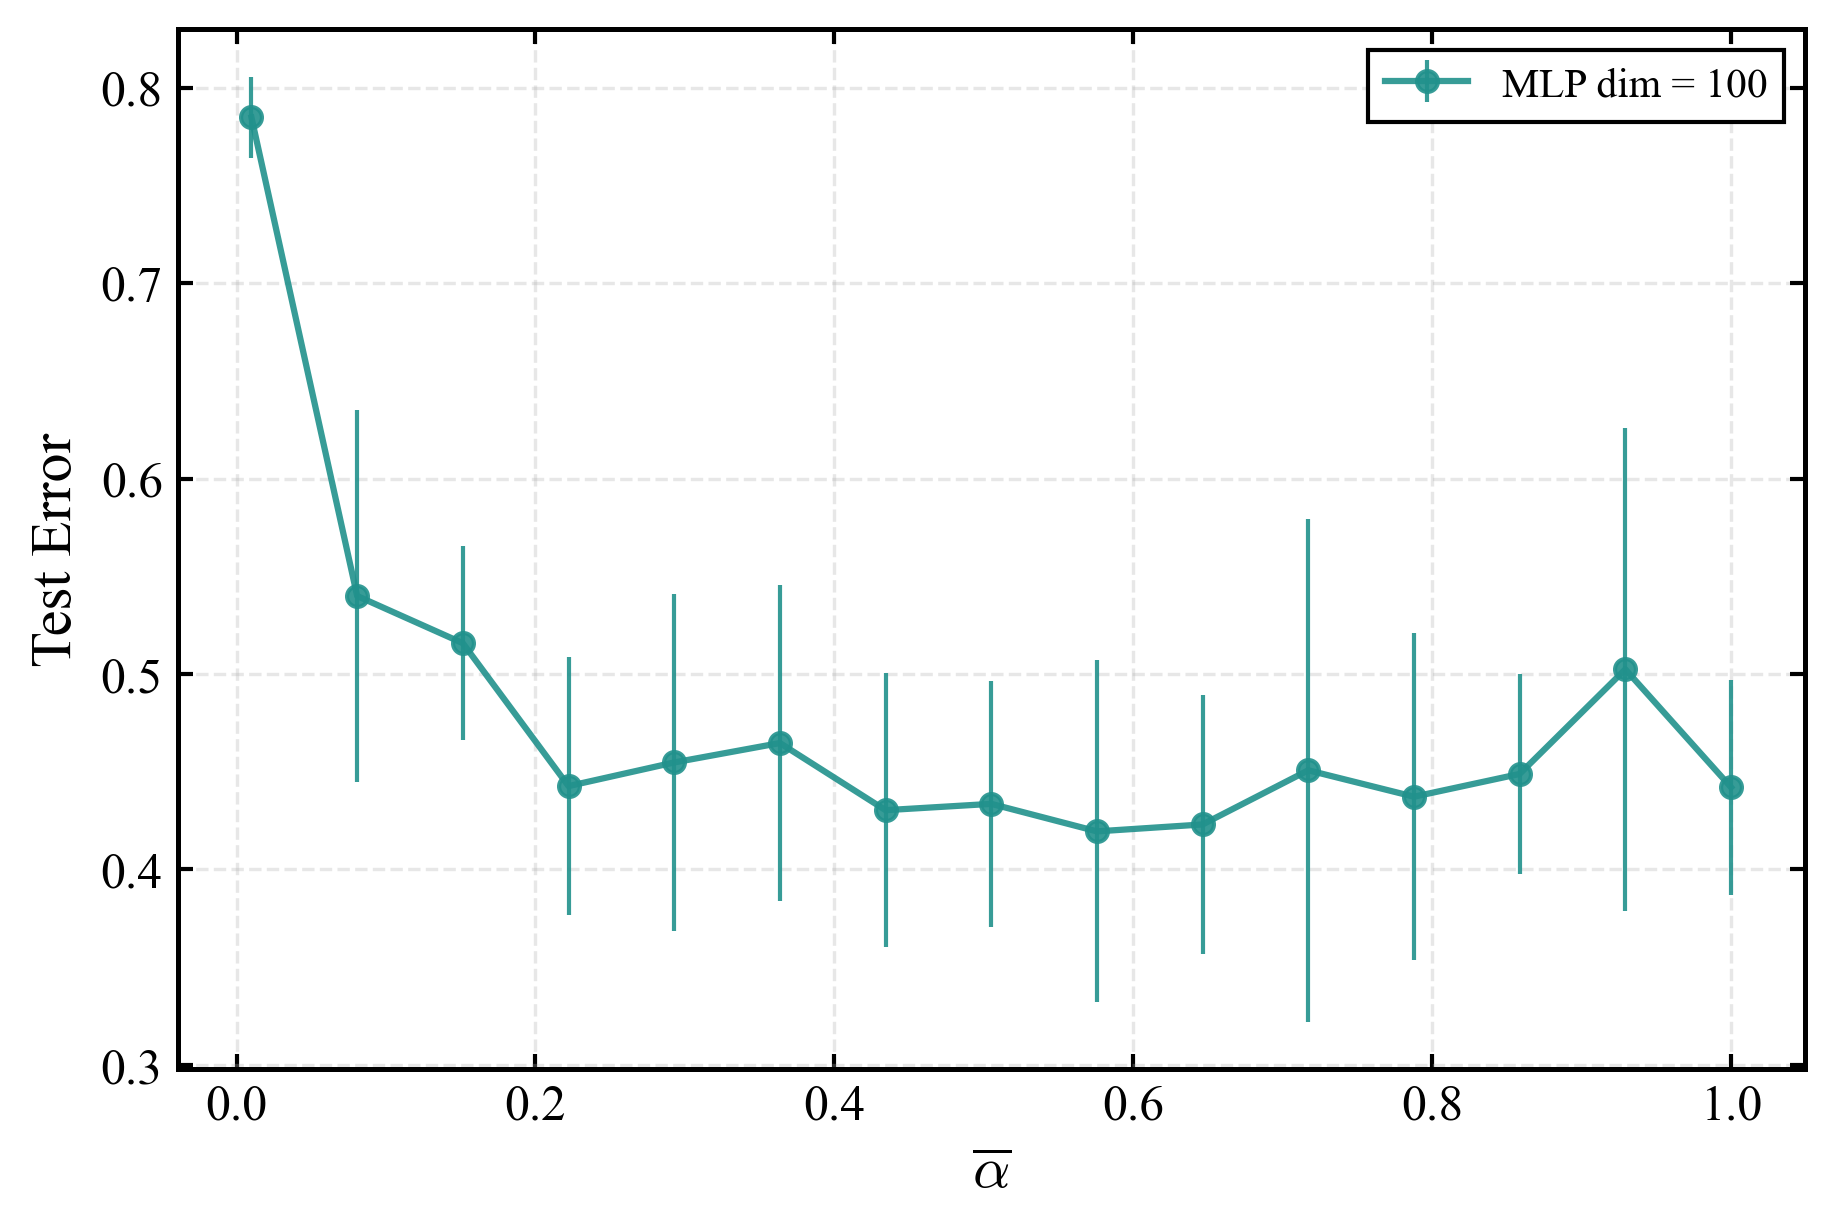

✅ Saved plot: ../results/run_20251217_1517/plots/train_data_vs_alpha_run20251217_1517.png


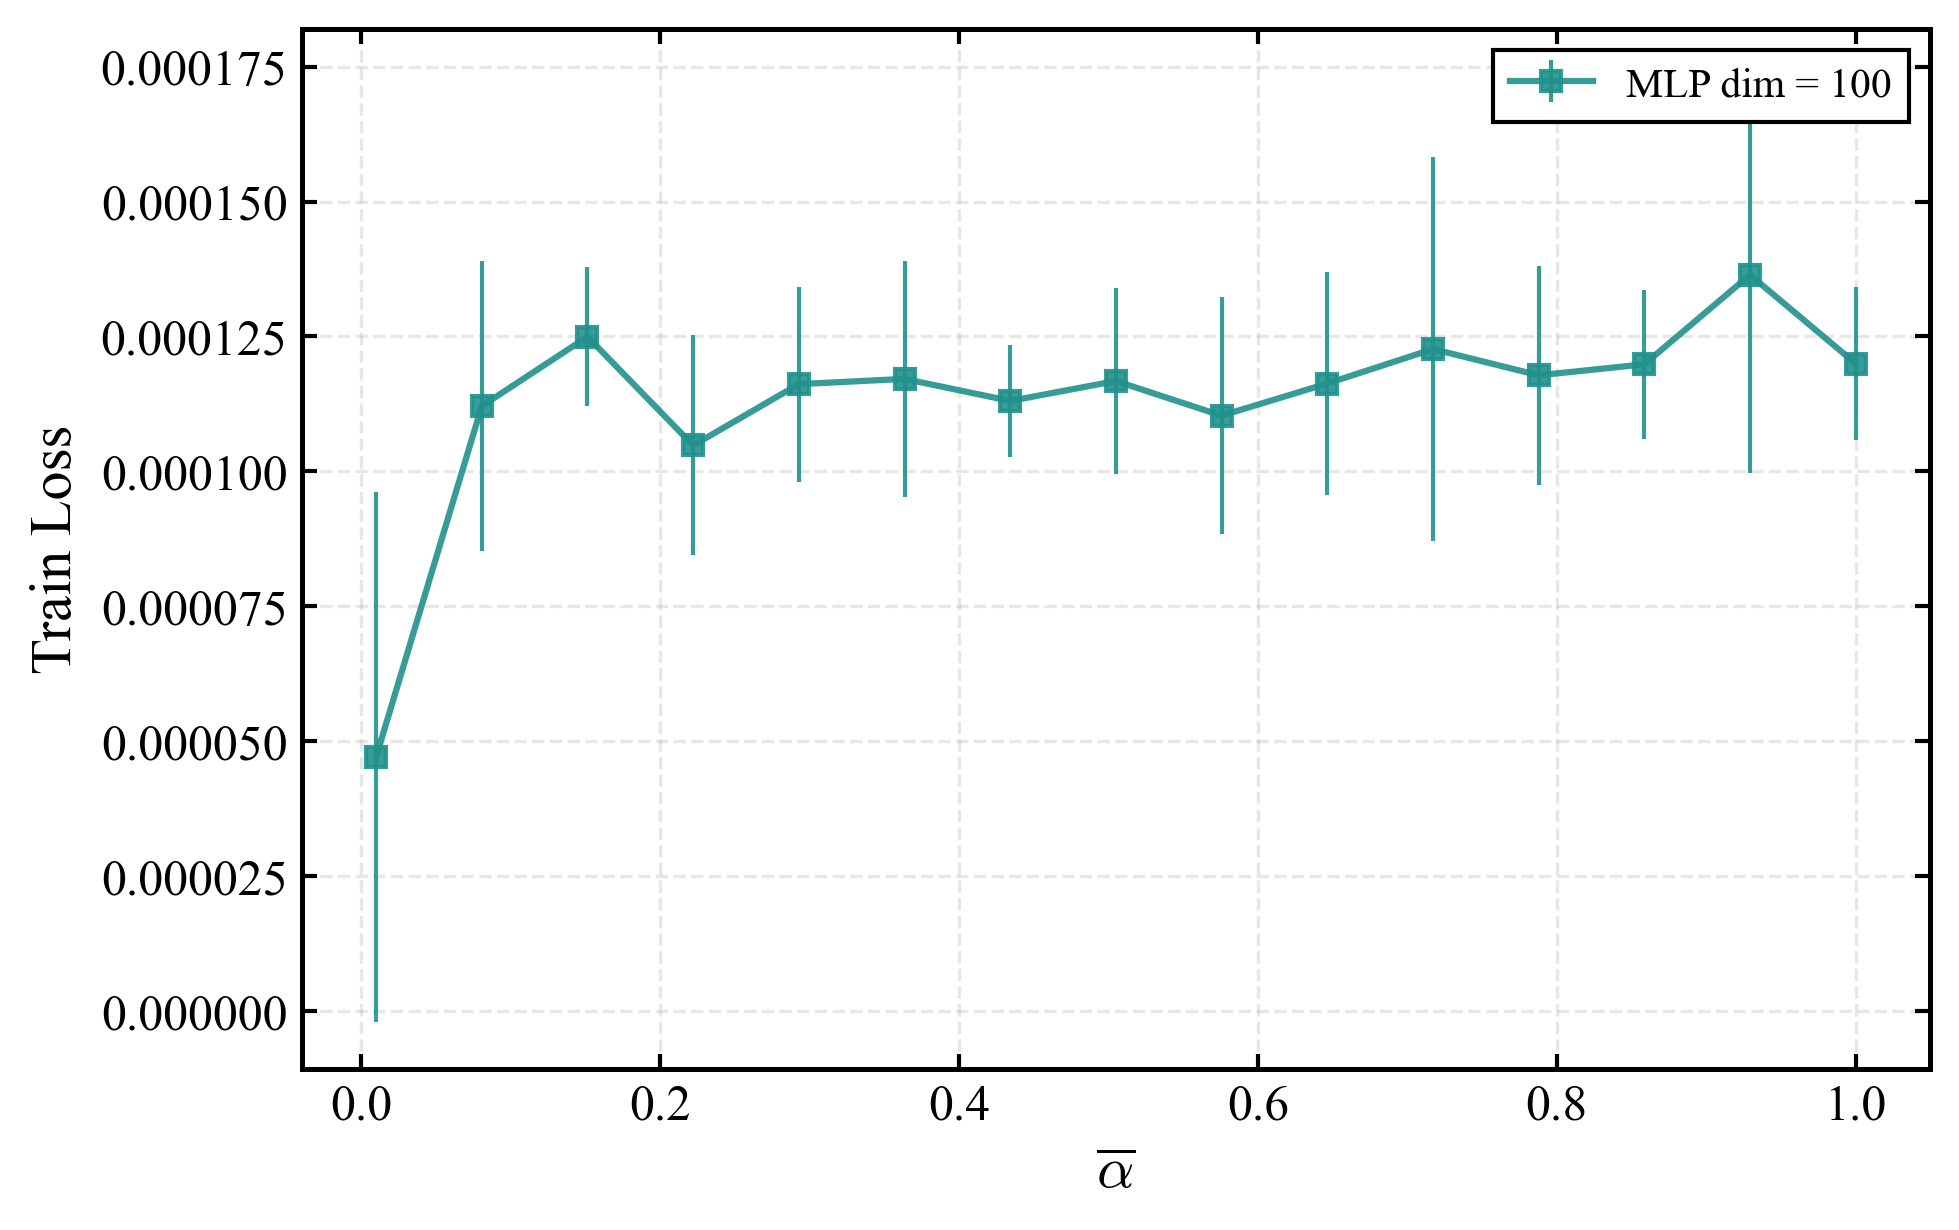

✅ Saved plot: ../results/run_20251217_1517/plots/train_accuracy_vs_alpha_run20251217_1517.png


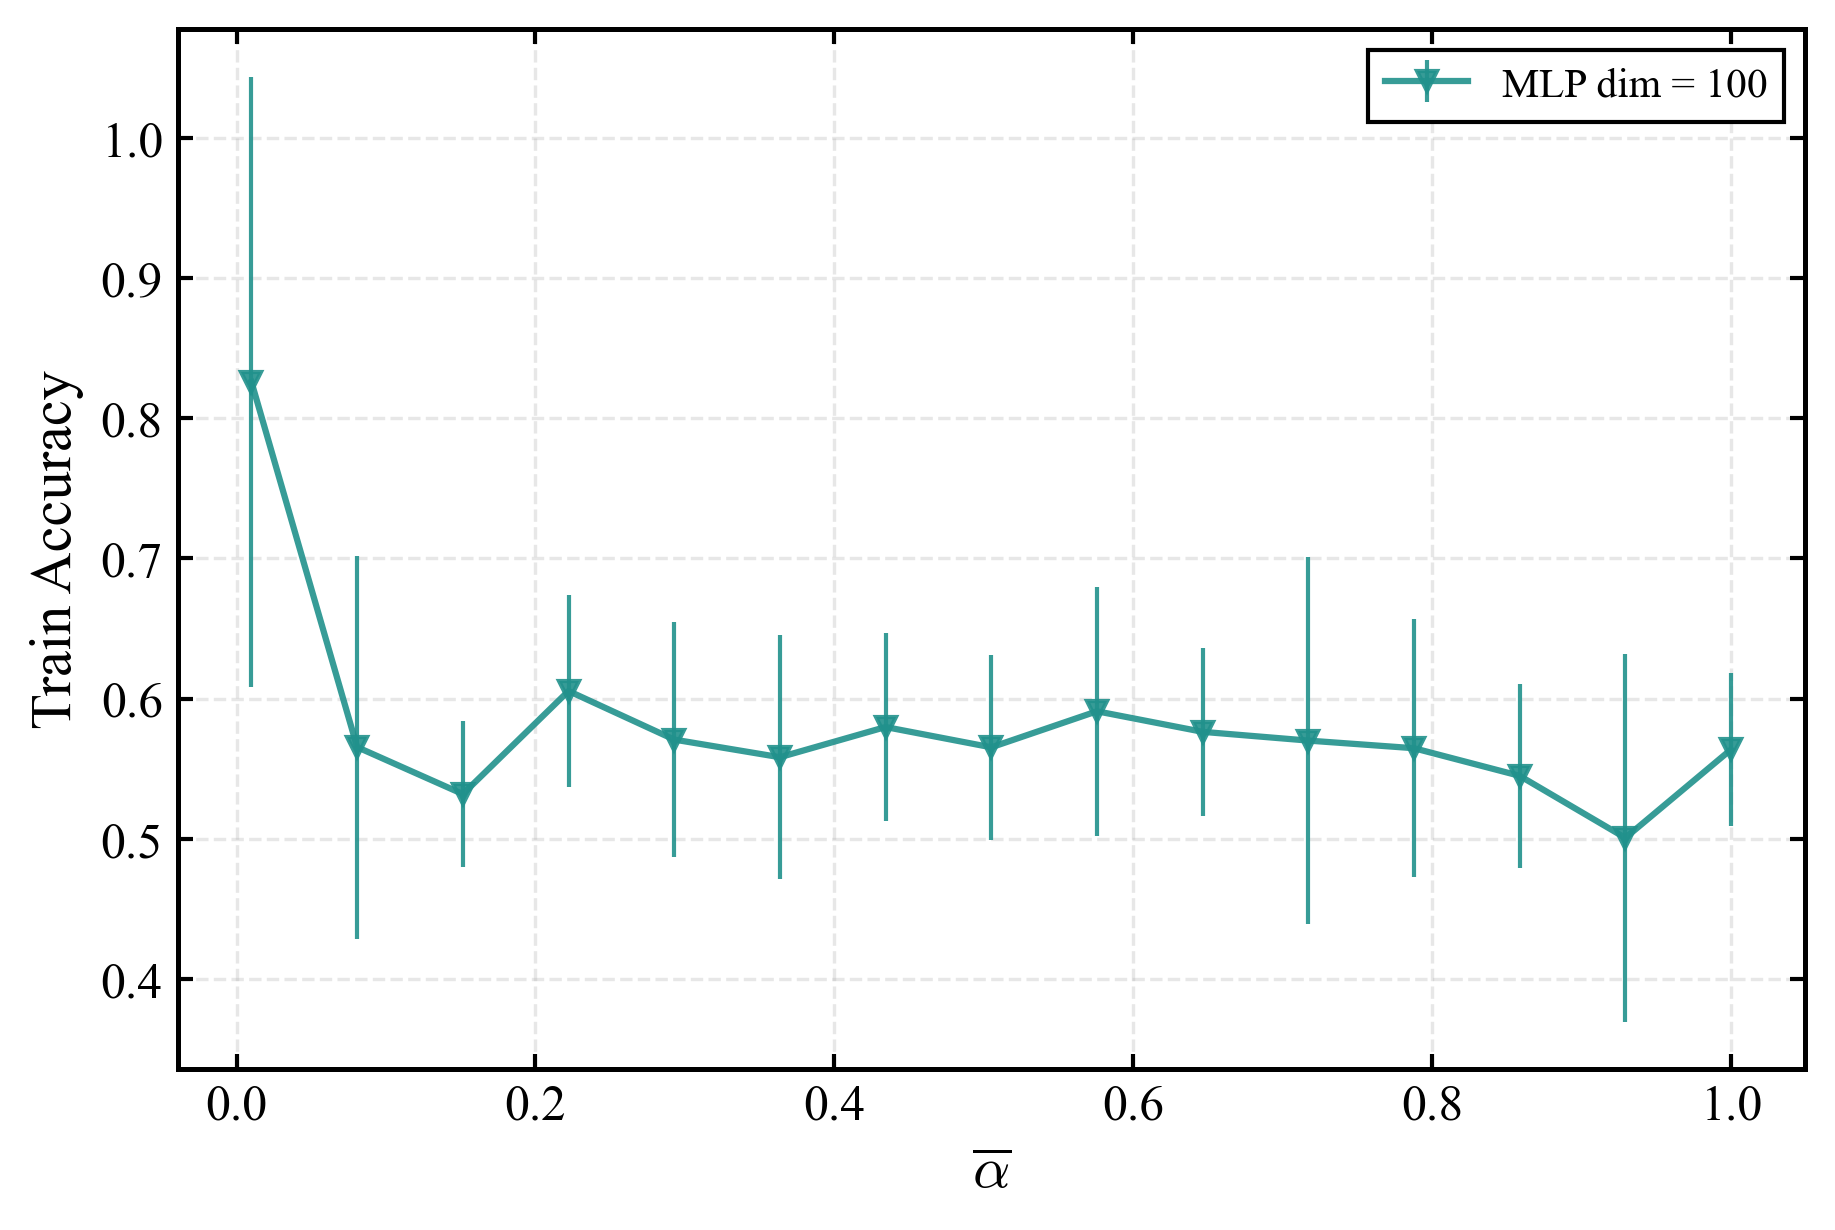

✅ Saved plot: ../results/run_20251217_1517/plots/fine_tune_accuracy_vs_alpha_run20251217_1517.png


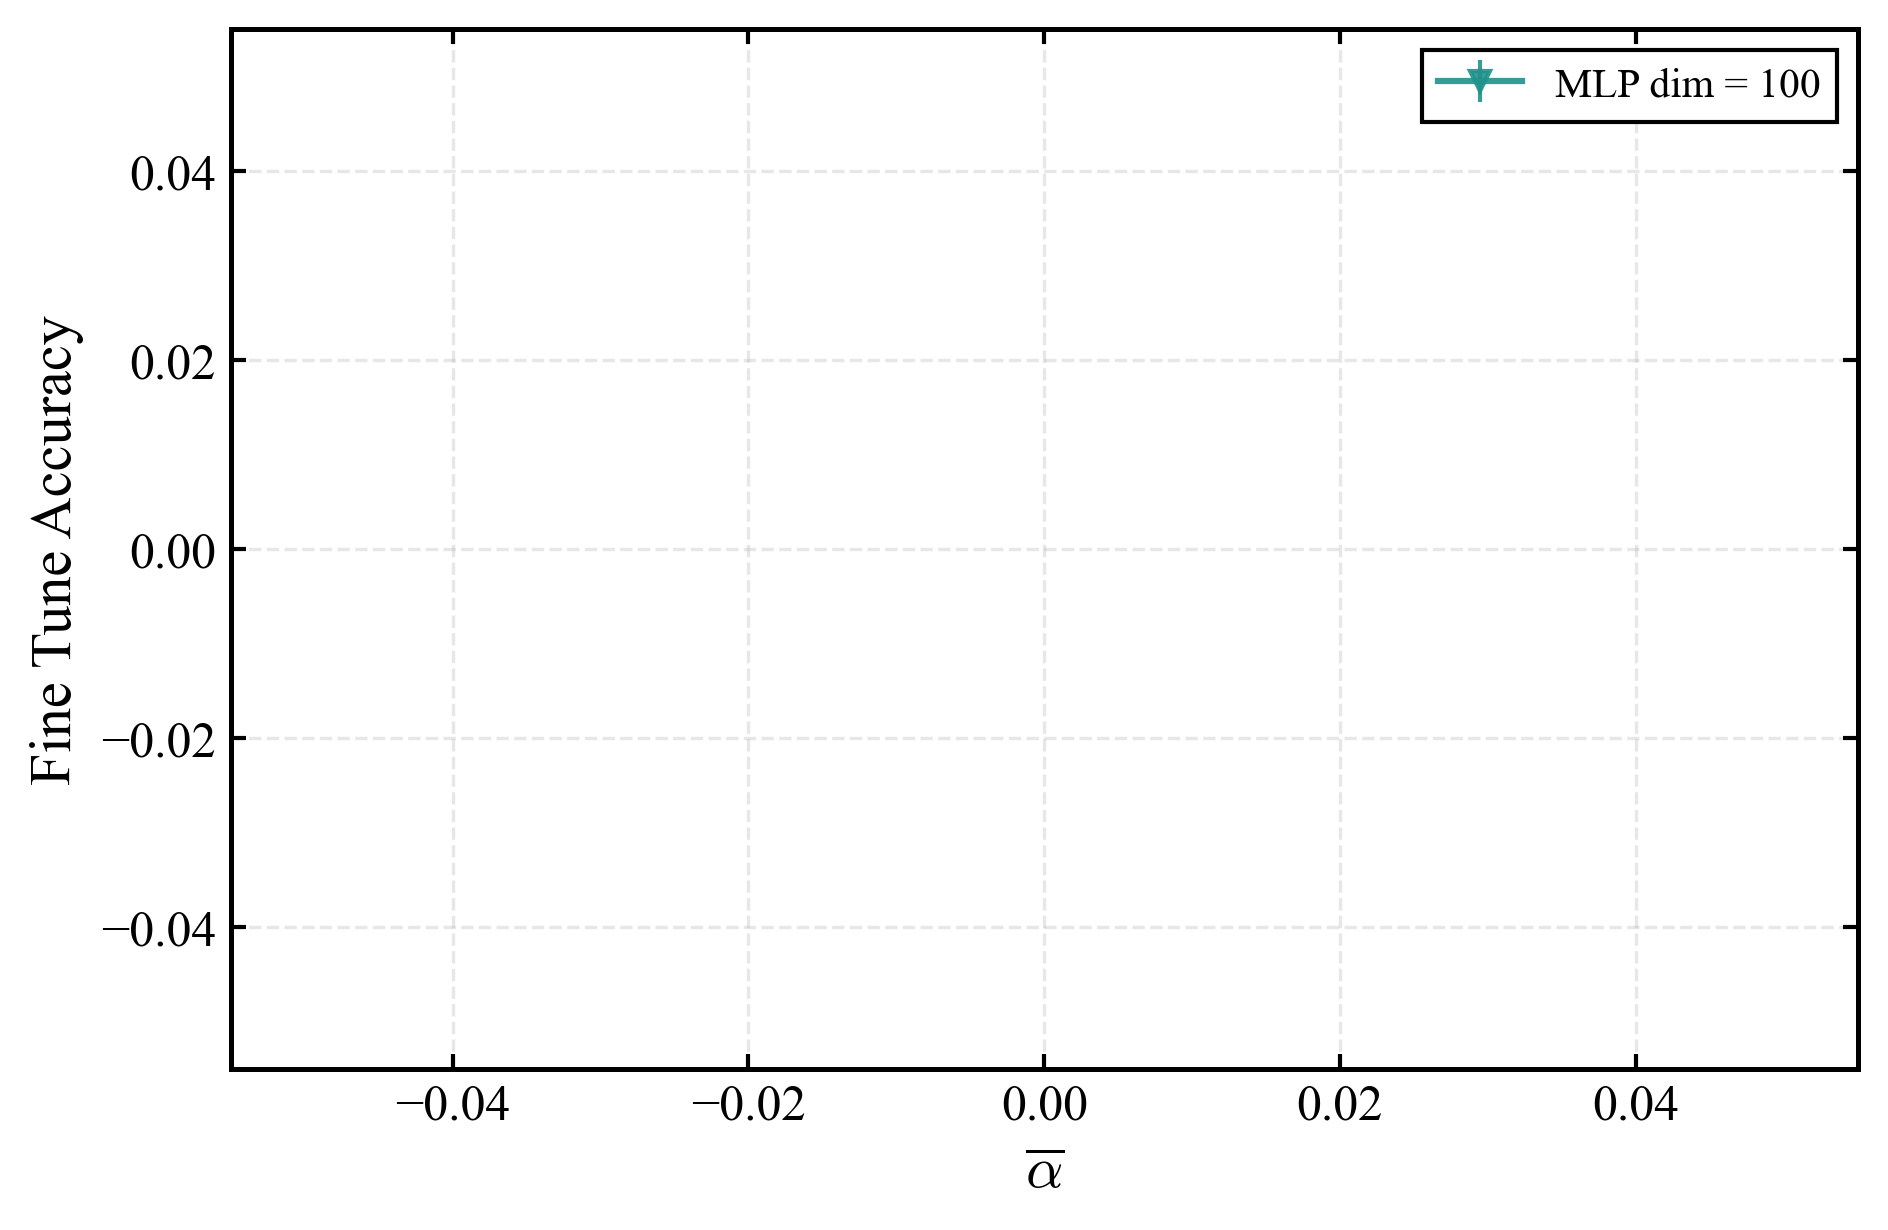

✅ Saved plot: ../results/run_20251217_1517/plots/test_accuracy_vs_alpha_run20251217_1517.png


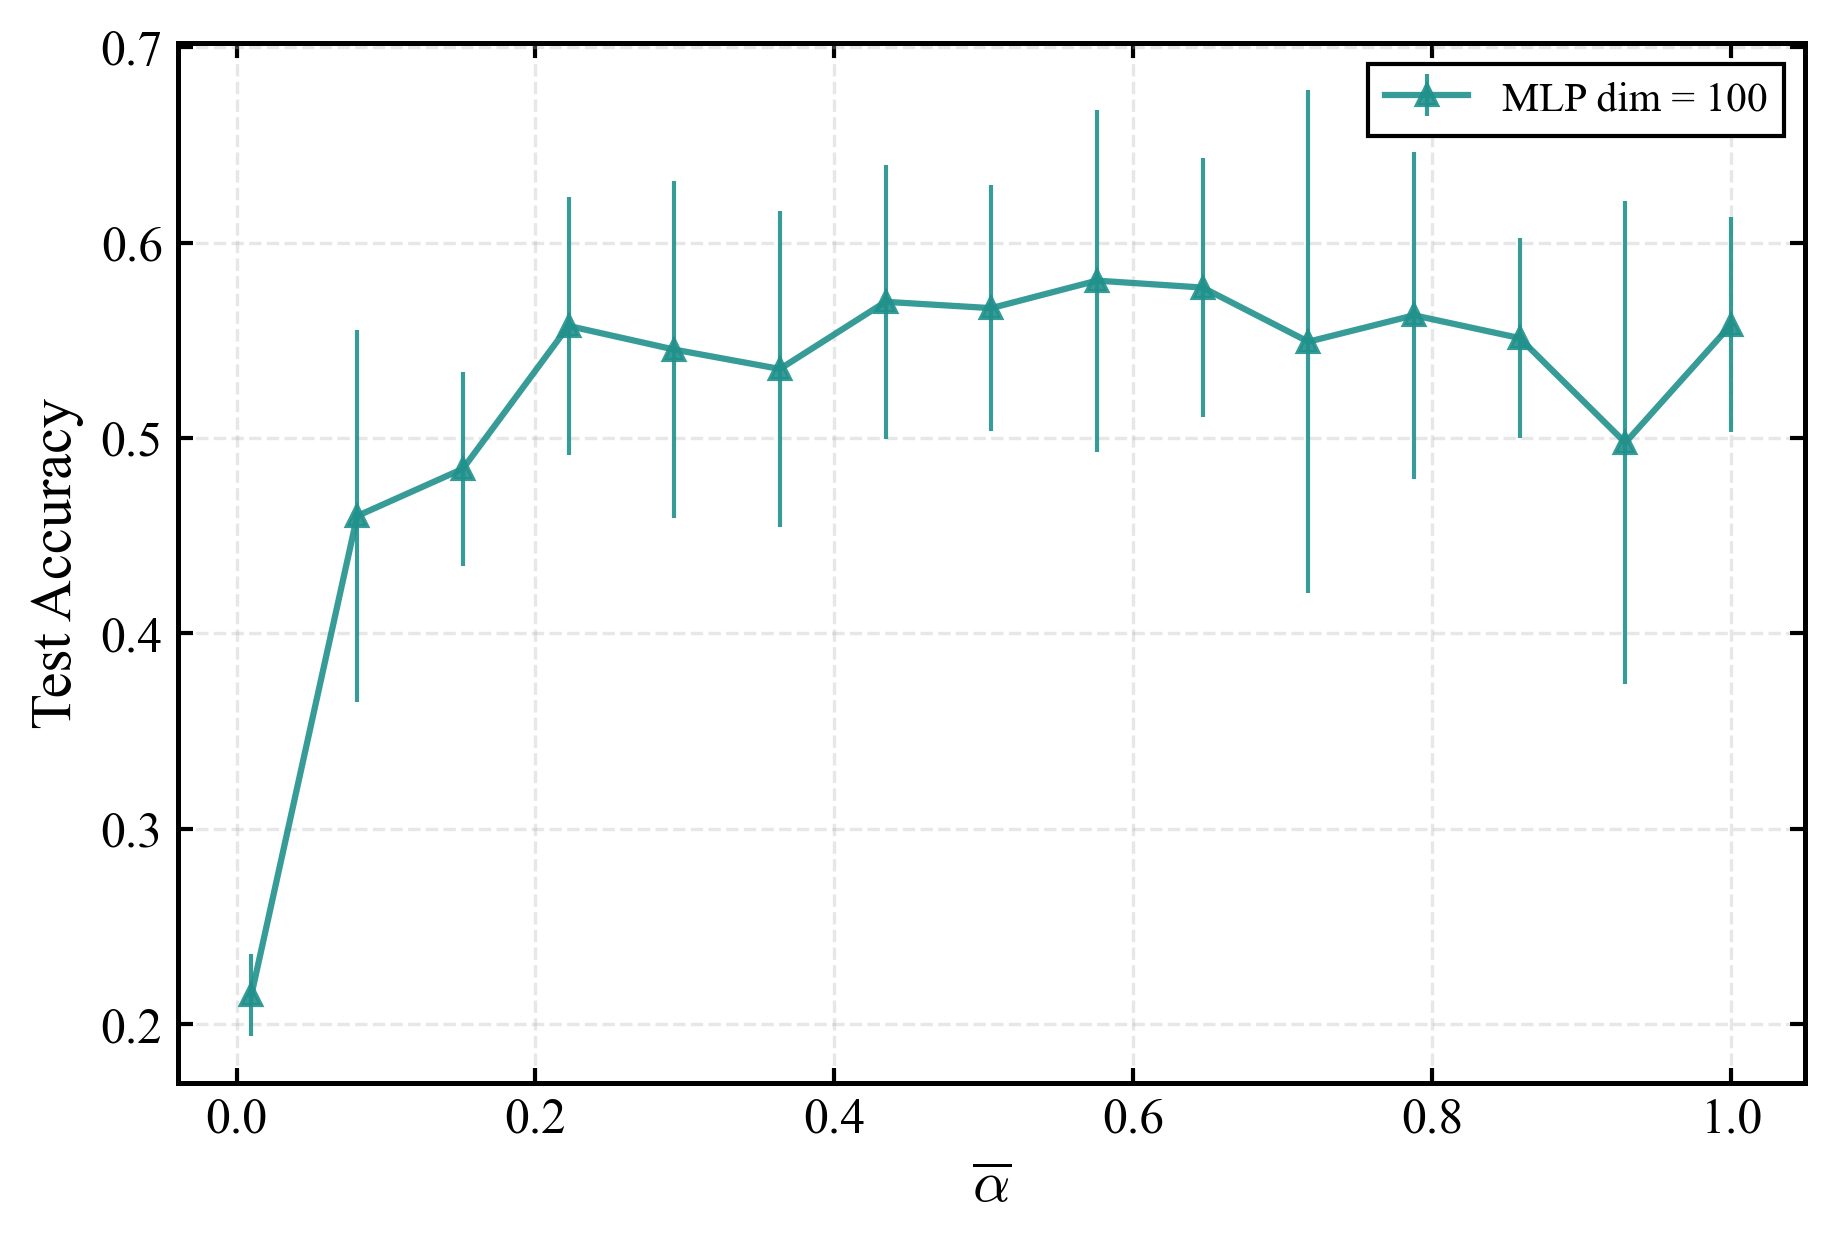

✅ Saved plot: ../results/run_20251217_1517/plots/rank_before_vs_alpha_run20251217_1517.png


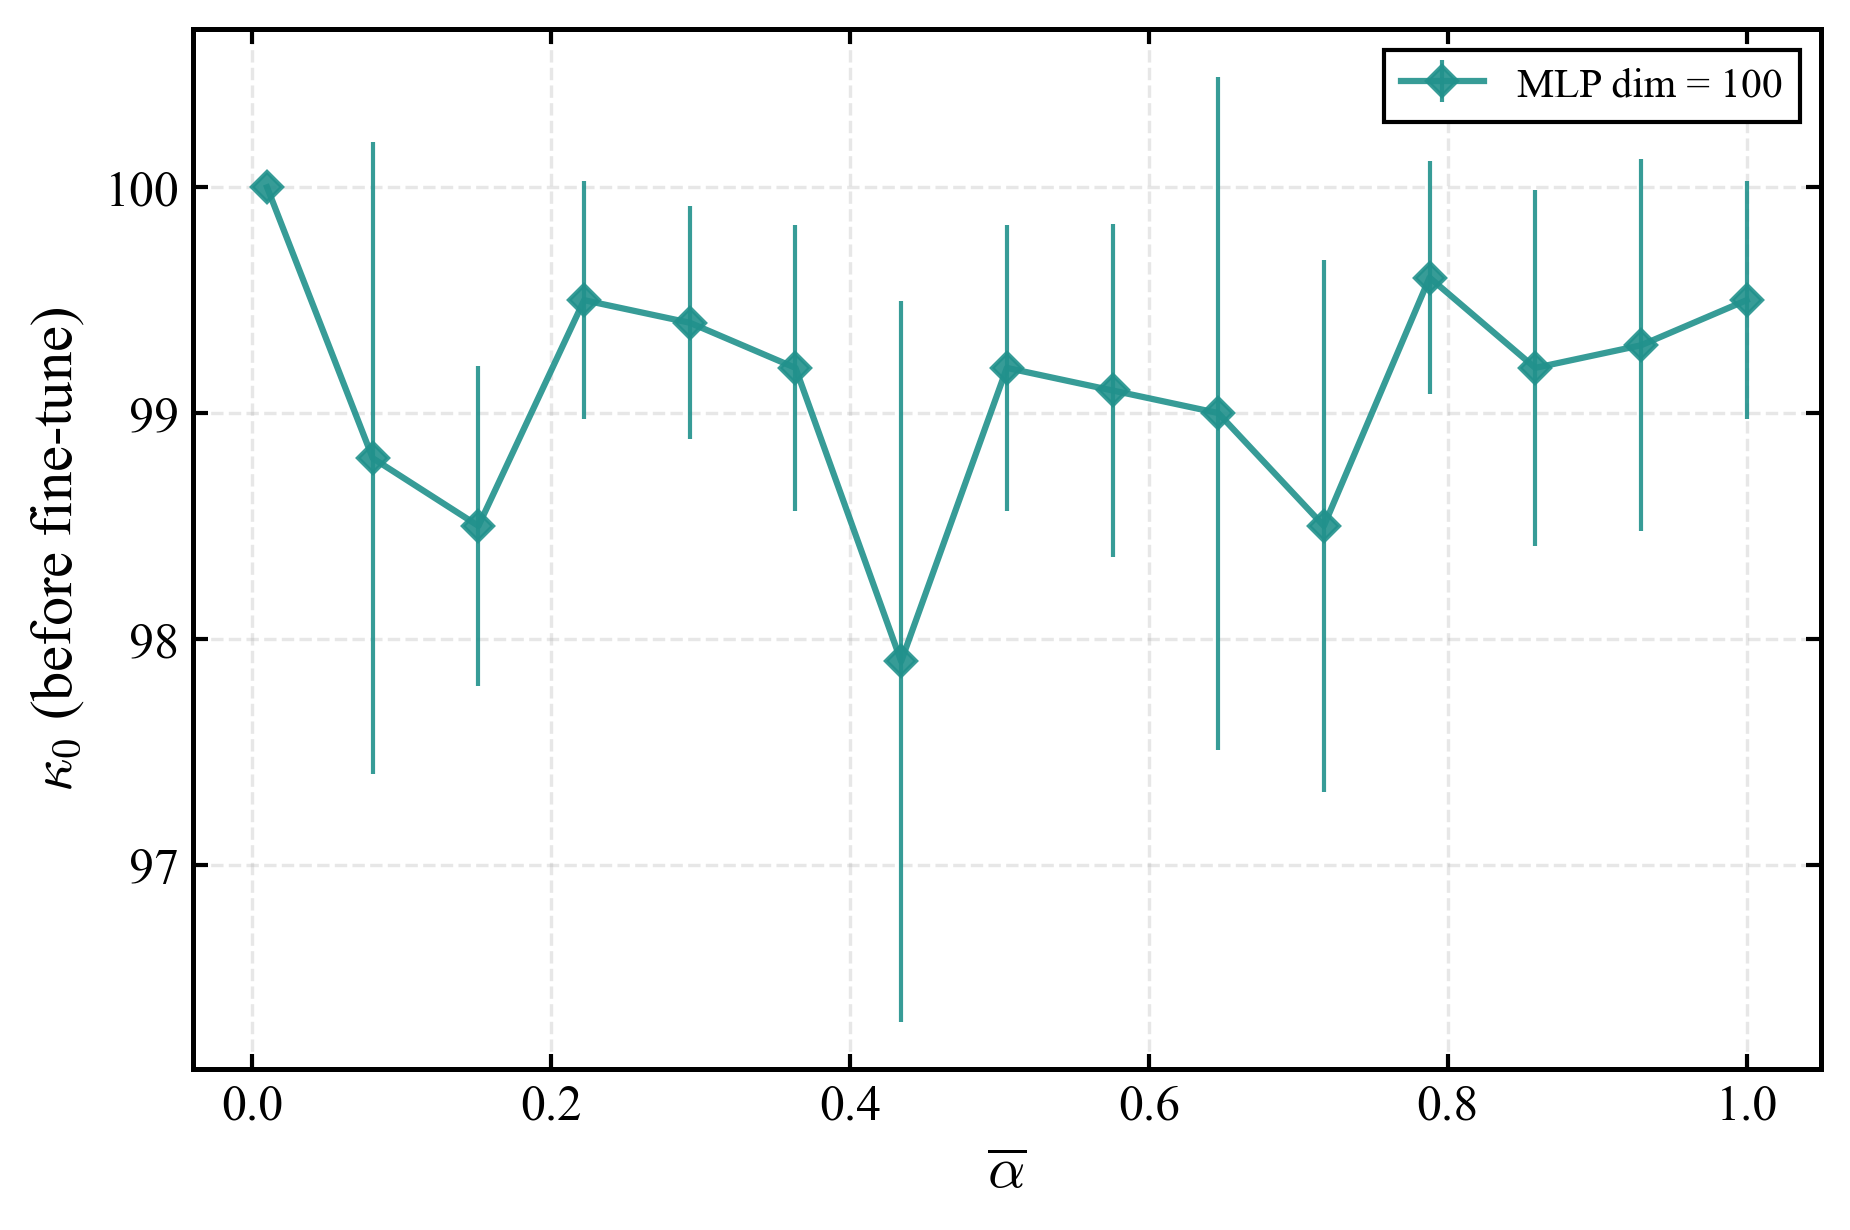

✅ Saved plot: ../results/run_20251217_1517/plots/rank_after_vs_alpha_run20251217_1517.png


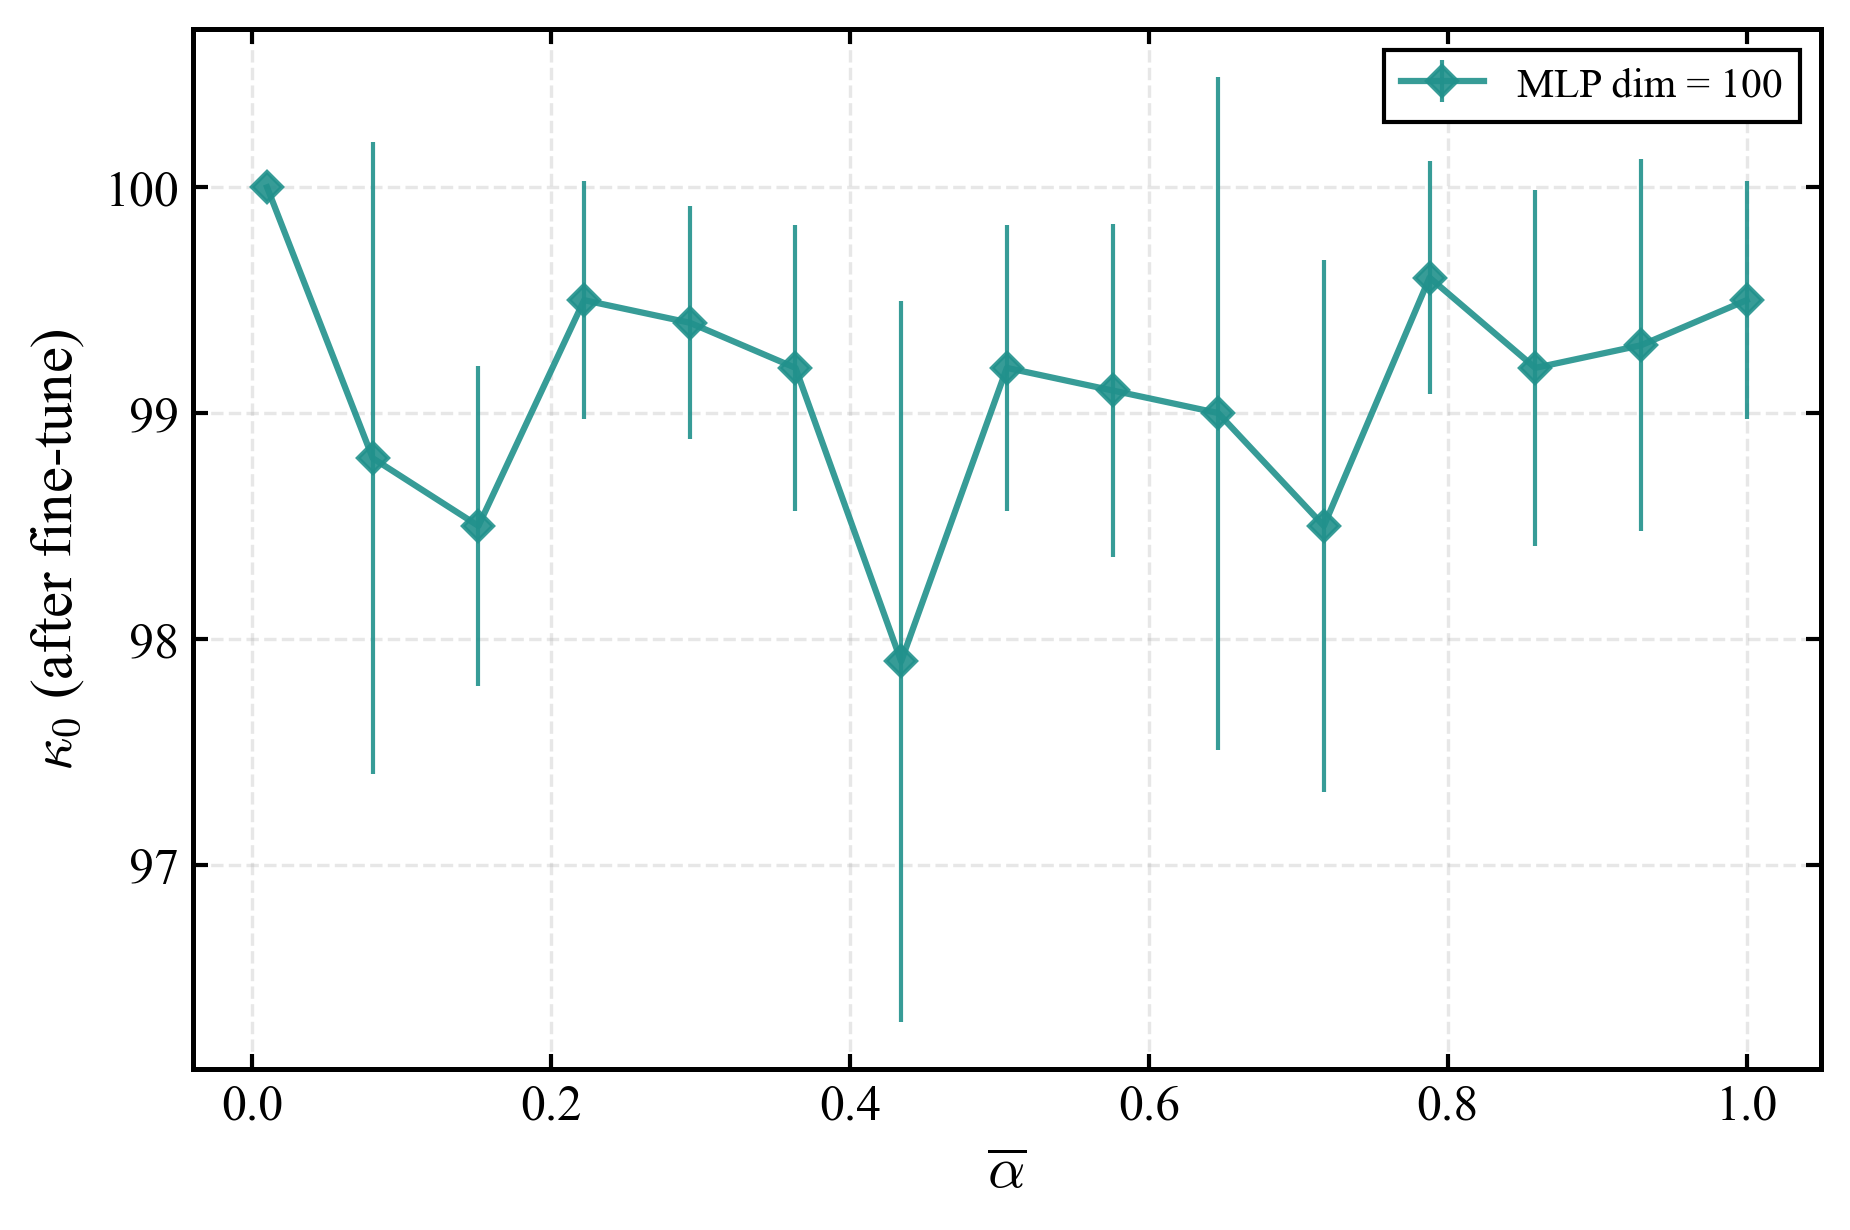

In [56]:
# --- Read the CSV file ---
df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- Quick preview ---
display(df.head())

# --- 2. Load Data ---
# Ensure base_path, run_id, and plot_path are defined
# df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows)")

# --- 3. Setup Colors for MLP Dimensions ---
# We map each unique MLP_dim to a specific color so it stays consistent across all plots
unique_dims = sorted(df["MLP_dim"].unique())
palette = sns.color_palette("viridis", n_colors=len(unique_dims))
color_map = {dim: color for dim, color in zip(unique_dims, palette)}

# --- 4. The Generic Plotting Function ---
def plot_metric_by_mlp(df, y_col, y_err_col, ylabel, filename, marker='o', log_y=False):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    # Loop through dimensions
    for mlp_dim in unique_dims:
        subset = df[df["MLP_dim"] == mlp_dim].sort_values("alpha")
        
        if subset.empty:
            continue
            
        ax.errorbar(
            subset["alpha"],
            subset[y_col],
            yerr=subset.get(y_err_col, 0),
            marker=marker,
            label=f"MLP dim = {mlp_dim}",
            color=color_map[mlp_dim], # Consistent color
            capsize=0,
            elinewidth=1.0,
            alpha=0.9
        )

    # Labels and Formatting
    ax.set_xlabel(r"$\overline{\alpha}$")
    ax.set_ylabel(ylabel)
    
    if log_y:
        ax.set_yscale('log')

    # --- BOX STYLE ---
    ax.set_axisbelow(True)
    ax.tick_params(direction='in', top=True, right=True, which='both', width=1.0)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    # Legend
    ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0, loc='best')

    # Save
    save_full = os.path.join(plot_path, filename)
    plt.savefig(save_full)
    print(f"✅ Saved plot: {save_full}")
    plt.show()

# --- 5. Generate All 7 Plots ---

# 1. Label Error
plot_metric_by_mlp(
    df, "label_err_mean", "label_err_std", 
    "Test Error", f"label_error_vs_alpha_run{run_id}.png", 
    marker='o'
)

# 2. Train Loss
plot_metric_by_mlp(
    df, "train_data_mean", "train_total_std", 
    "Train Loss", f"train_data_vs_alpha_run{run_id}.png", 
    marker='s' # Square
)

# 3. Train Accuracy
plot_metric_by_mlp(
    df, "acc_train_mean", "acc_train_std", 
    "Train Accuracy", f"train_accuracy_vs_alpha_run{run_id}.png", 
    marker='v' # Down triangle
)

# 4. Fine Tune Accuracy
plot_metric_by_mlp(
    df, "acc_fine_tune_mean", "acc_fine_tune_std", 
    "Fine Tune Accuracy", f"fine_tune_accuracy_vs_alpha_run{run_id}.png", 
    marker='v'
)

# 5. Test Accuracy
plot_metric_by_mlp(
    df, "acc_test_mean", "acc_test_std", 
    "Test Accuracy", f"test_accuracy_vs_alpha_run{run_id}.png", 
    marker='^' # Up triangle
)

# 6. Rank Before
plot_metric_by_mlp(
    df, "rank_before_mean", "rank_before_std", 
    r"$\kappa_0$ (before fine-tune)", f"rank_before_vs_alpha_run{run_id}.png", 
    marker='D' # Diamond
)

# 7. Rank After
plot_metric_by_mlp(
    df, "rank_after_mean", "rank_after_std", 
    r"$\kappa_0$ (after fine-tune)", f"rank_after_vs_alpha_run{run_id}.png", 
    marker='D'
)

## 3. Results visualisation

✅ Found 15 heavy_data files in ../results/run_20251217_1517/

Processing: heavy_data_0.pkl...
   📊 Saved plot: ../results/run_20251217_1517/plots/spectrum_heavy_data_0.png

Processing: heavy_data_1.pkl...
   📊 Saved plot: ../results/run_20251217_1517/plots/spectrum_heavy_data_1.png

Processing: heavy_data_10.pkl...
   📊 Saved plot: ../results/run_20251217_1517/plots/spectrum_heavy_data_10.png

Processing: heavy_data_11.pkl...
   📊 Saved plot: ../results/run_20251217_1517/plots/spectrum_heavy_data_11.png

Processing: heavy_data_12.pkl...
   📊 Saved plot: ../results/run_20251217_1517/plots/spectrum_heavy_data_12.png

Processing: heavy_data_13.pkl...
   📊 Saved plot: ../results/run_20251217_1517/plots/spectrum_heavy_data_13.png

Processing: heavy_data_14.pkl...
   📊 Saved plot: ../results/run_20251217_1517/plots/spectrum_heavy_data_14.png

Processing: heavy_data_2.pkl...
   📊 Saved plot: ../results/run_20251217_1517/plots/spectrum_heavy_data_2.png

Processing: heavy_data_3.pkl...
   📊 Sav

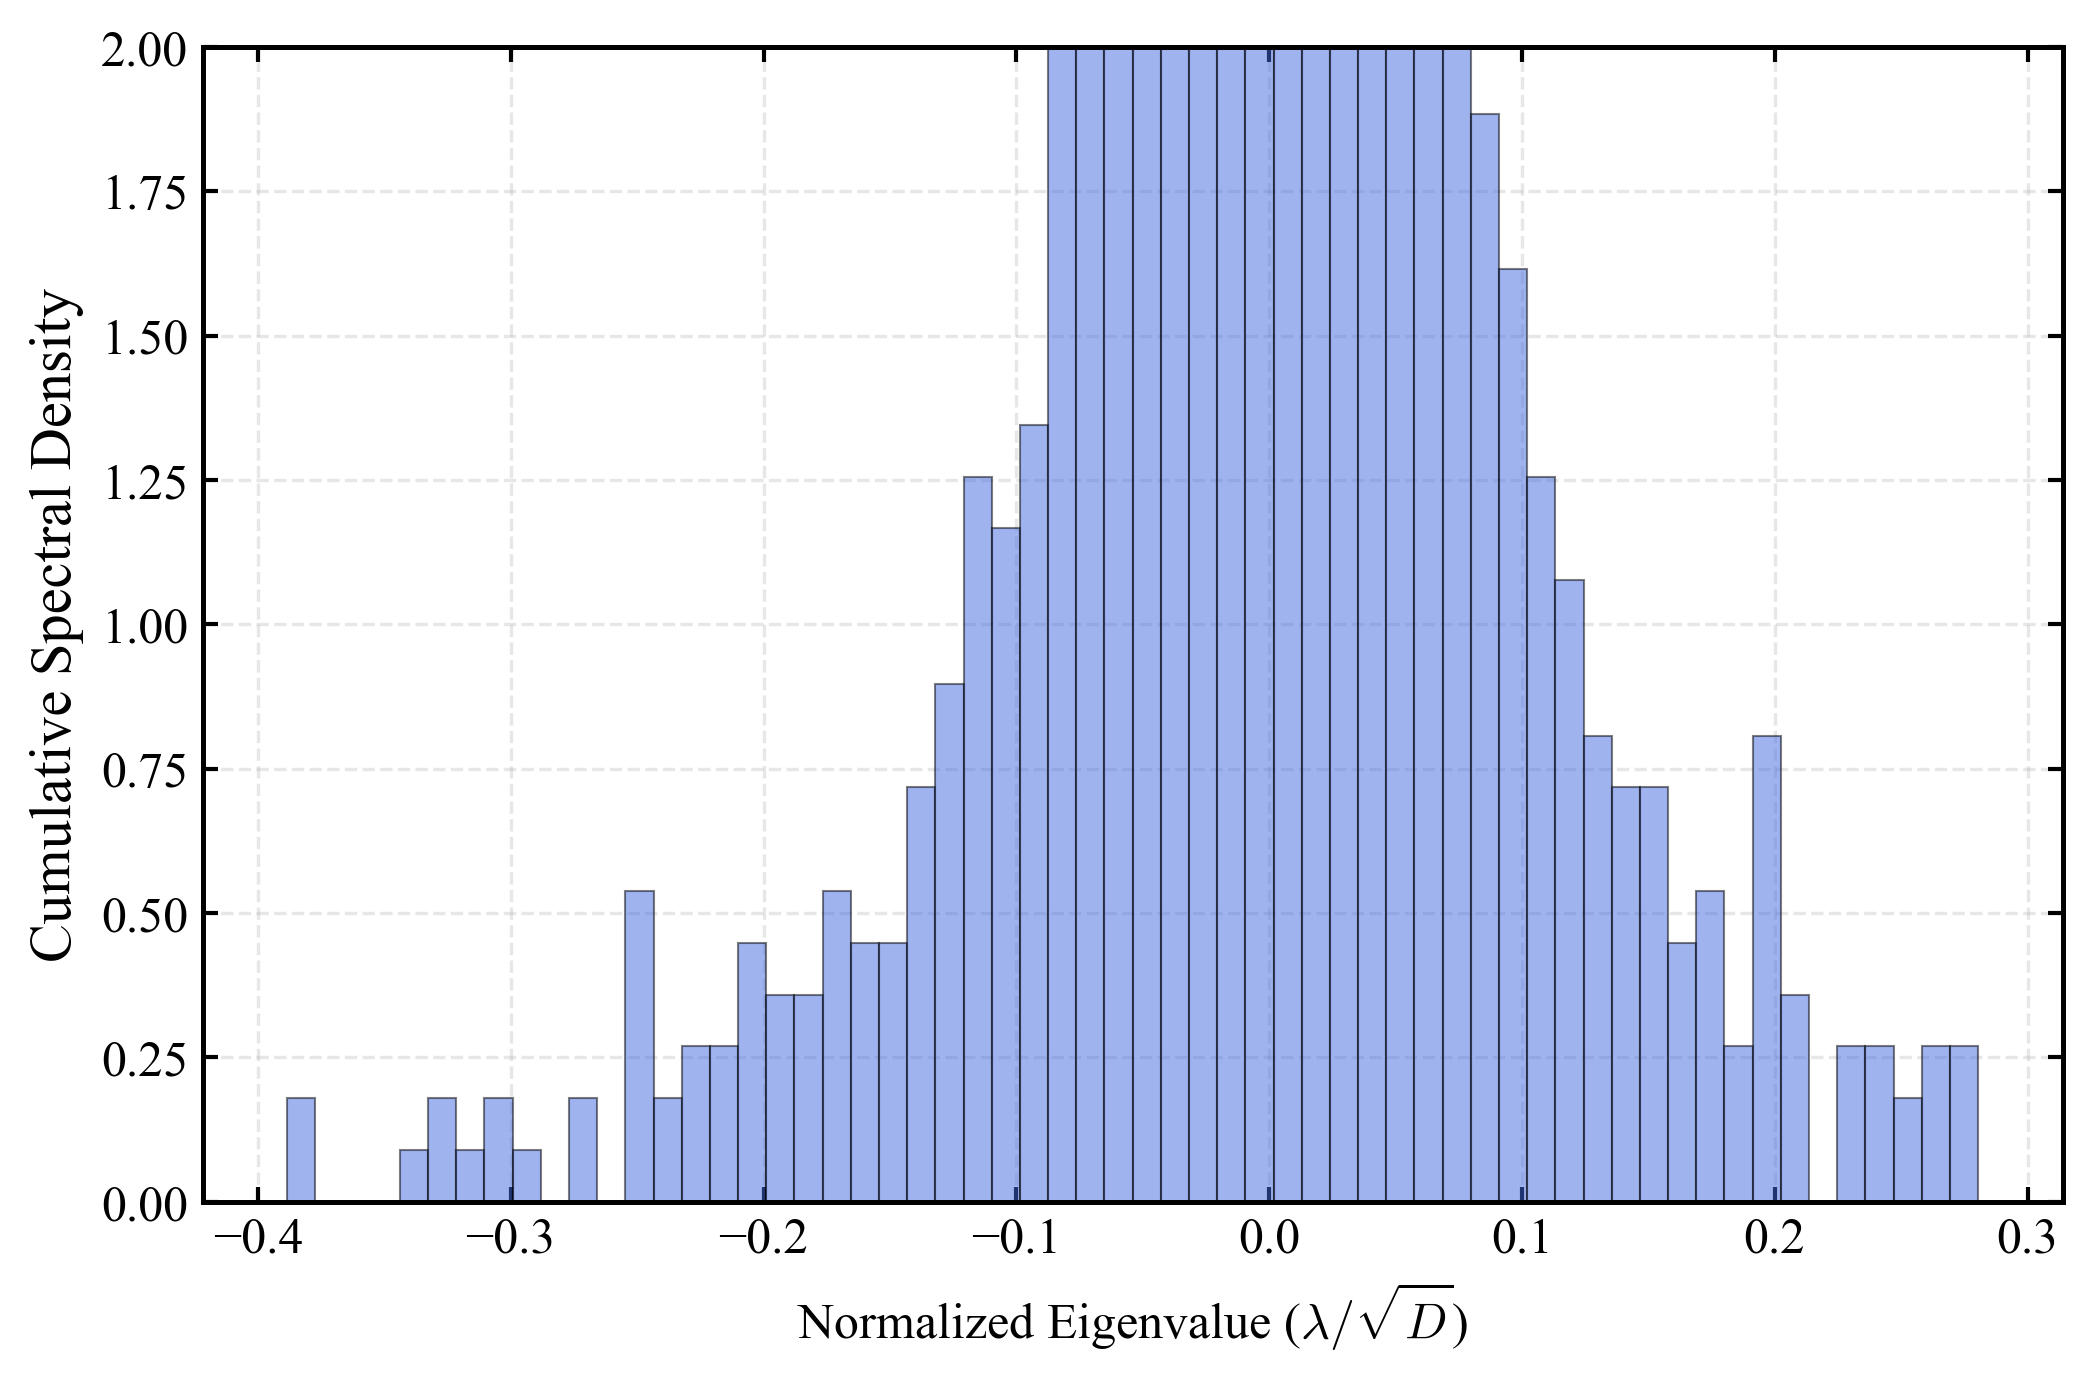

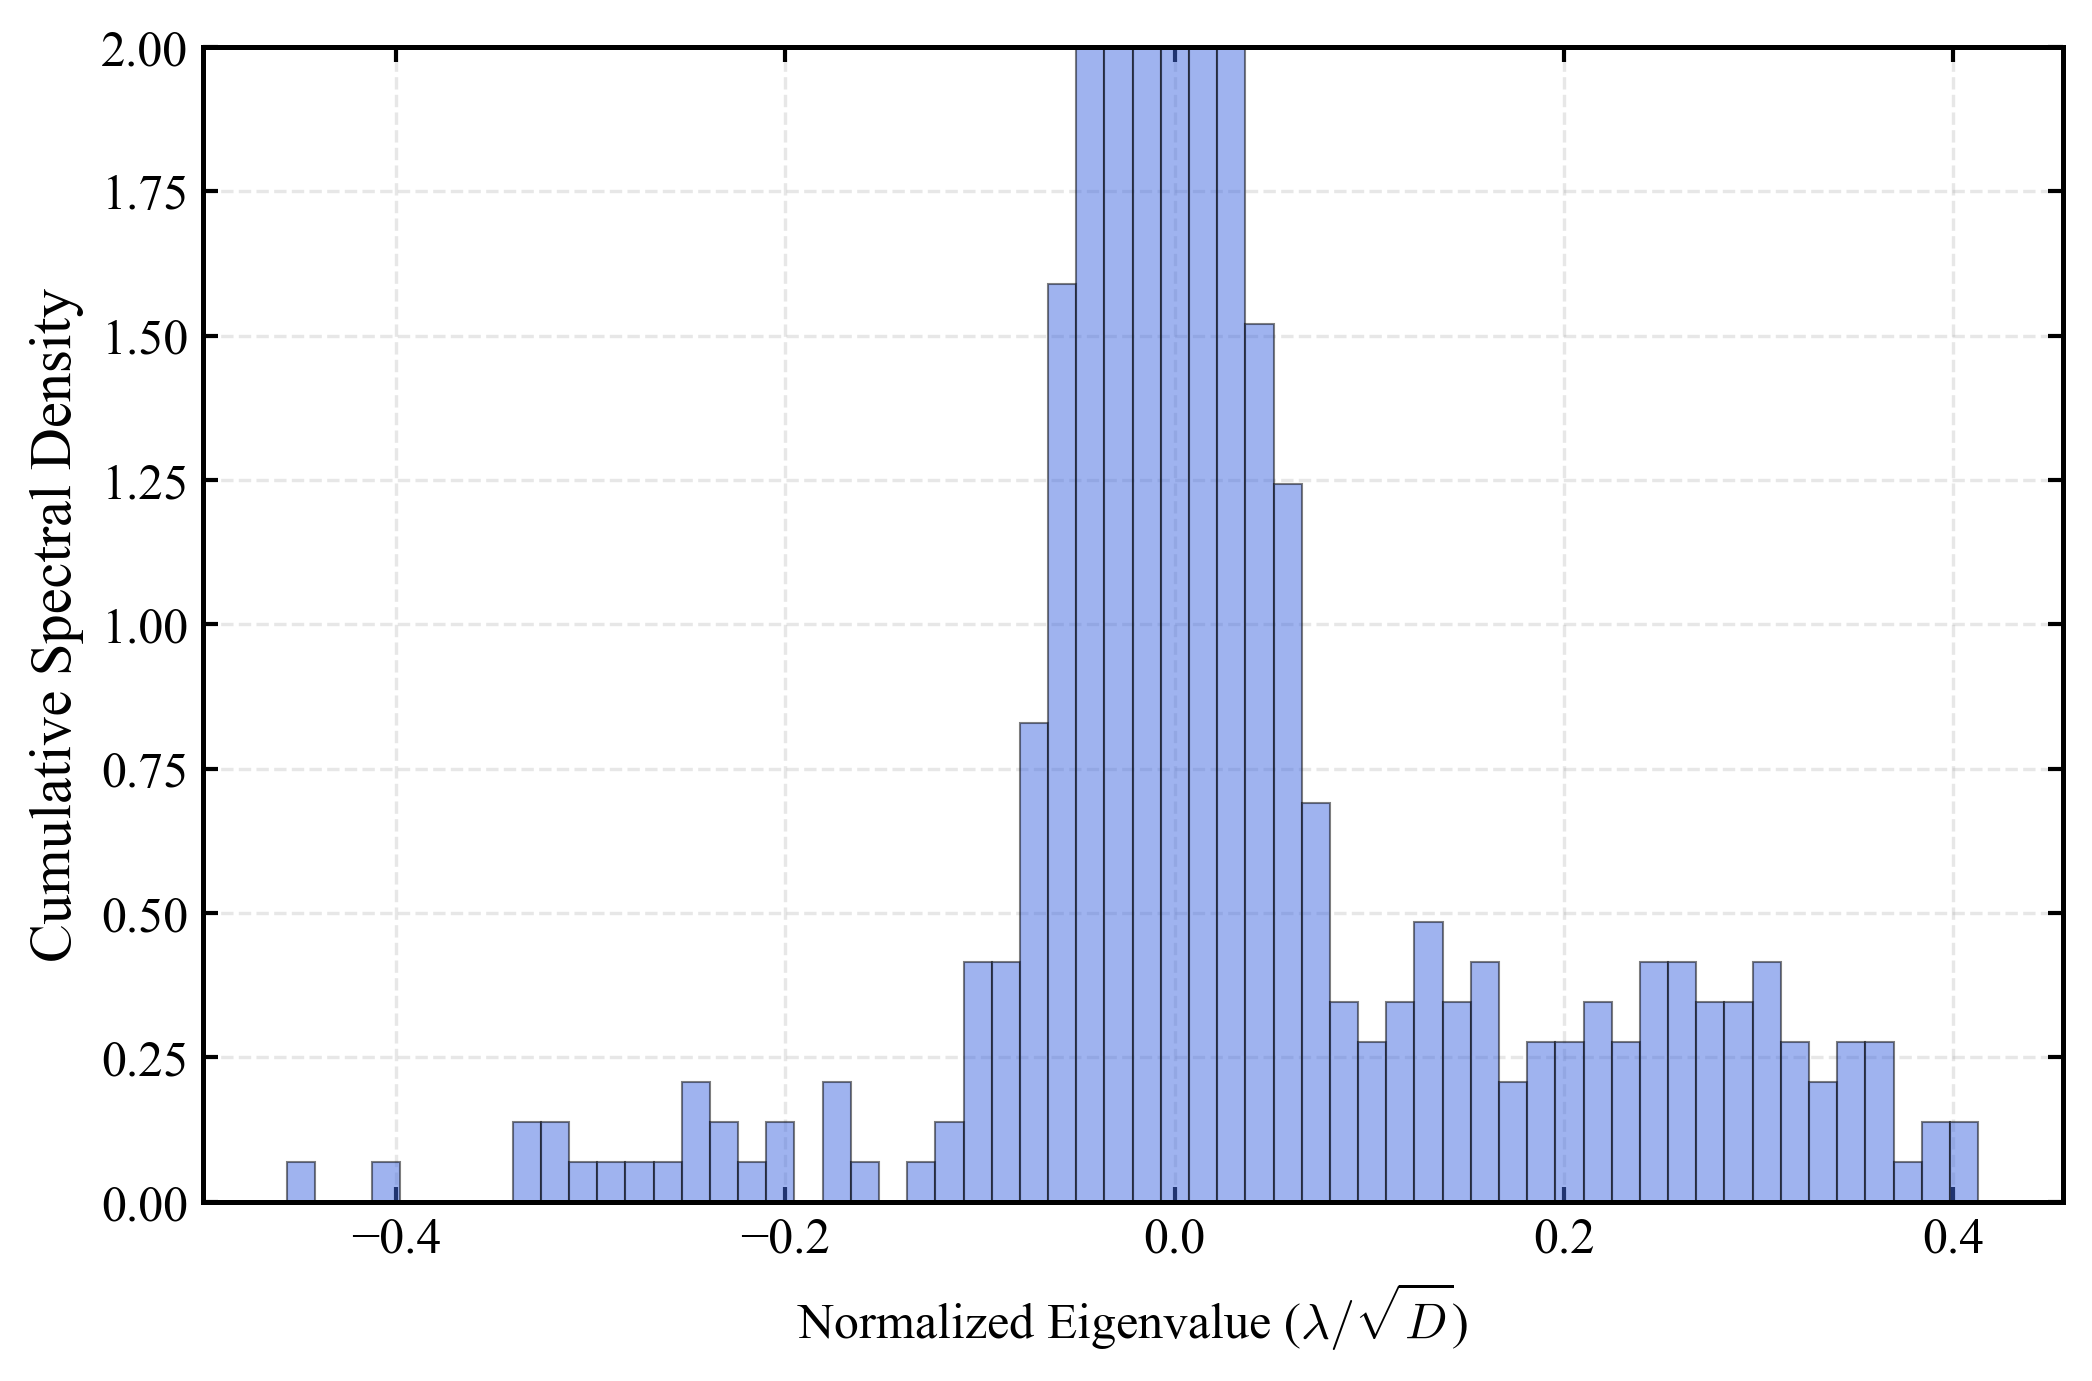

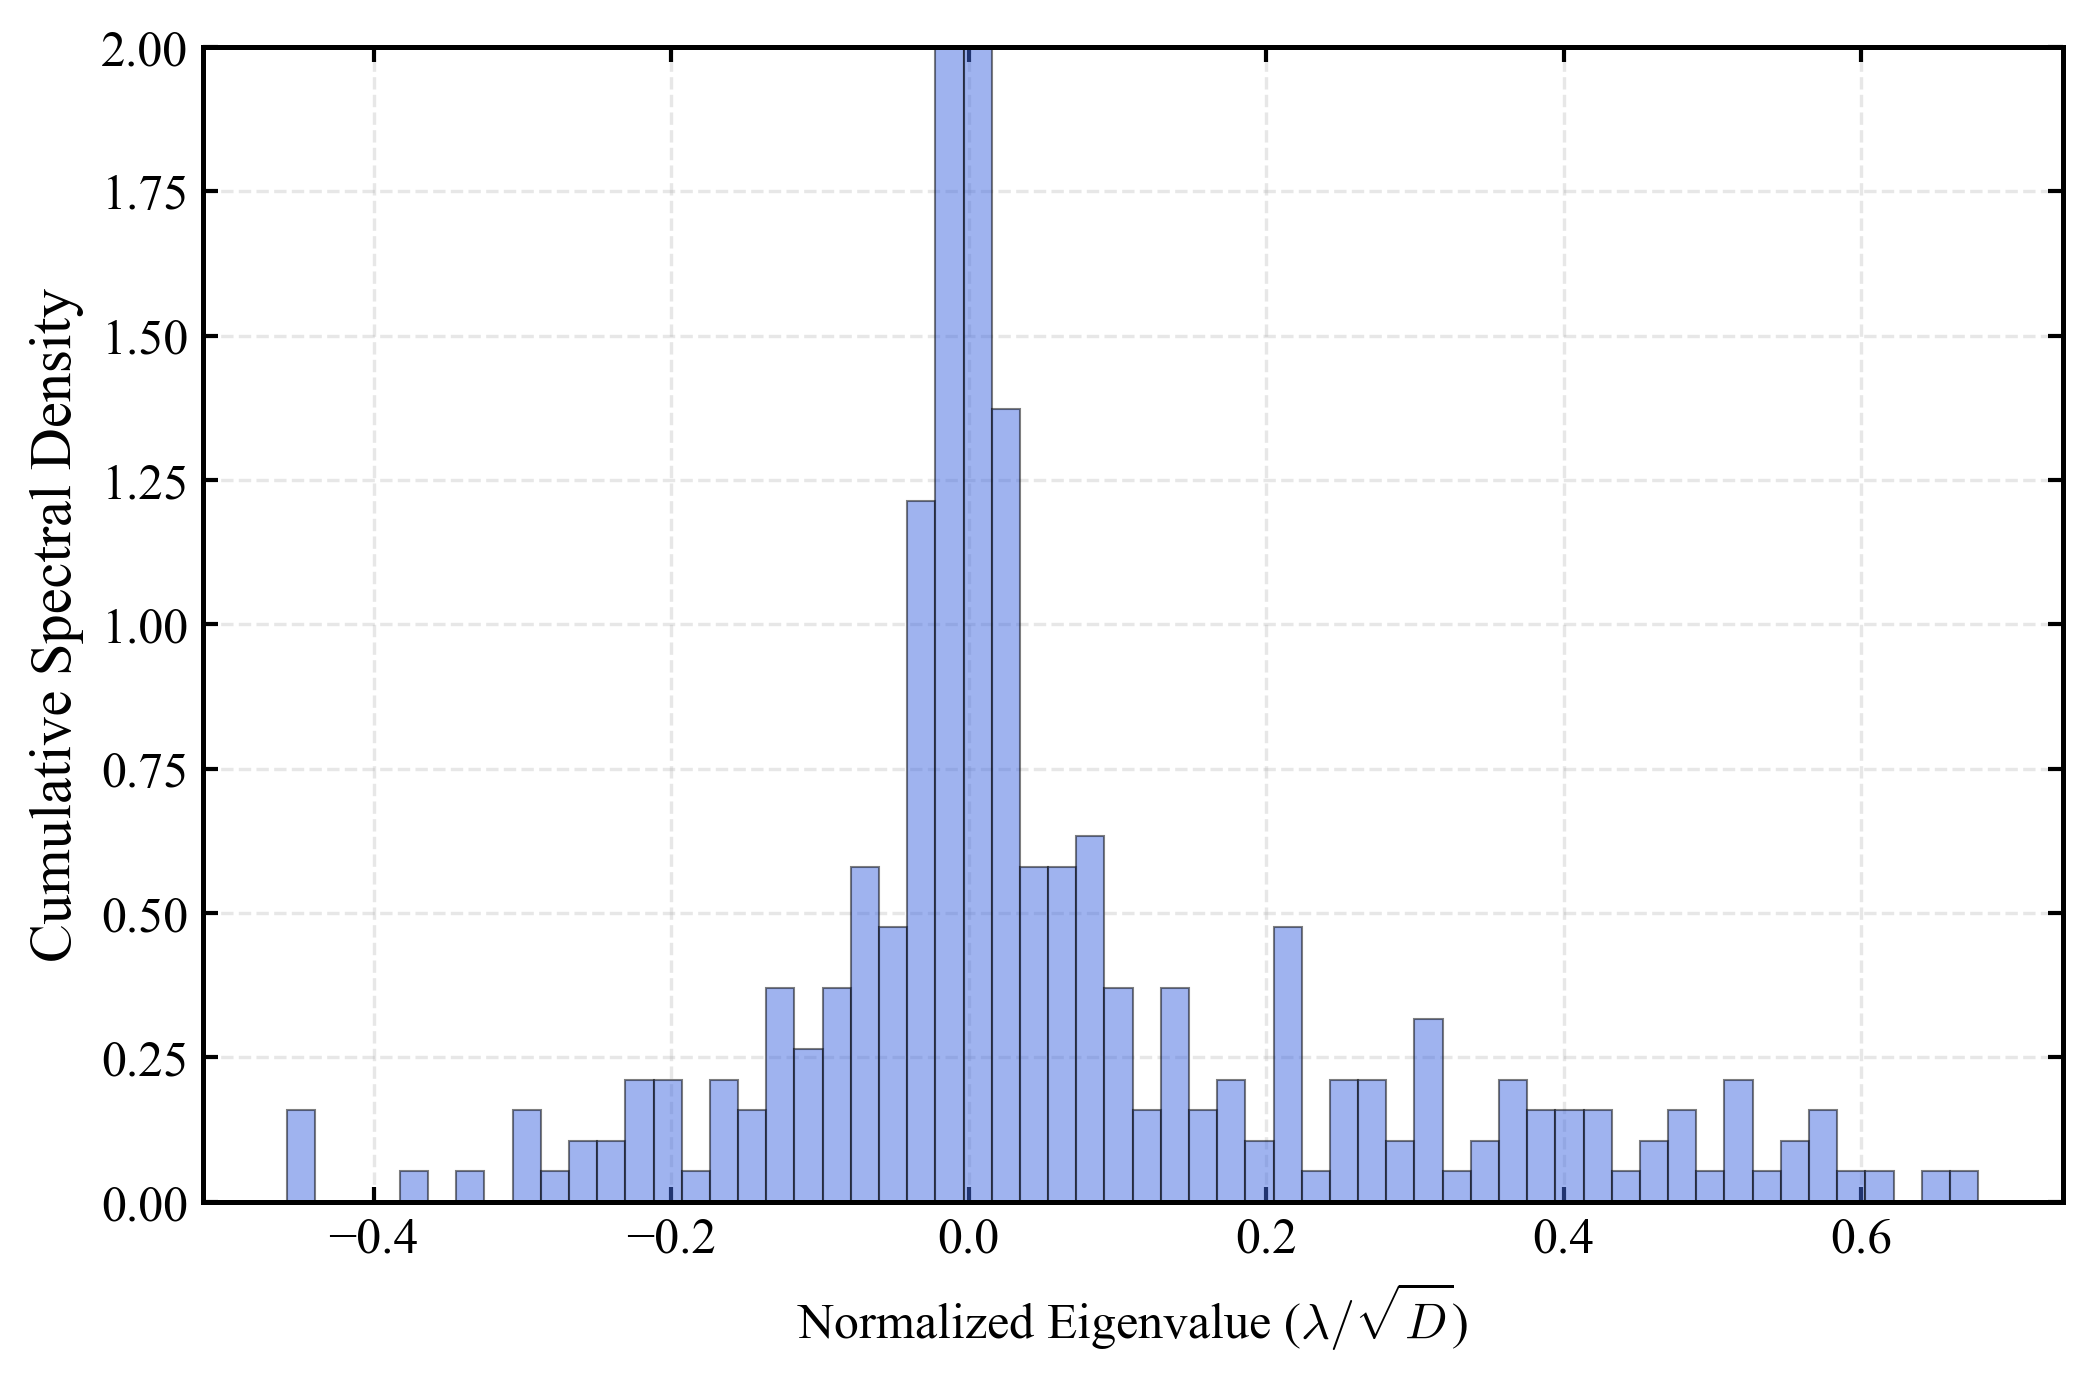

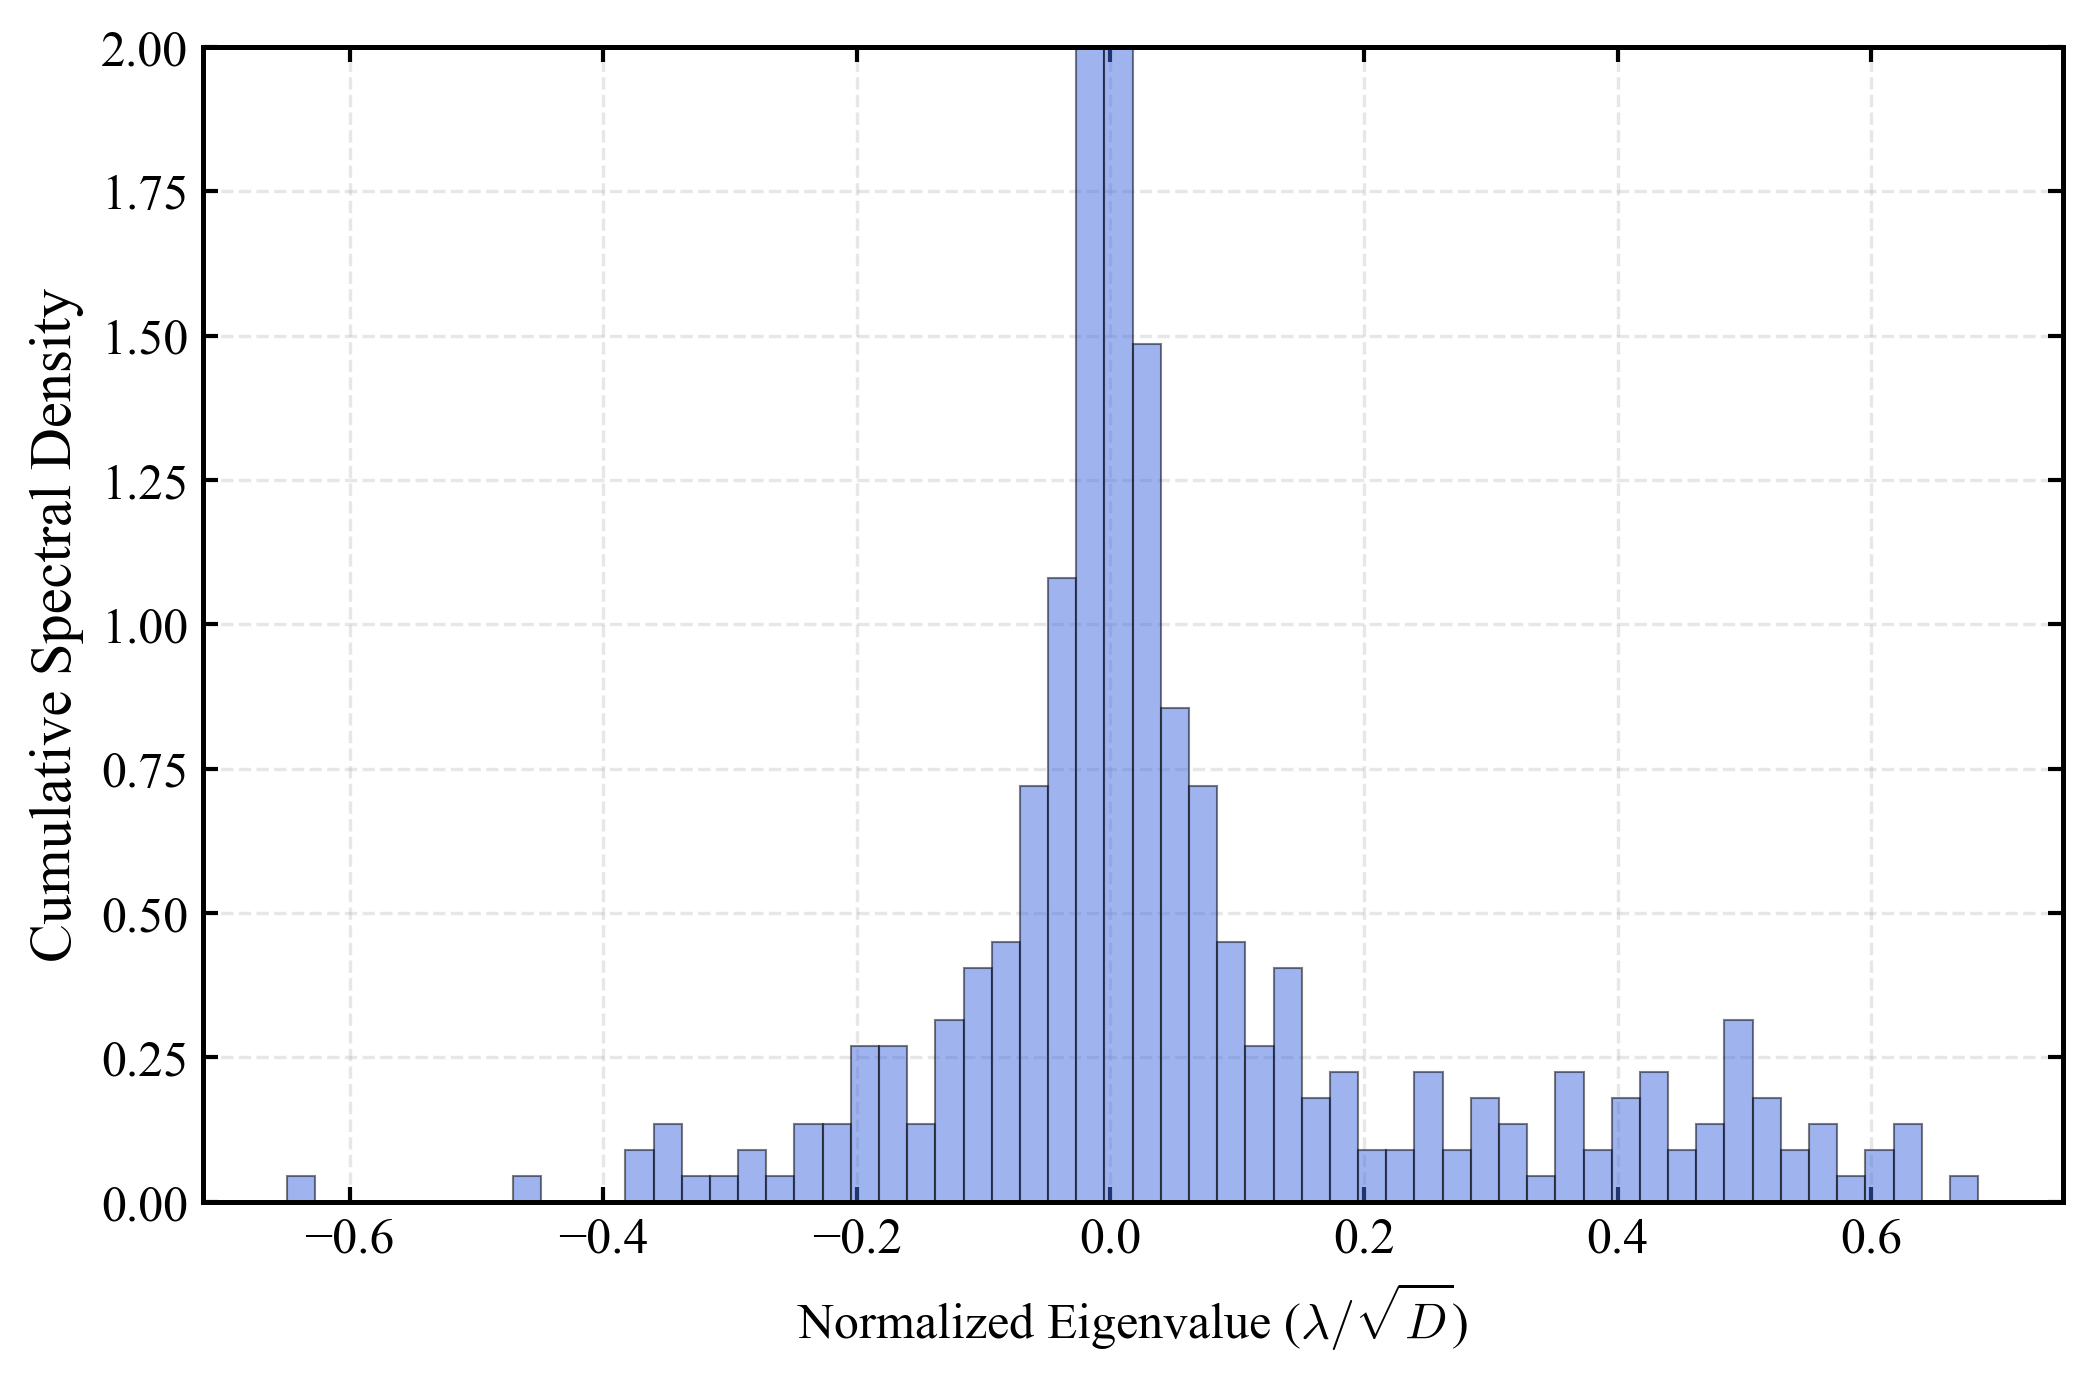

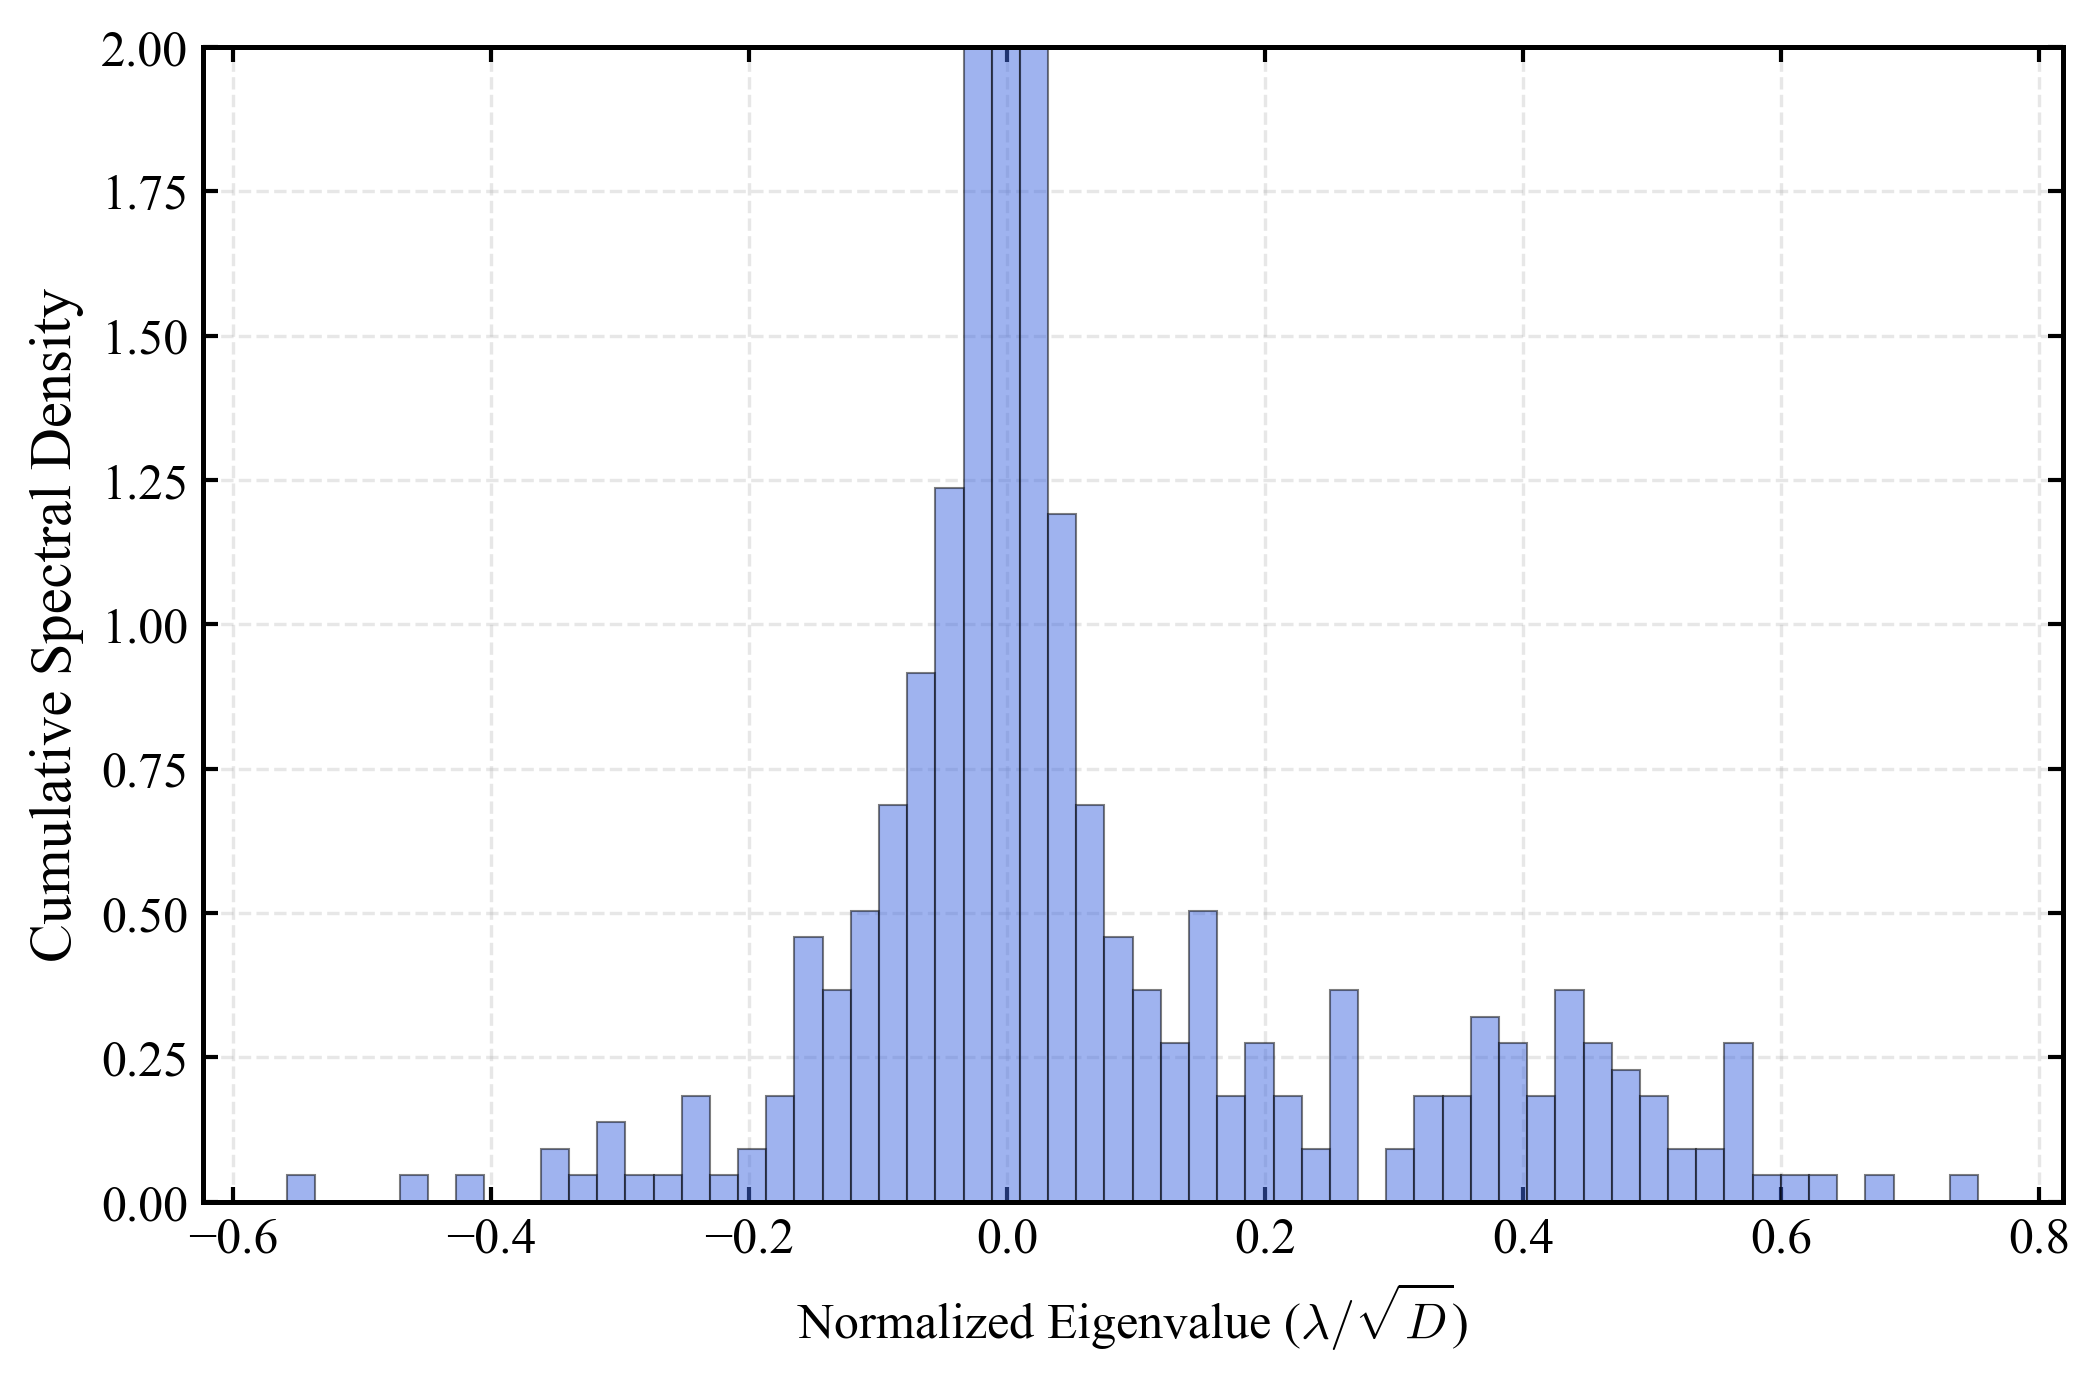

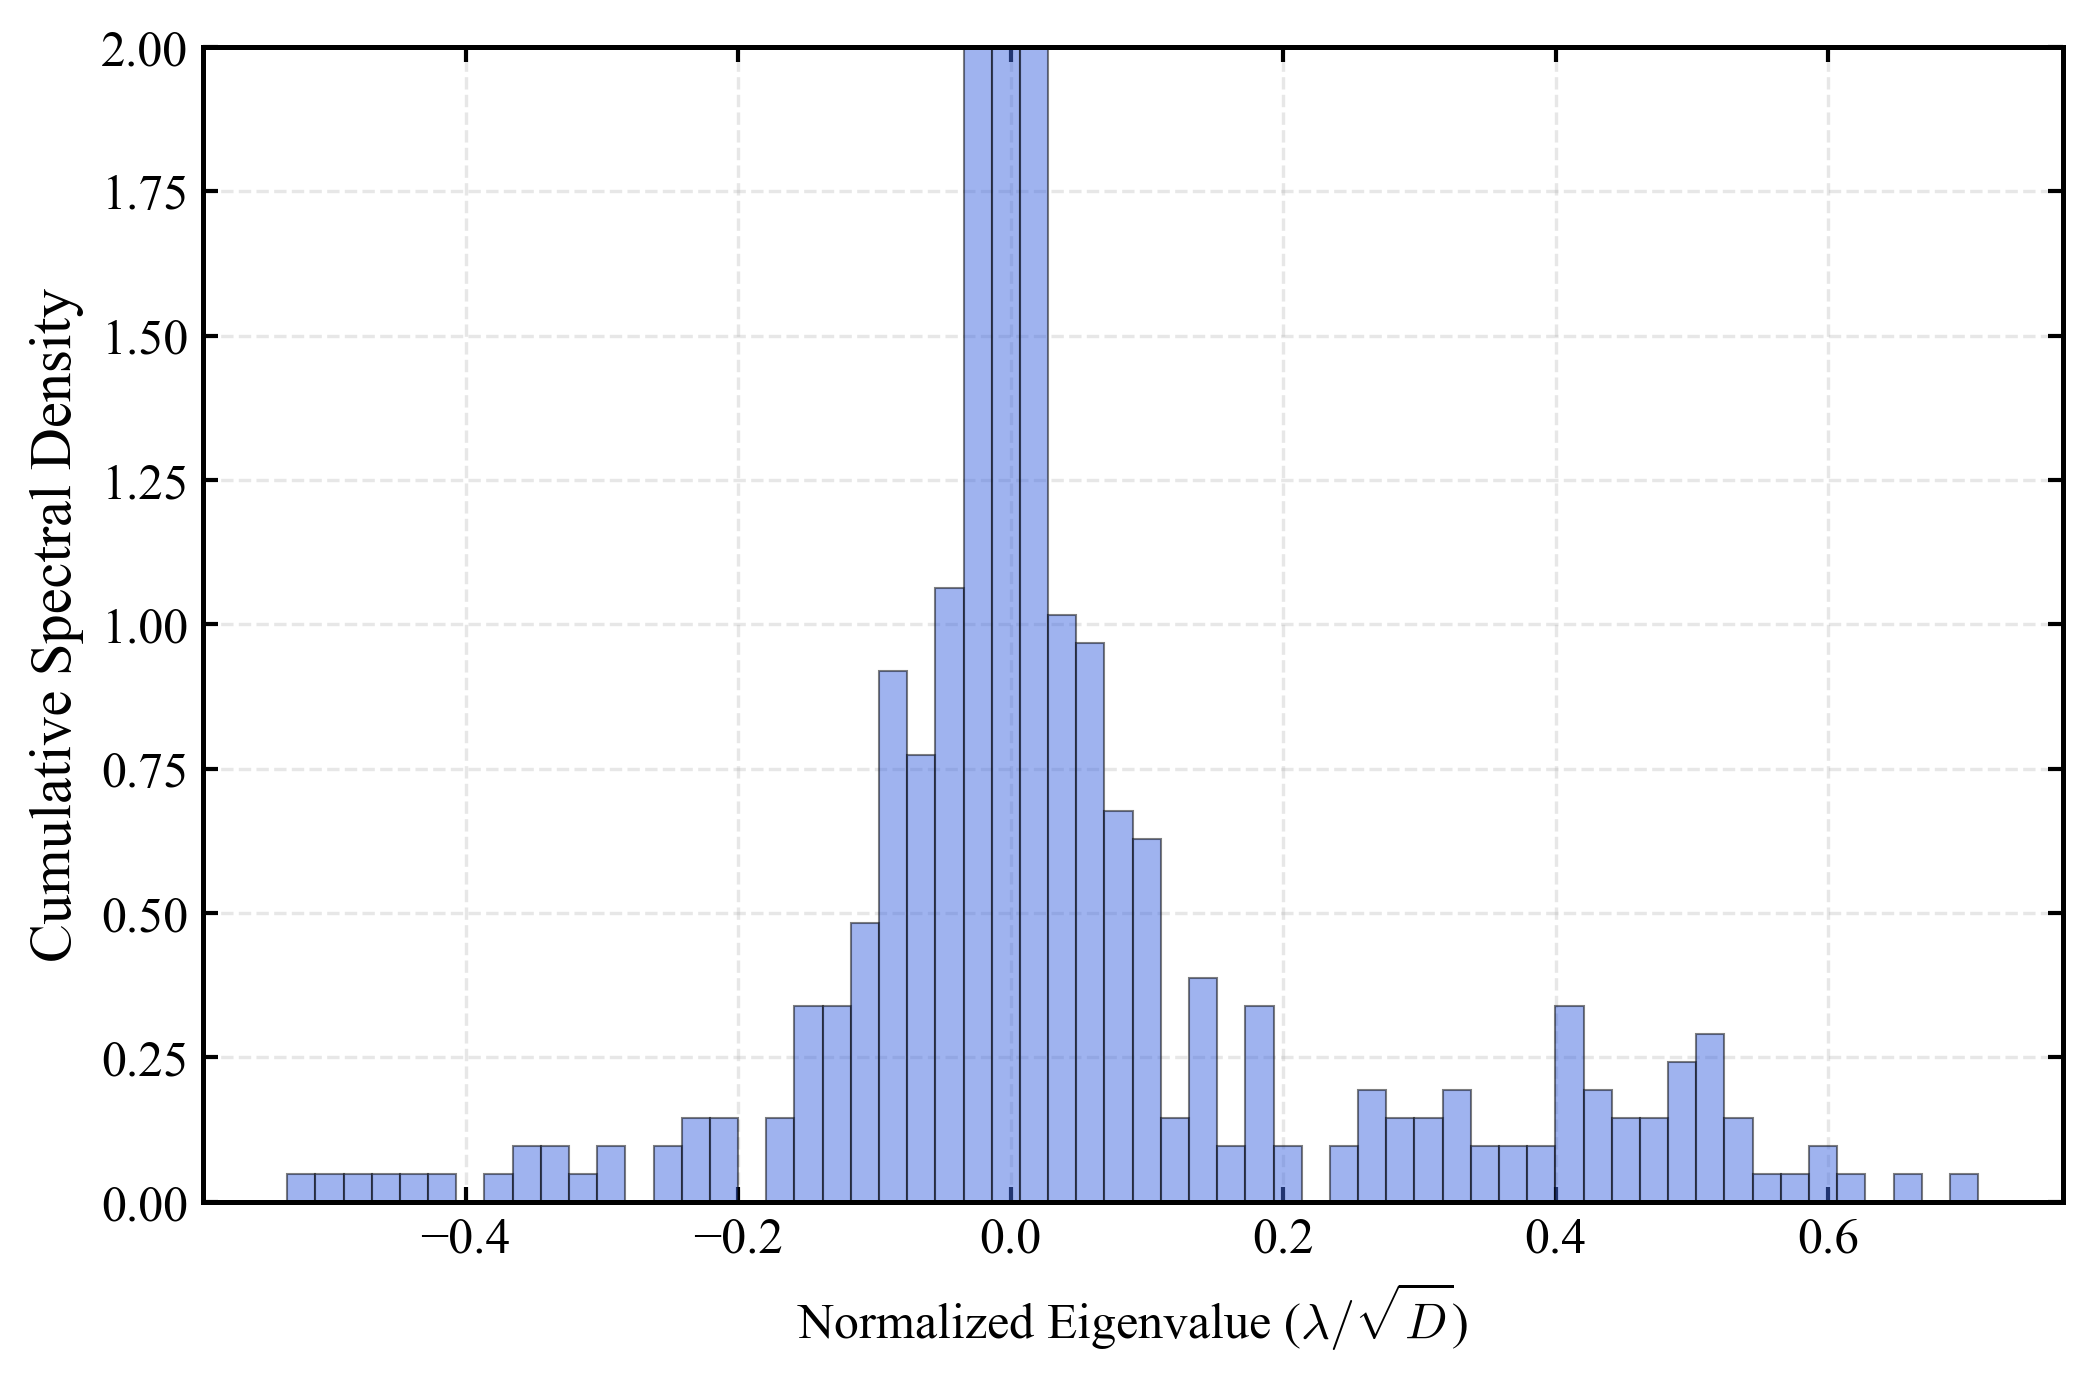

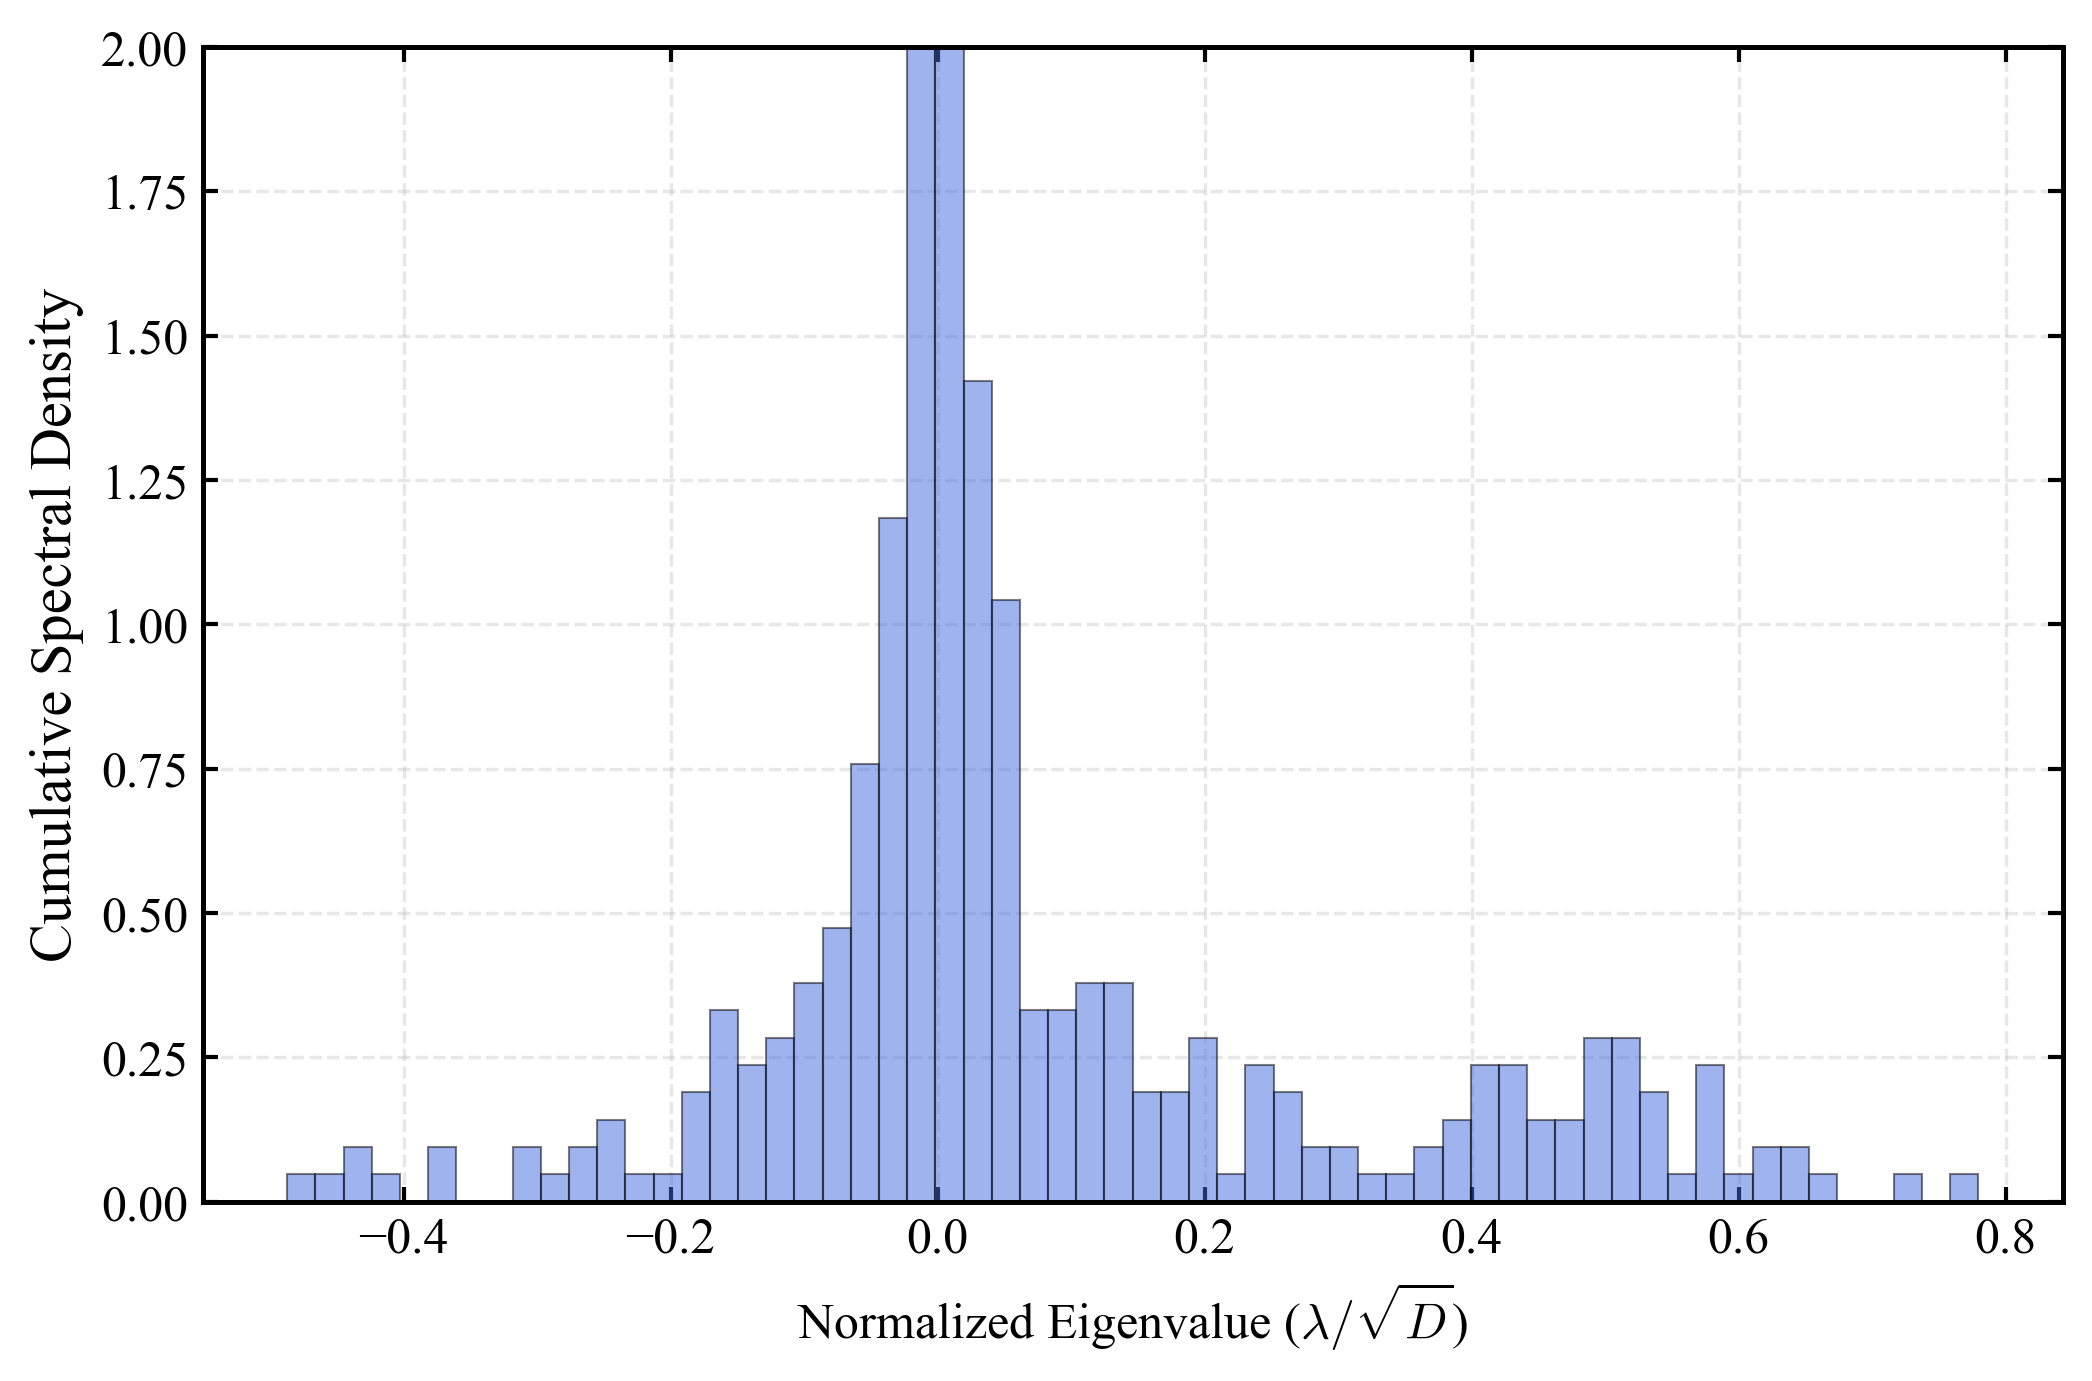

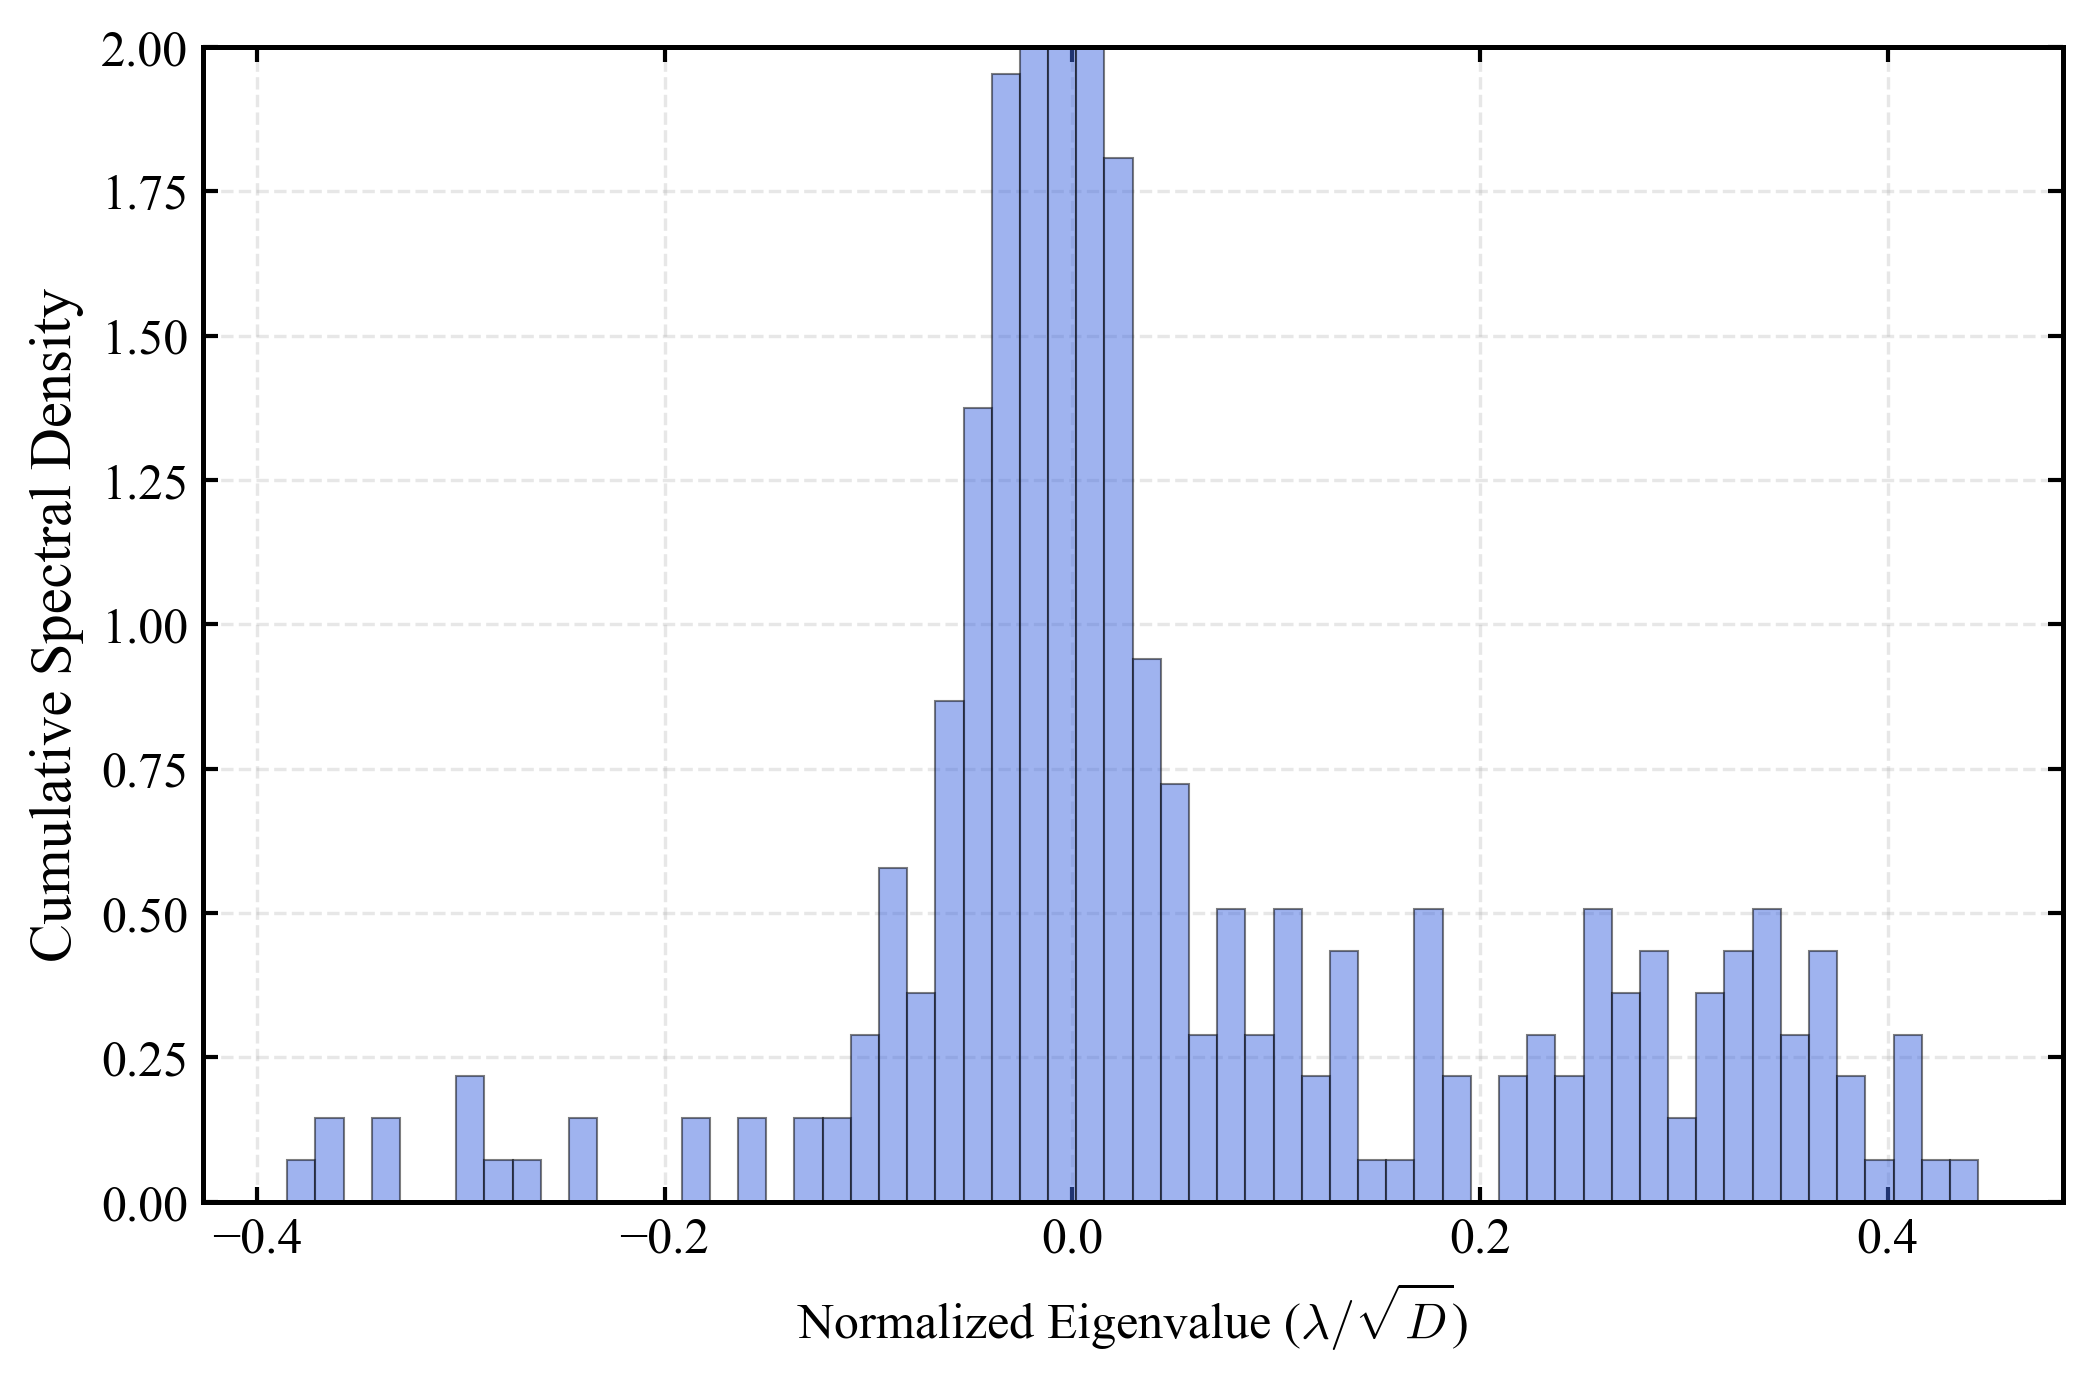

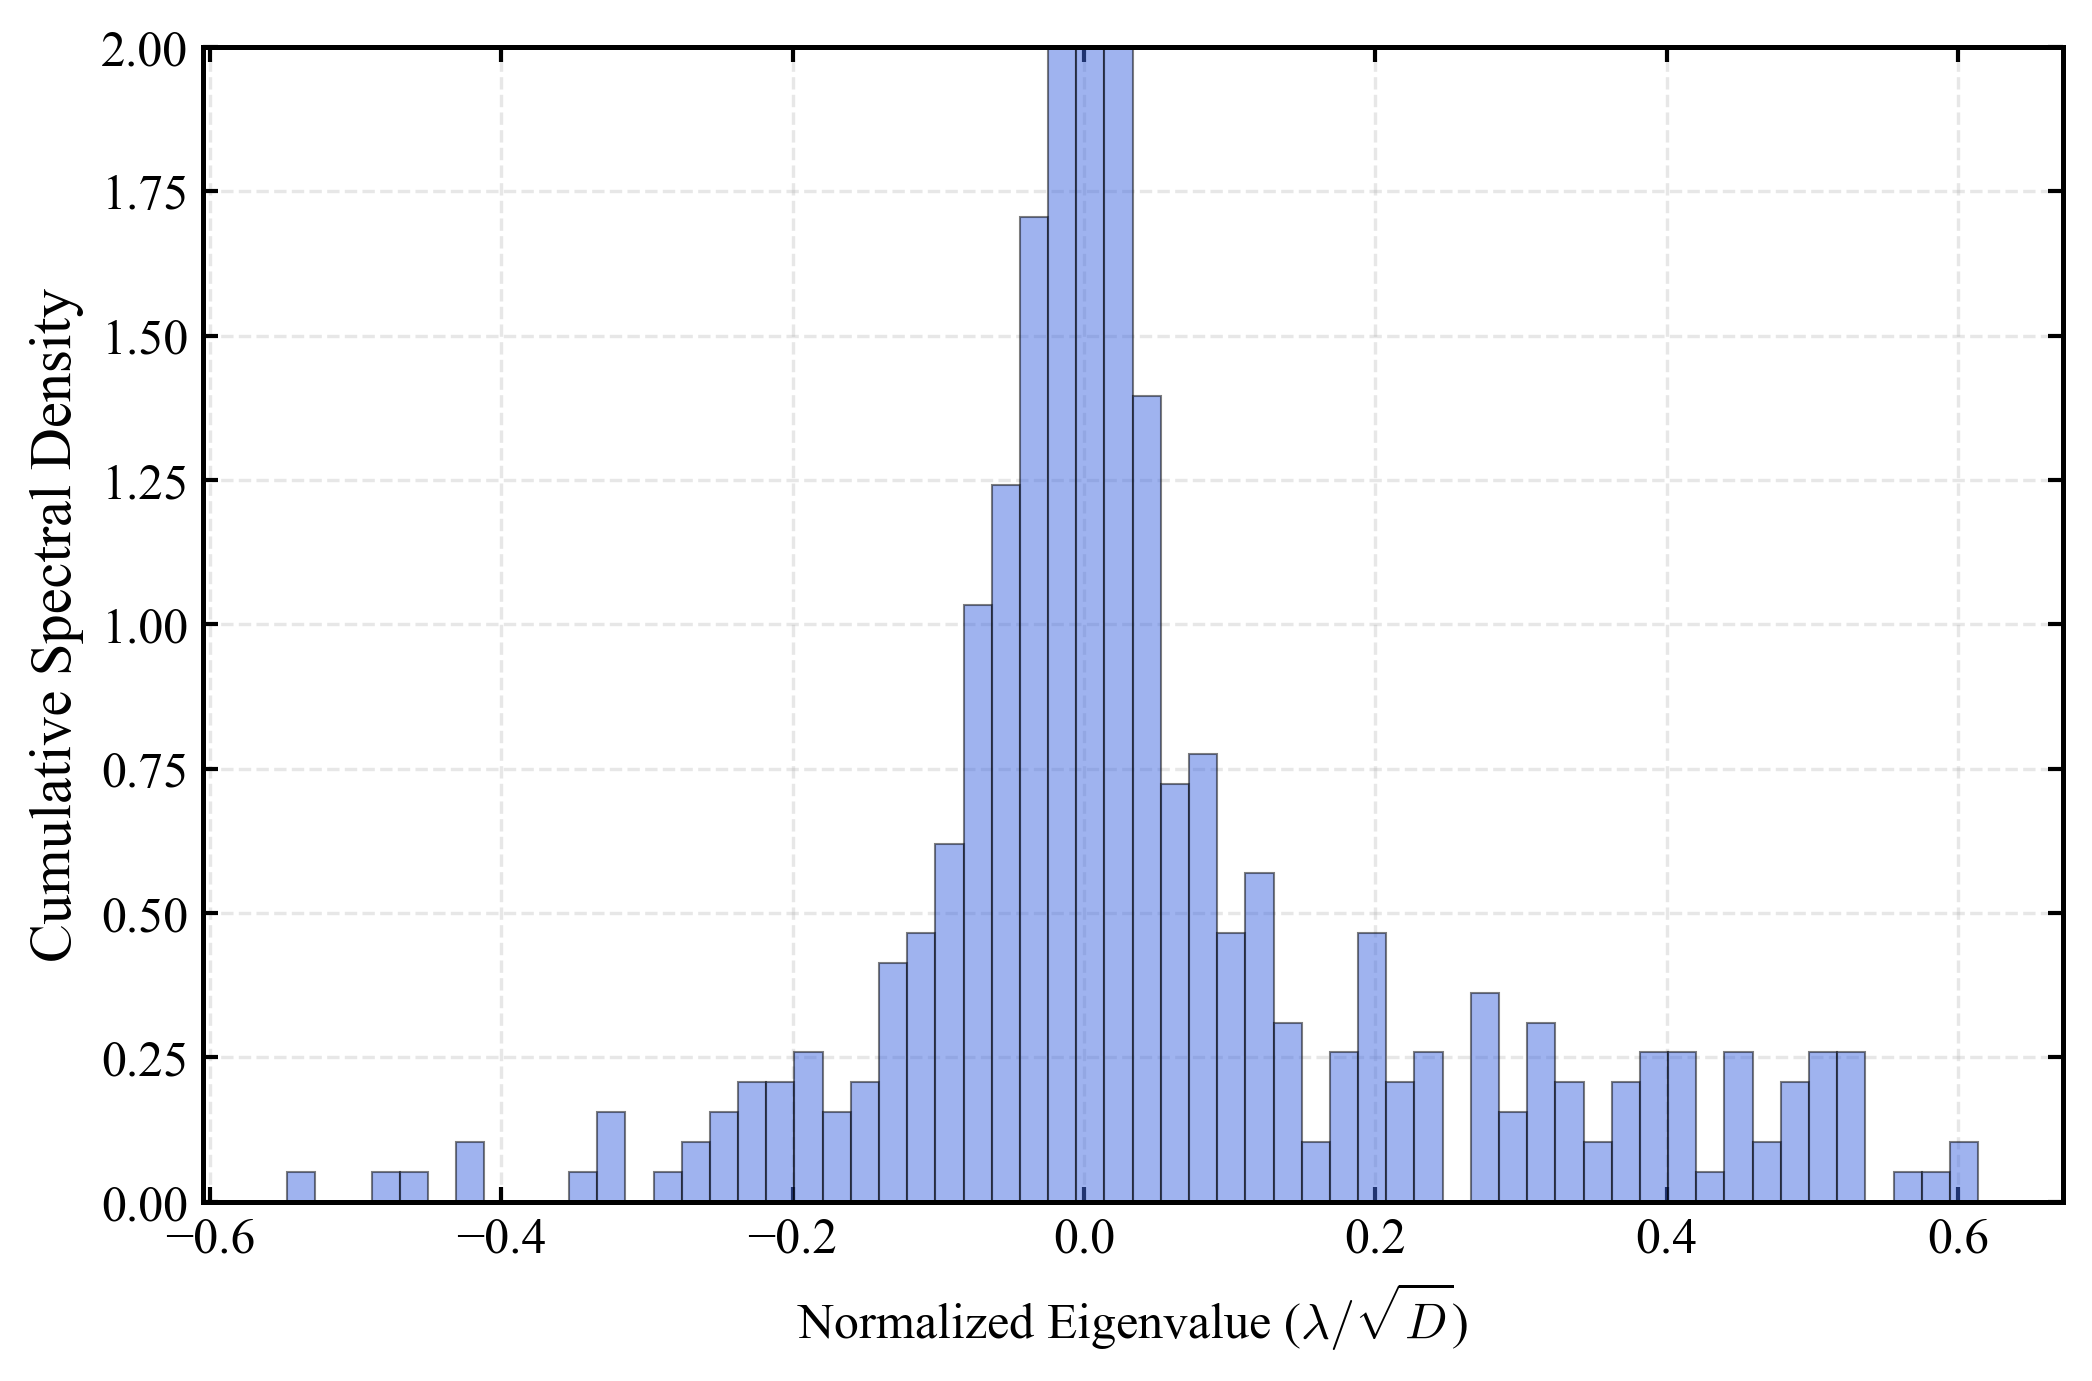

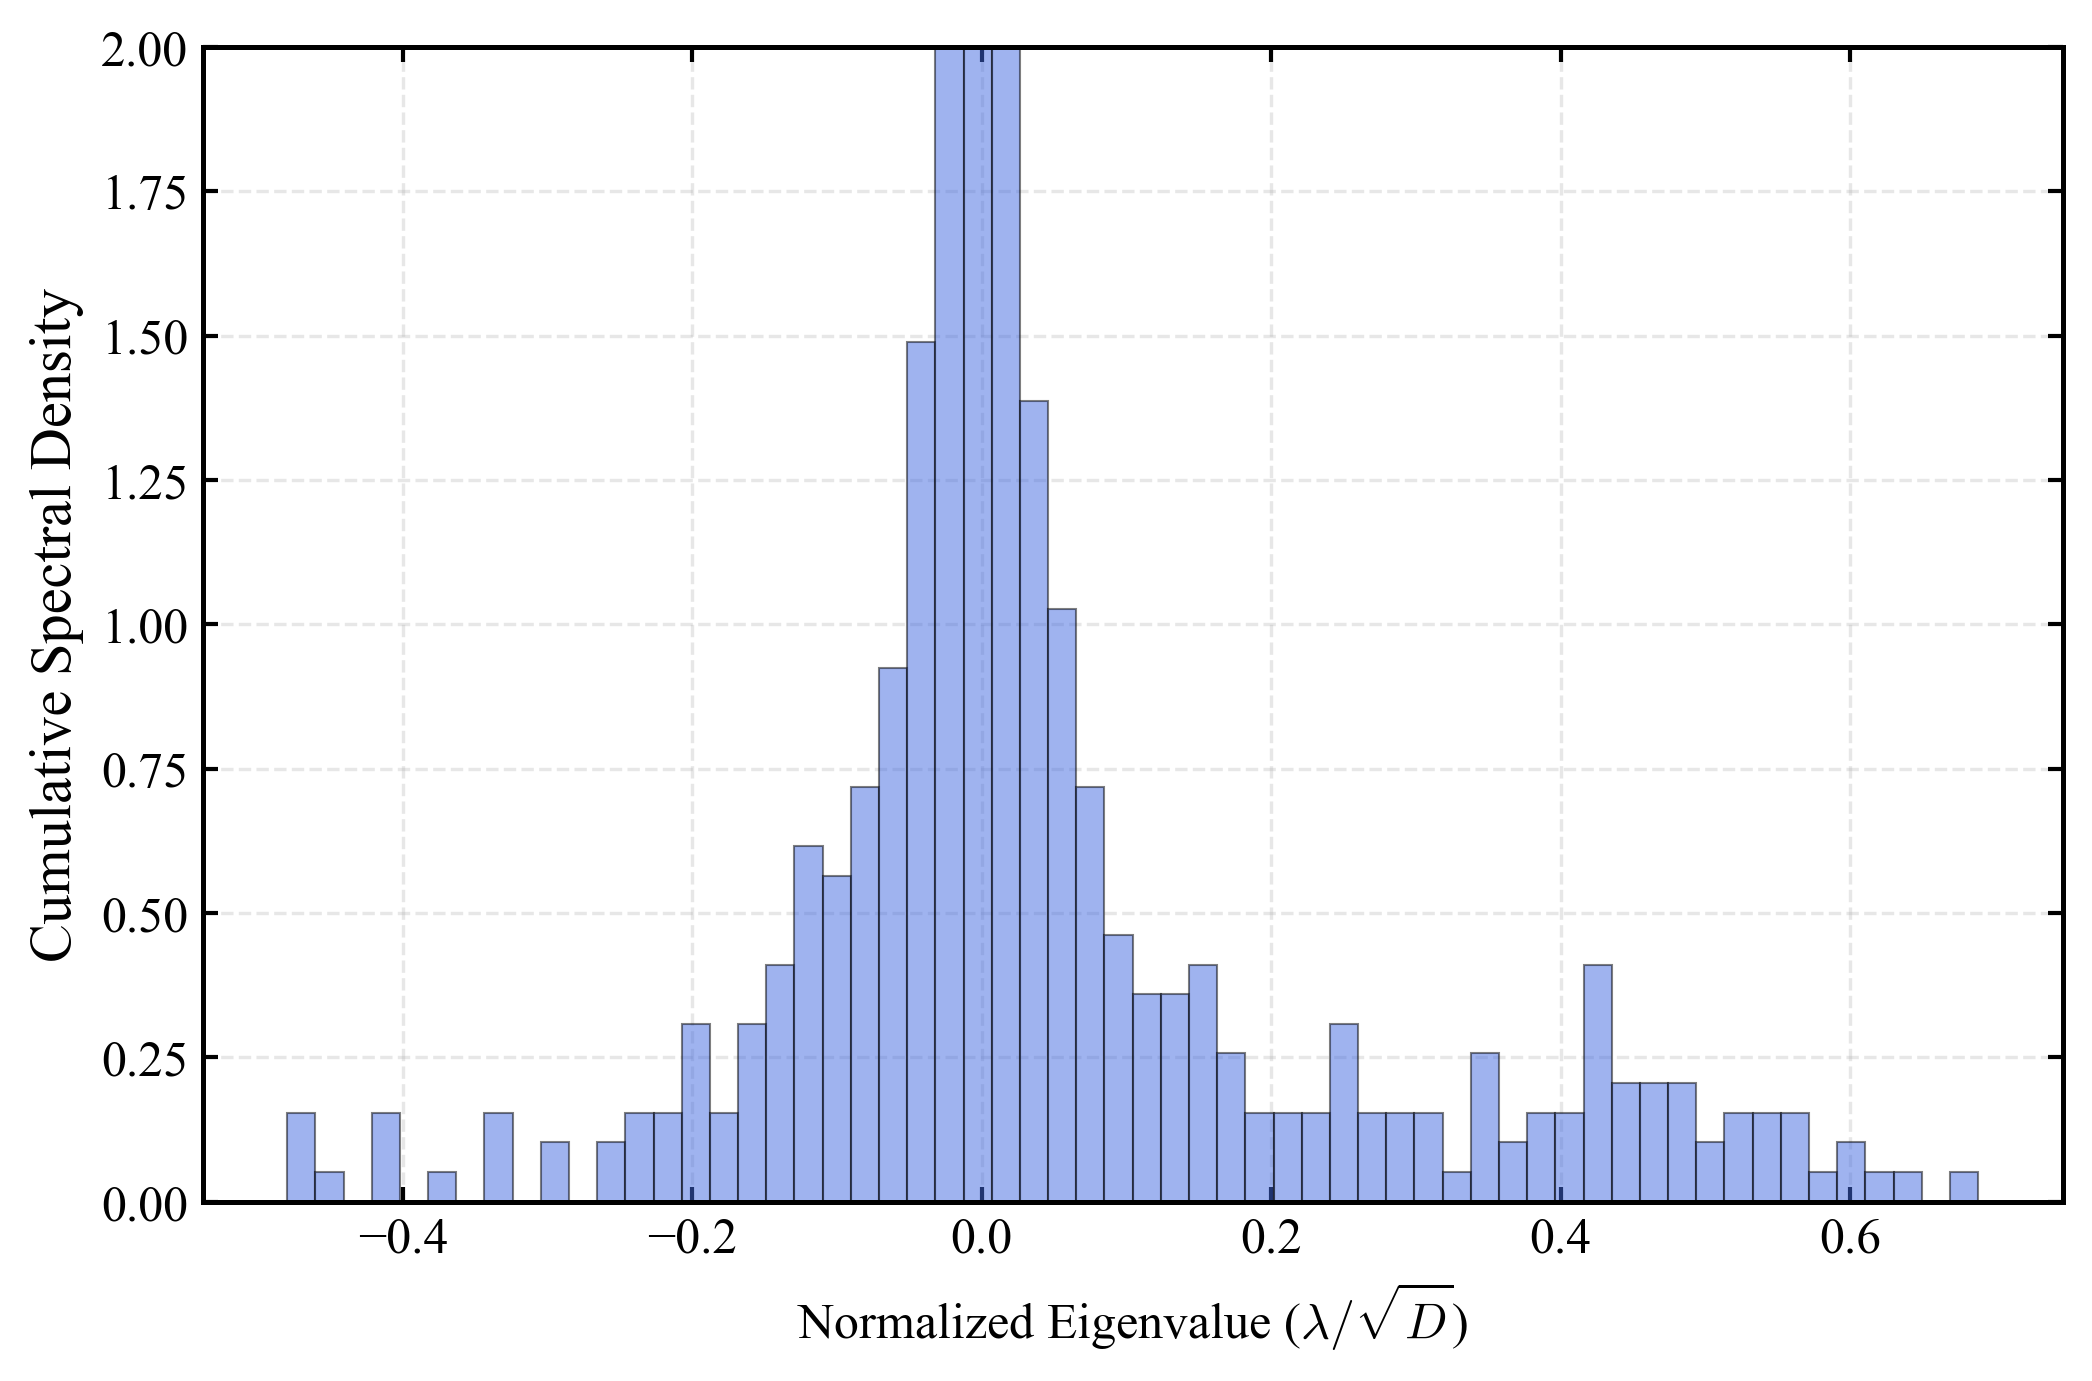

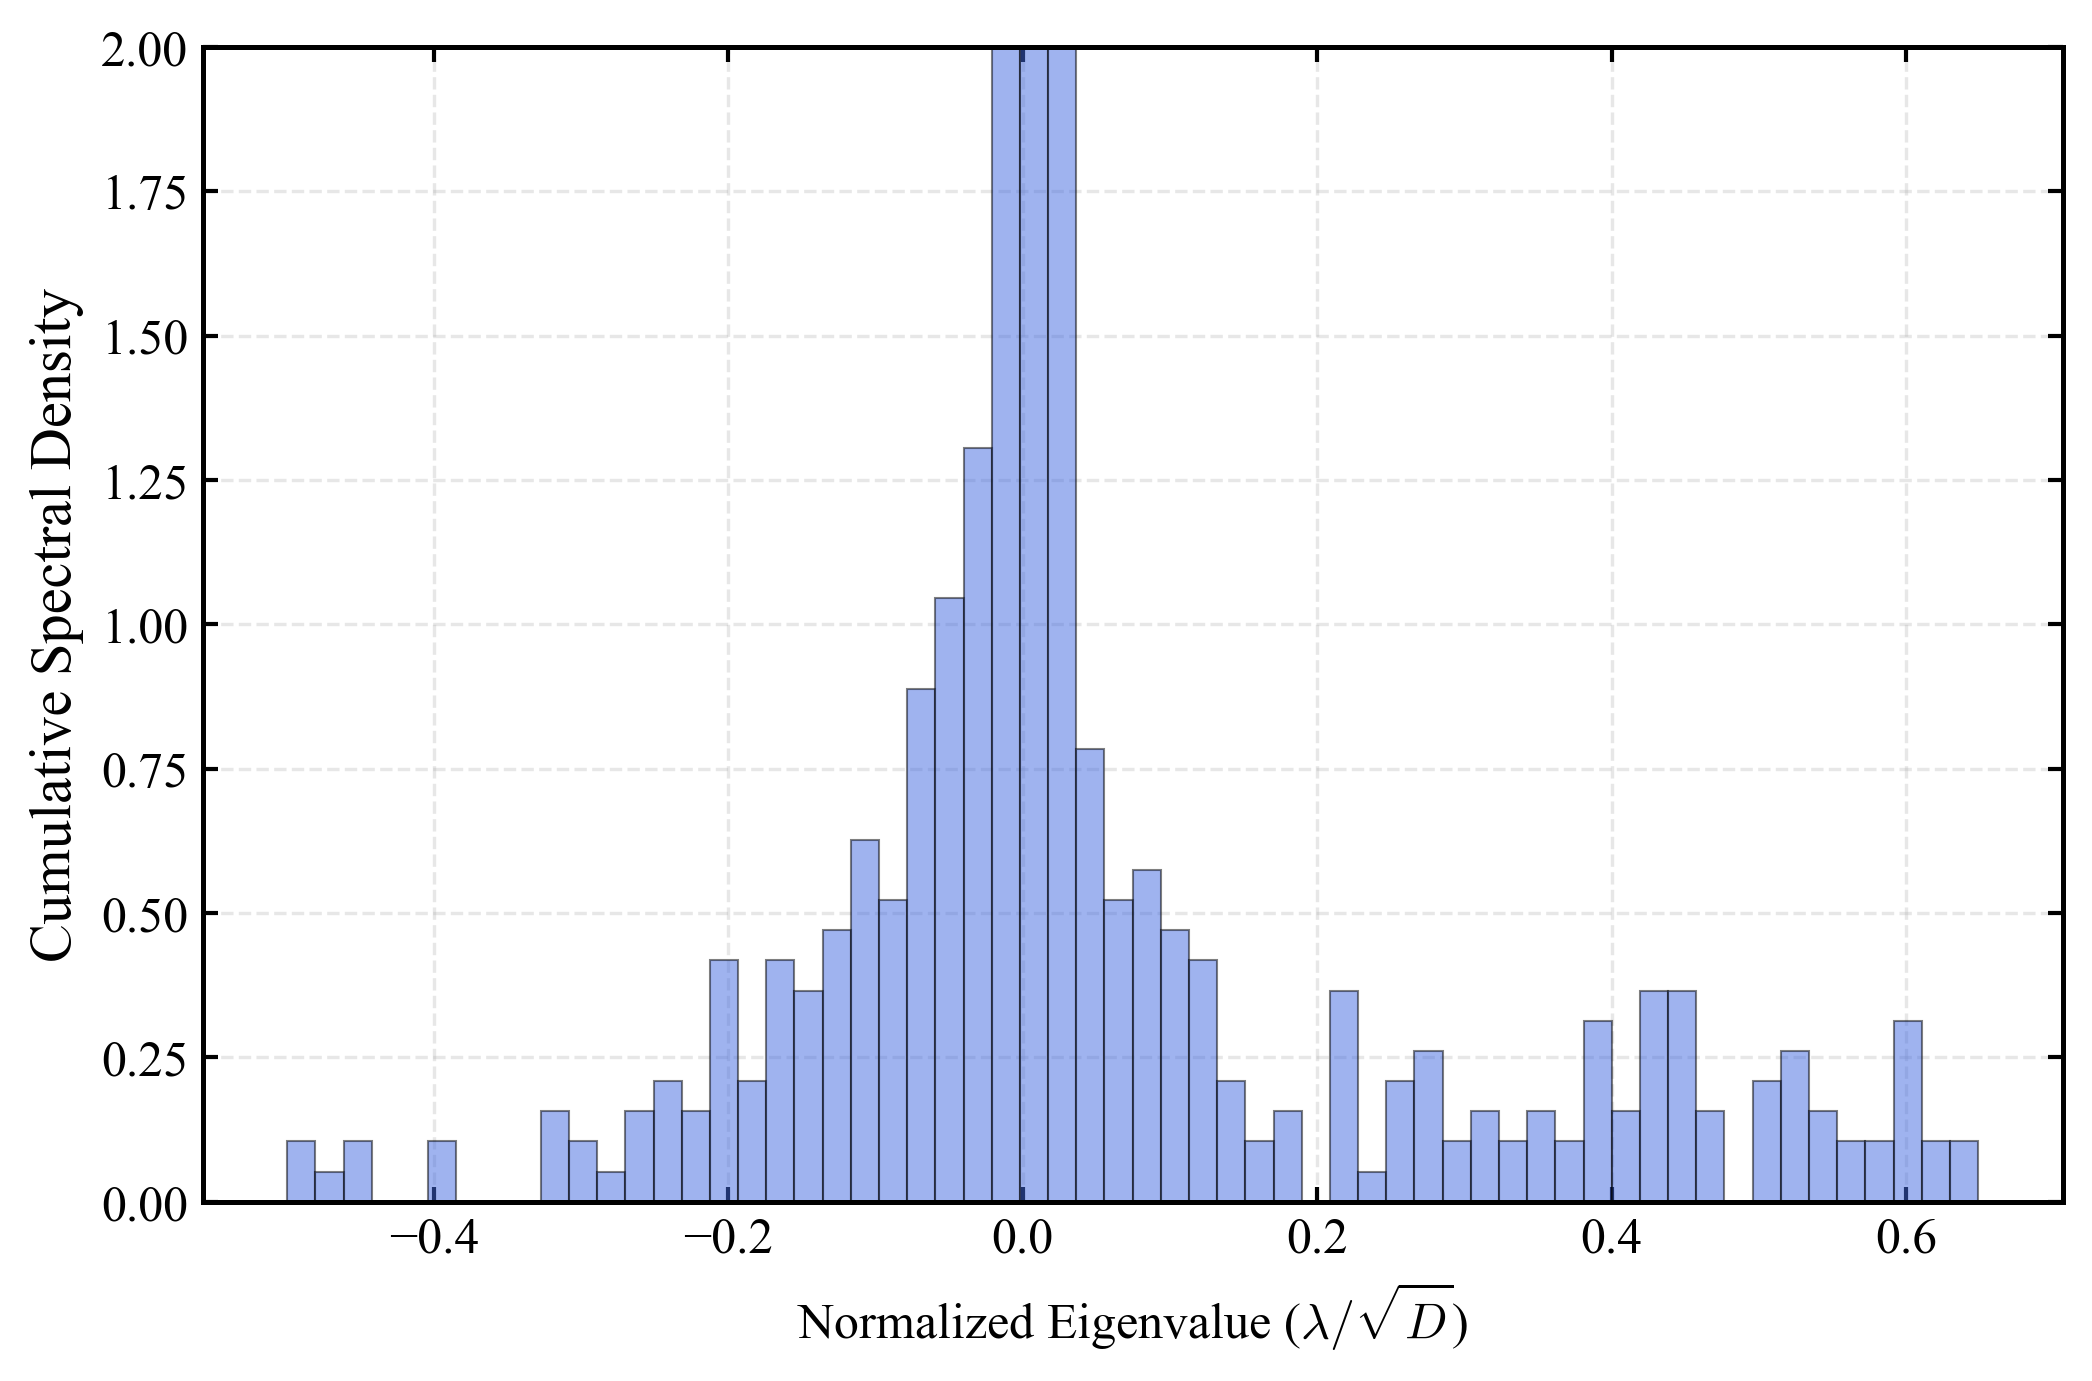

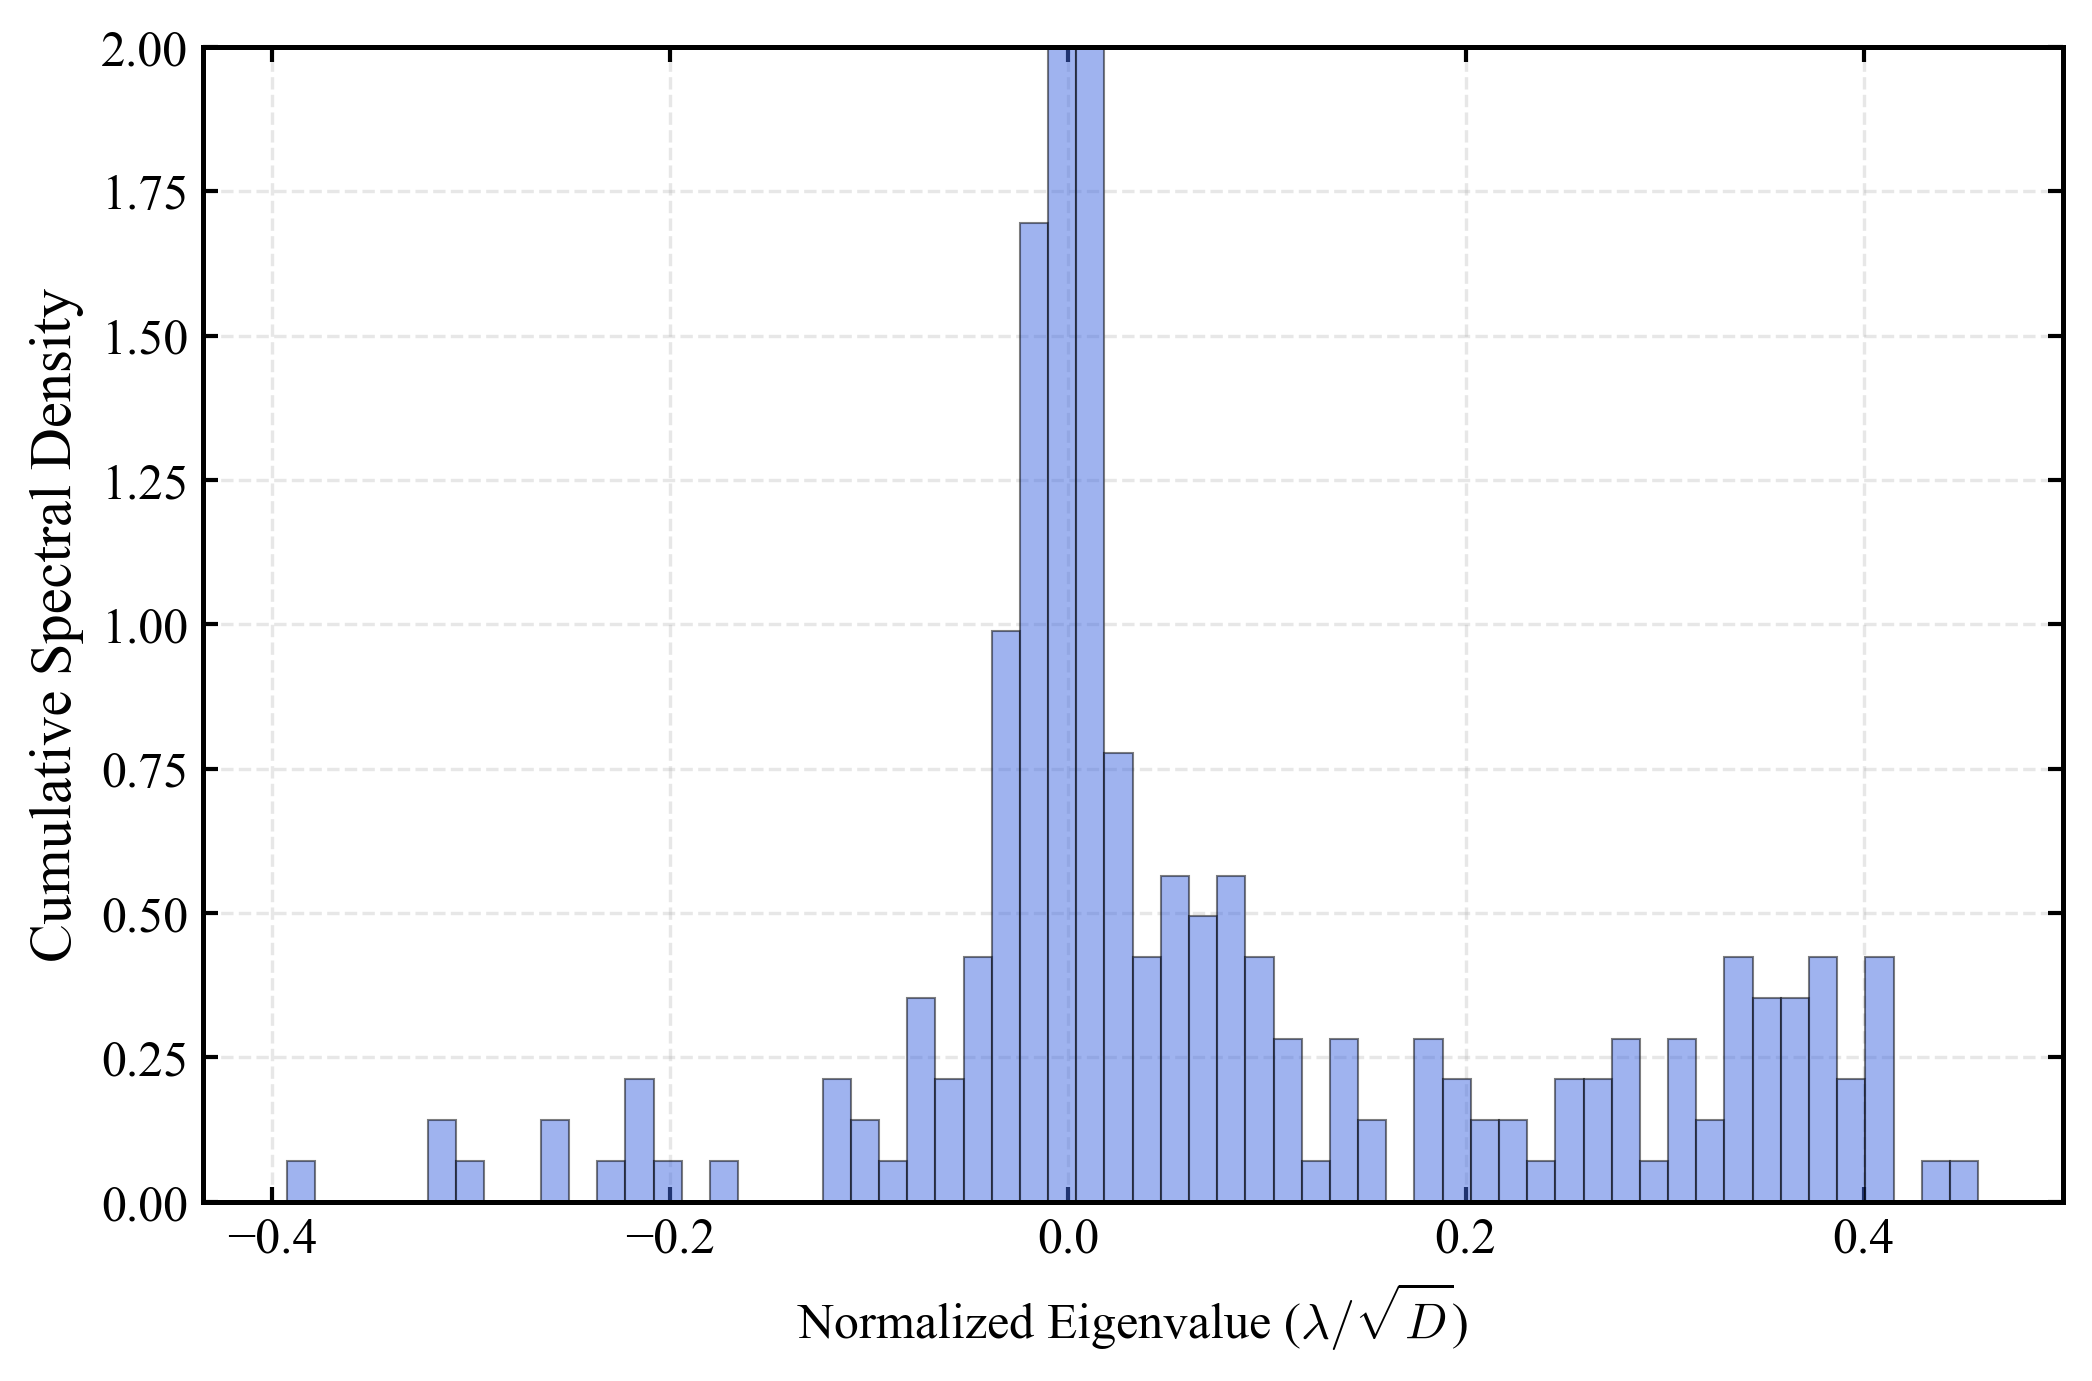

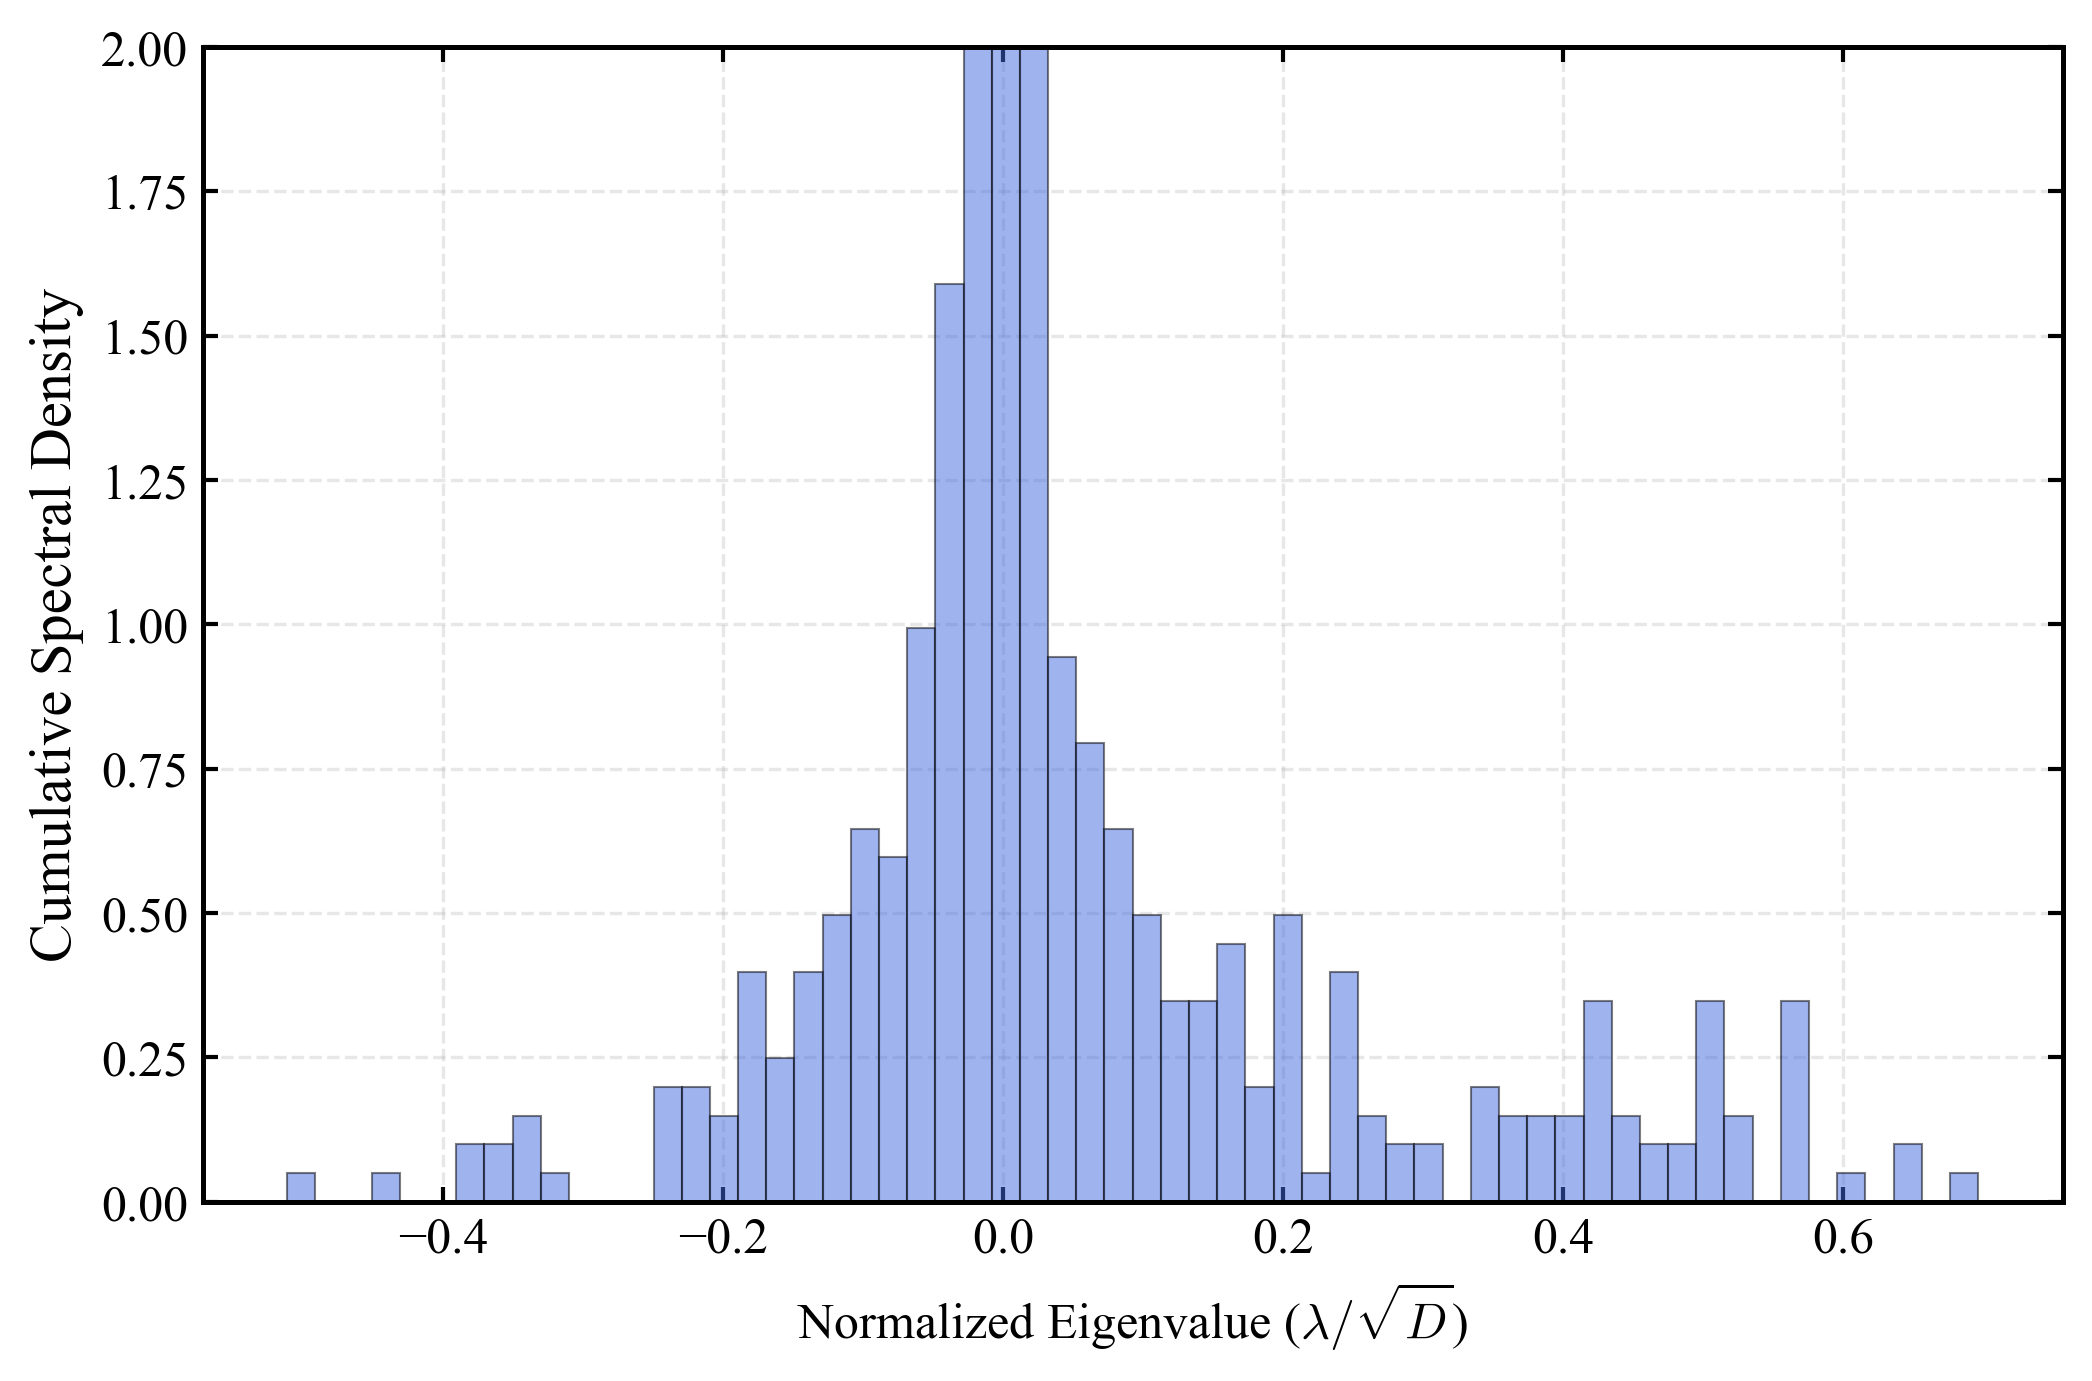

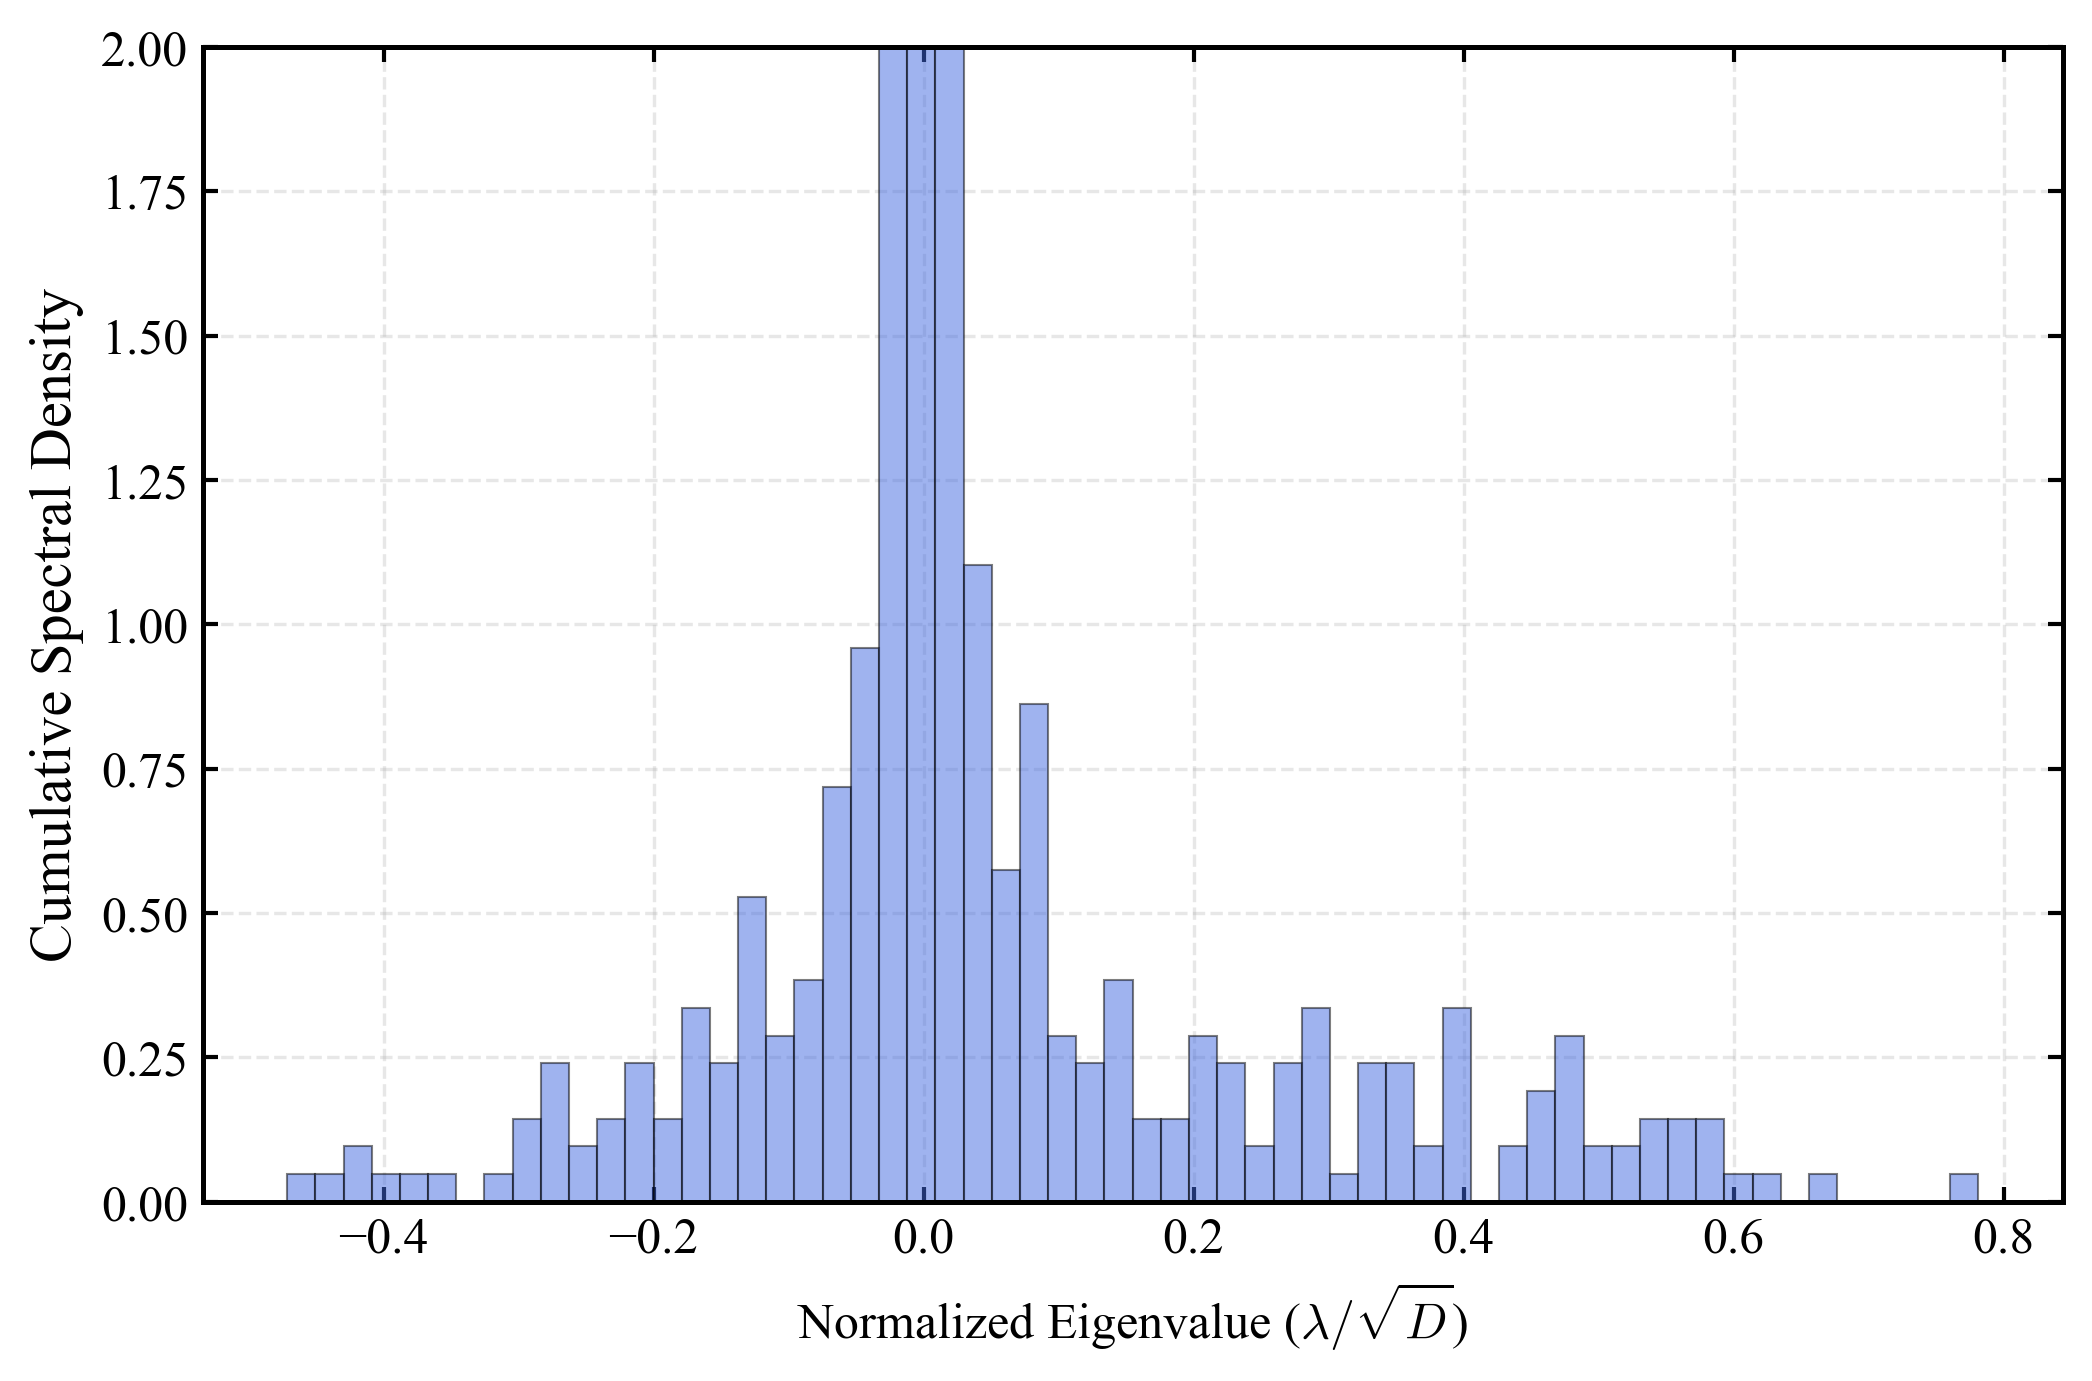

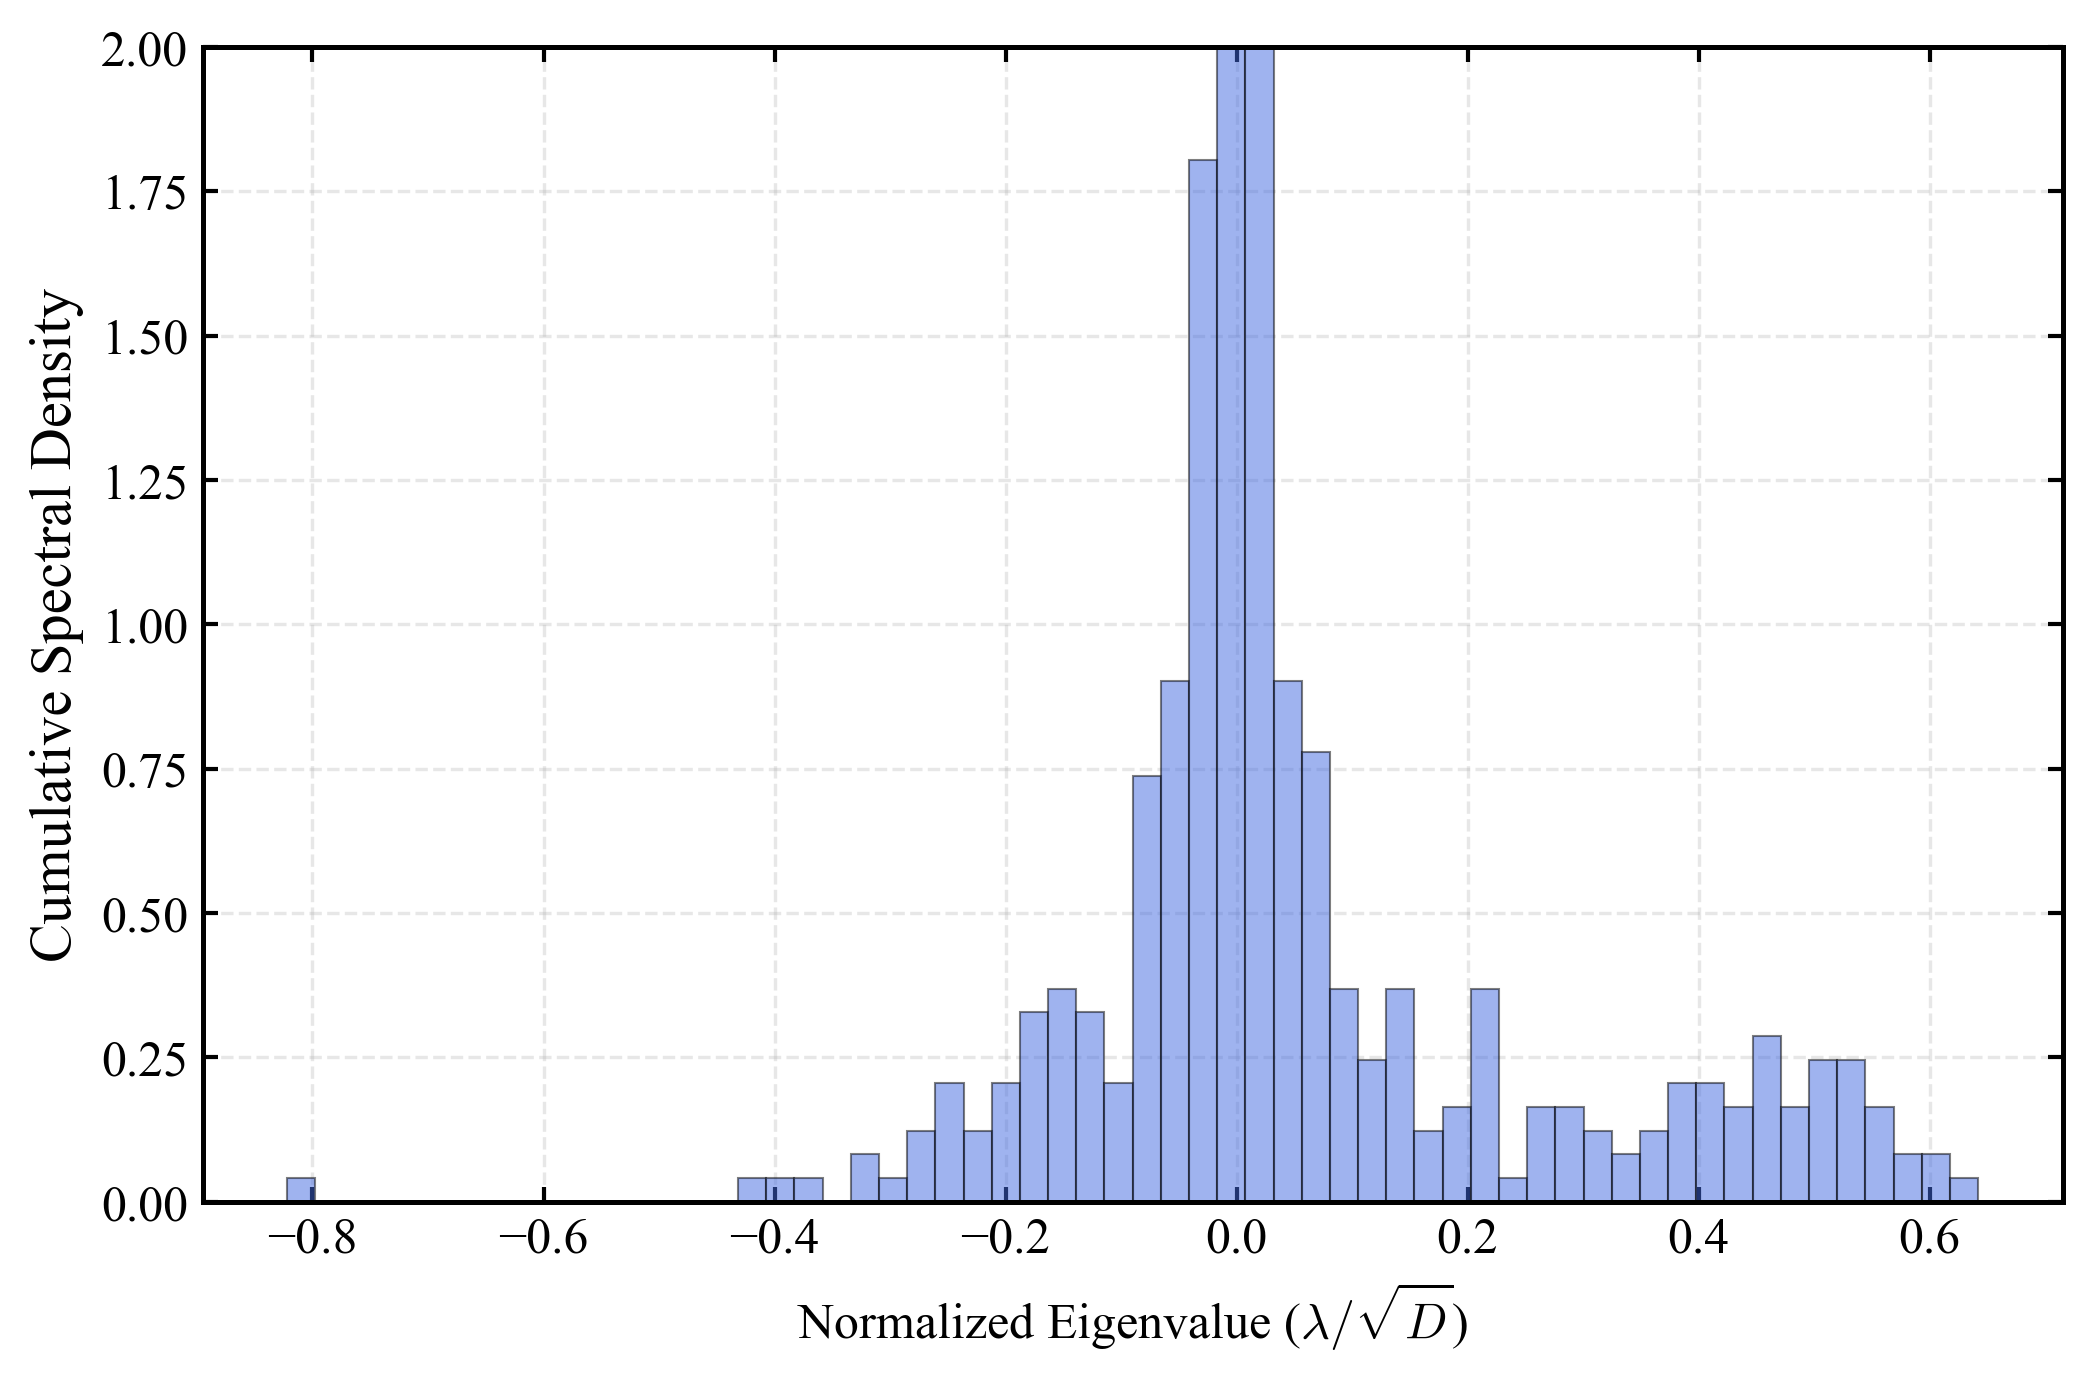

In [57]:
def plot_academic_cumulative_spectra(run_dir, bins_count=60):
    # Locate files
    heavy_files = sorted(glob.glob(os.path.join(run_dir, "heavy_data_*.pkl")))
    print(f"✅ Found {len(heavy_files)} heavy_data files in {run_dir}\n")

    for heavy_file in heavy_files:
        filename = os.path.basename(heavy_file)
        print(f"Processing: {filename}...")

        try:
            with open(heavy_file, "rb") as f:
                data = pickle.load(f)

            # Robust data extraction
            if isinstance(data, dict):
                W_runs_all = data.get("W_runs", [])
            else:
                W_runs_all = data # Handle case where pickle is just the list

            if len(W_runs_all) == 0:
                print("   ⚠️ No W_runs found. Skipping.\n")
                continue

            # --- OPTIMIZATION: One-pass calculation ---
            # Collect all eigenvalues into a single flat array
            all_eigvals_list = []
            for W in W_runs_all:
                # Use eigvalsh for symmetric matrices (faster/stable)
                # If W is not symmetric, use np.linalg.eigvals(W) or np.linalg.svd(W, compute_uv=False)
                eigs = np.linalg.eigvalsh(W)
                all_eigvals_list.append(eigs)
            
            # Concatenate once
            flat_eigvals = np.concatenate(all_eigvals_list / np.sqrt(W.shape[0]))

            # --- PLOTTING ---
            fig, ax = plt.subplots(figsize=(8, 5))
            
            # Stats for legend
            mu = np.mean(flat_eigvals)
            sigma = np.std(flat_eigvals)

            # Histogram
            # density=True is standard for comparing distributions (area sum = 1)
            ax.hist(
                flat_eigvals,
                bins=bins_count,
                density=True,     # Change to False if you want absolute counts
                alpha=0.5,
                color='royalblue',  # Standard academic blue
                edgecolor='black',
                linewidth=0.5,
                label=fr"Empirical ESD" + "\n" + fr"$\mu={mu:.2f}, \sigma={sigma:.2f}$"
            )

            # Labels
            ax.set_xlabel(r"Normalized Eigenvalue ($\lambda / \sqrt{D}$)", fontsize=12)
            ax.set_ylabel("Cumulative Spectral Density") # Or "Frequency" if density=False
            
            # Optional Title (often removed in papers, but good for exploration)
            # ax.set_title(f"Spectrum: {filename}")

            # --- BOX STYLE ---
            ax.set_axisbelow(True)
            ax.tick_params(direction='in', top=True, right=True, which='both', width=1.0)
            
            for spine in ax.spines.values():
                spine.set_edgecolor('black')
                spine.set_linewidth(1.2)

            ax.set_ylim(bottom=0, top=2)

            # Legend
            # ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0, loc='best')

            # Save
            out_filename = f"spectrum_{filename.replace('.pkl', '.png')}"
            out_path = os.path.join(plot_path, out_filename)
            plt.savefig(out_path)
            print(f"   📊 Saved plot: {out_path}\n")

        except Exception as e:
            print(f"   ❌ Error processing {filename}: {e}\n")

# --- Execution ---
# Ensure run_dir is defined
# run_dir = "../results/run_1" 
plot_academic_cumulative_spectra(run_dir)

Found 15 attention files and 15 preds files
Les images seront sauvegardées dans : ../results/run_20251217_1517/plots
Processing file: attn_0.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_0_run3.png


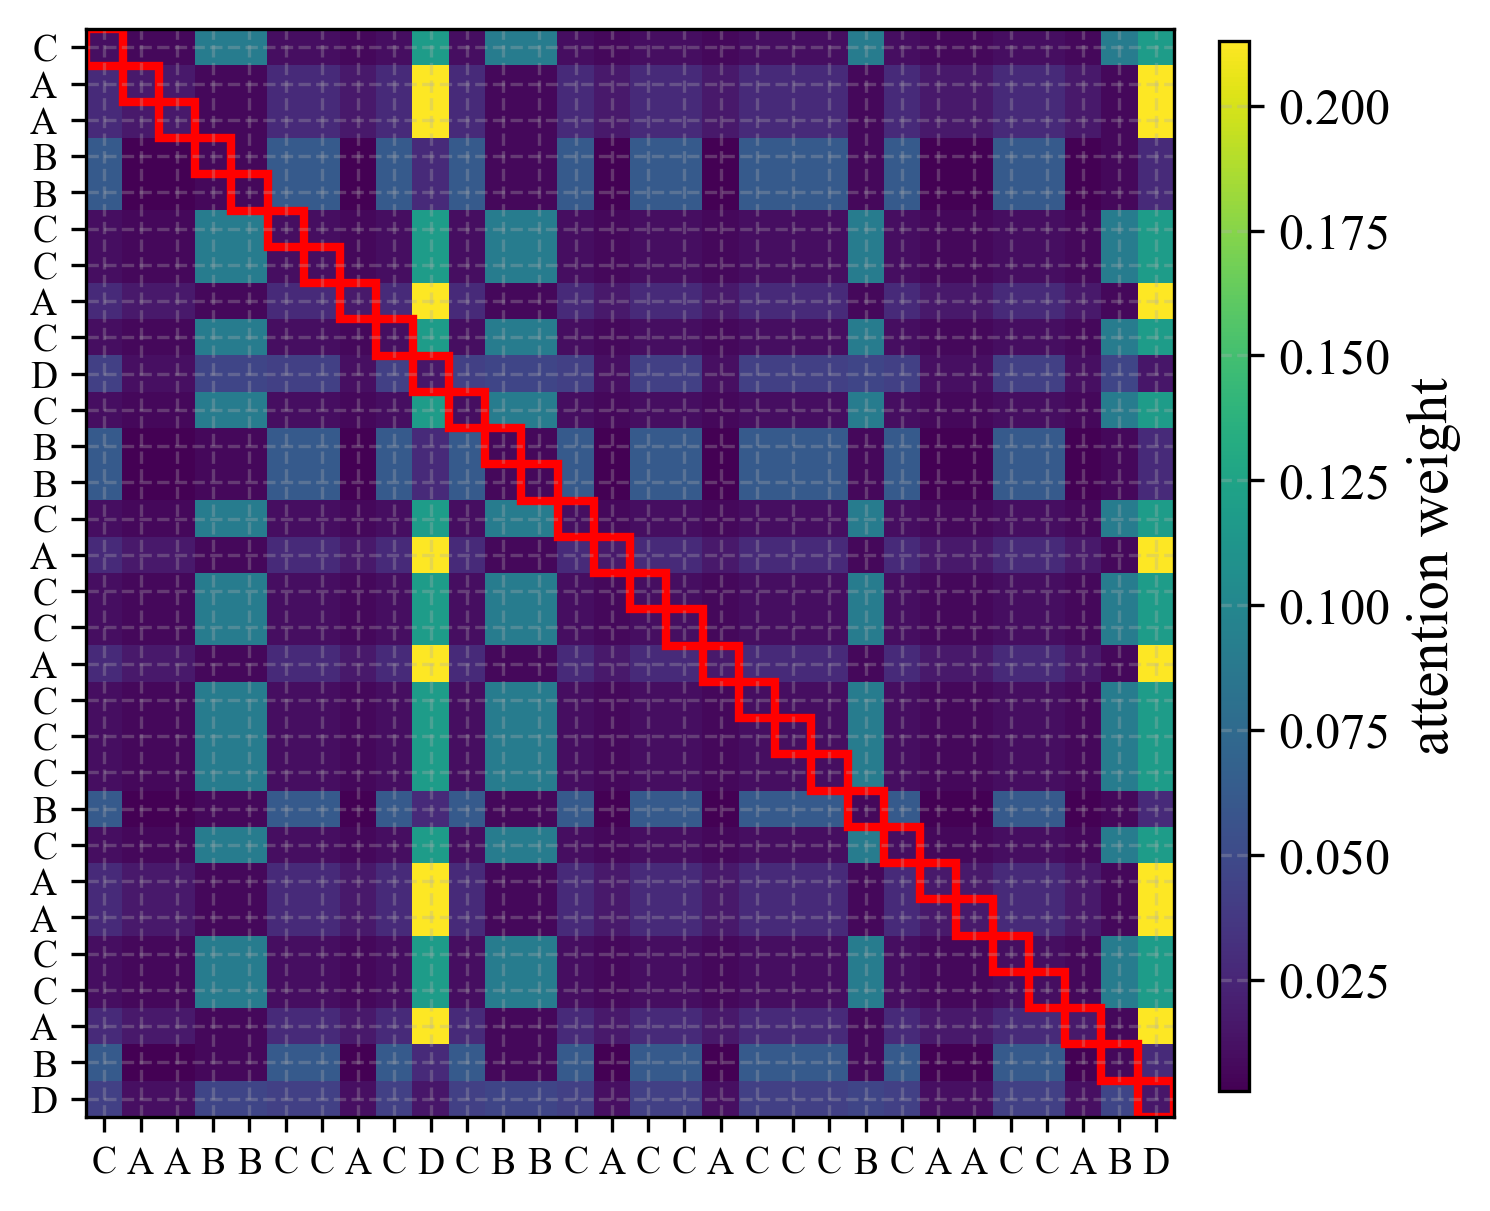

Processing file: attn_1.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_1_run3.png


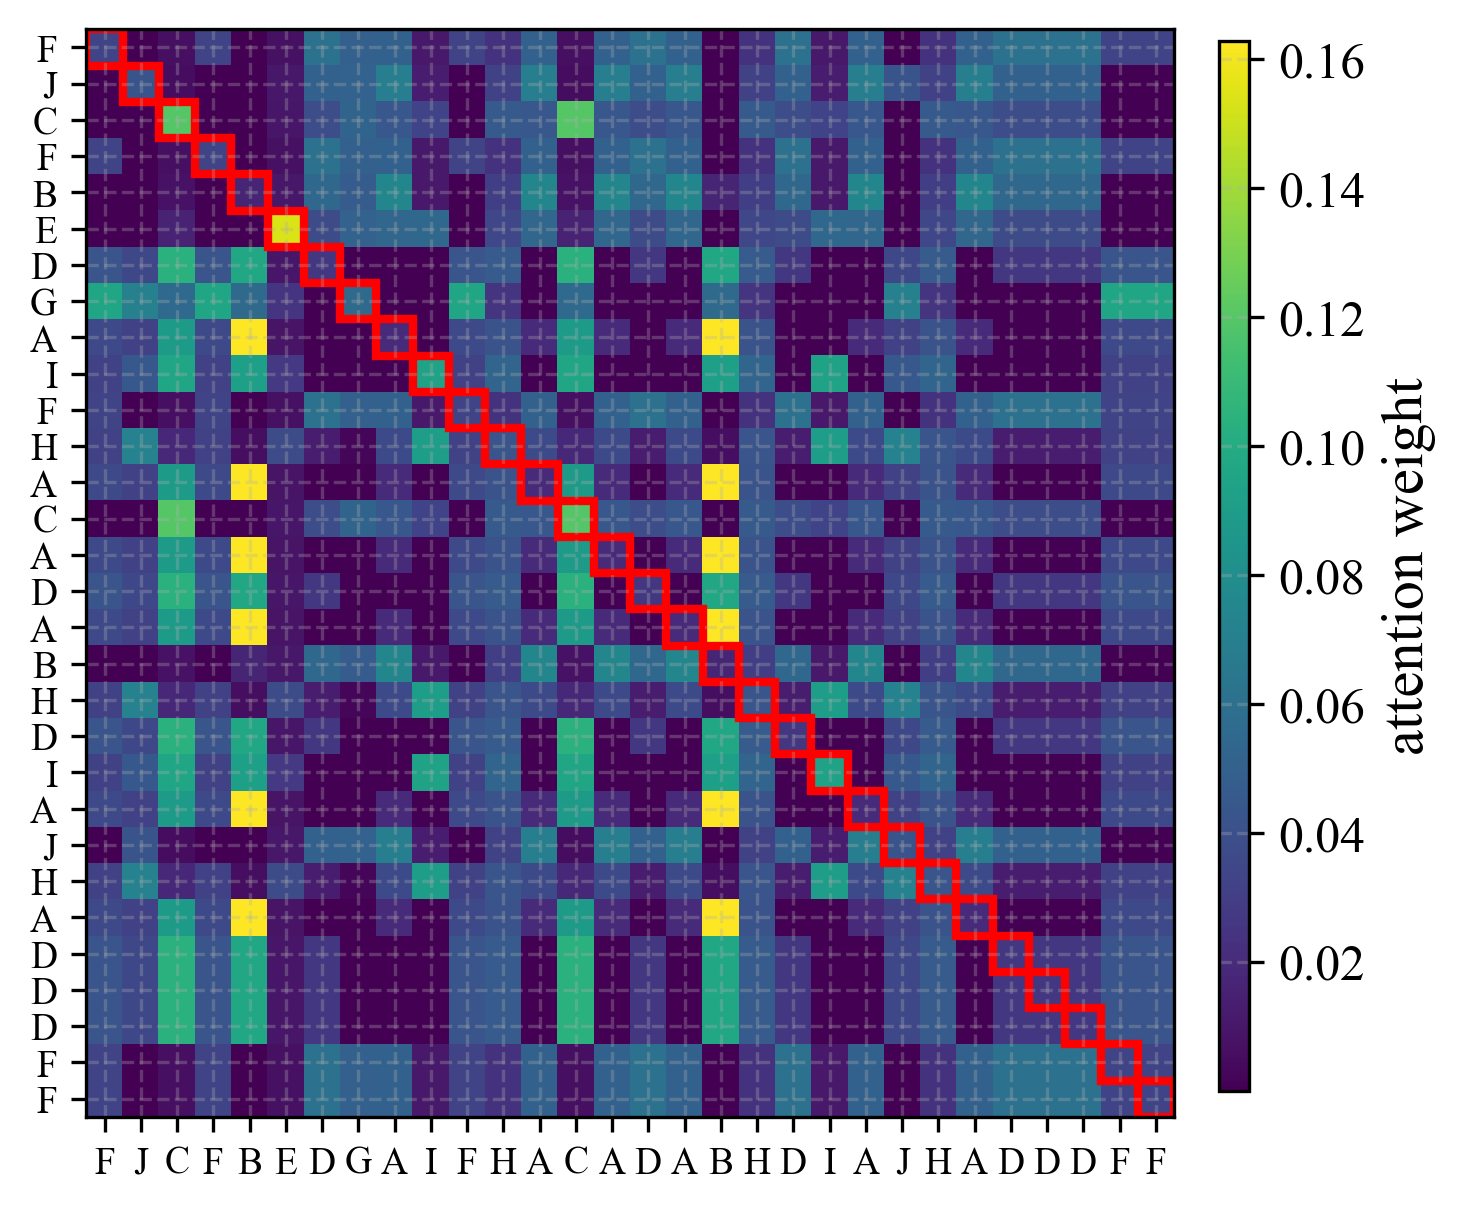

Processing file: attn_10.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_10_run3.png


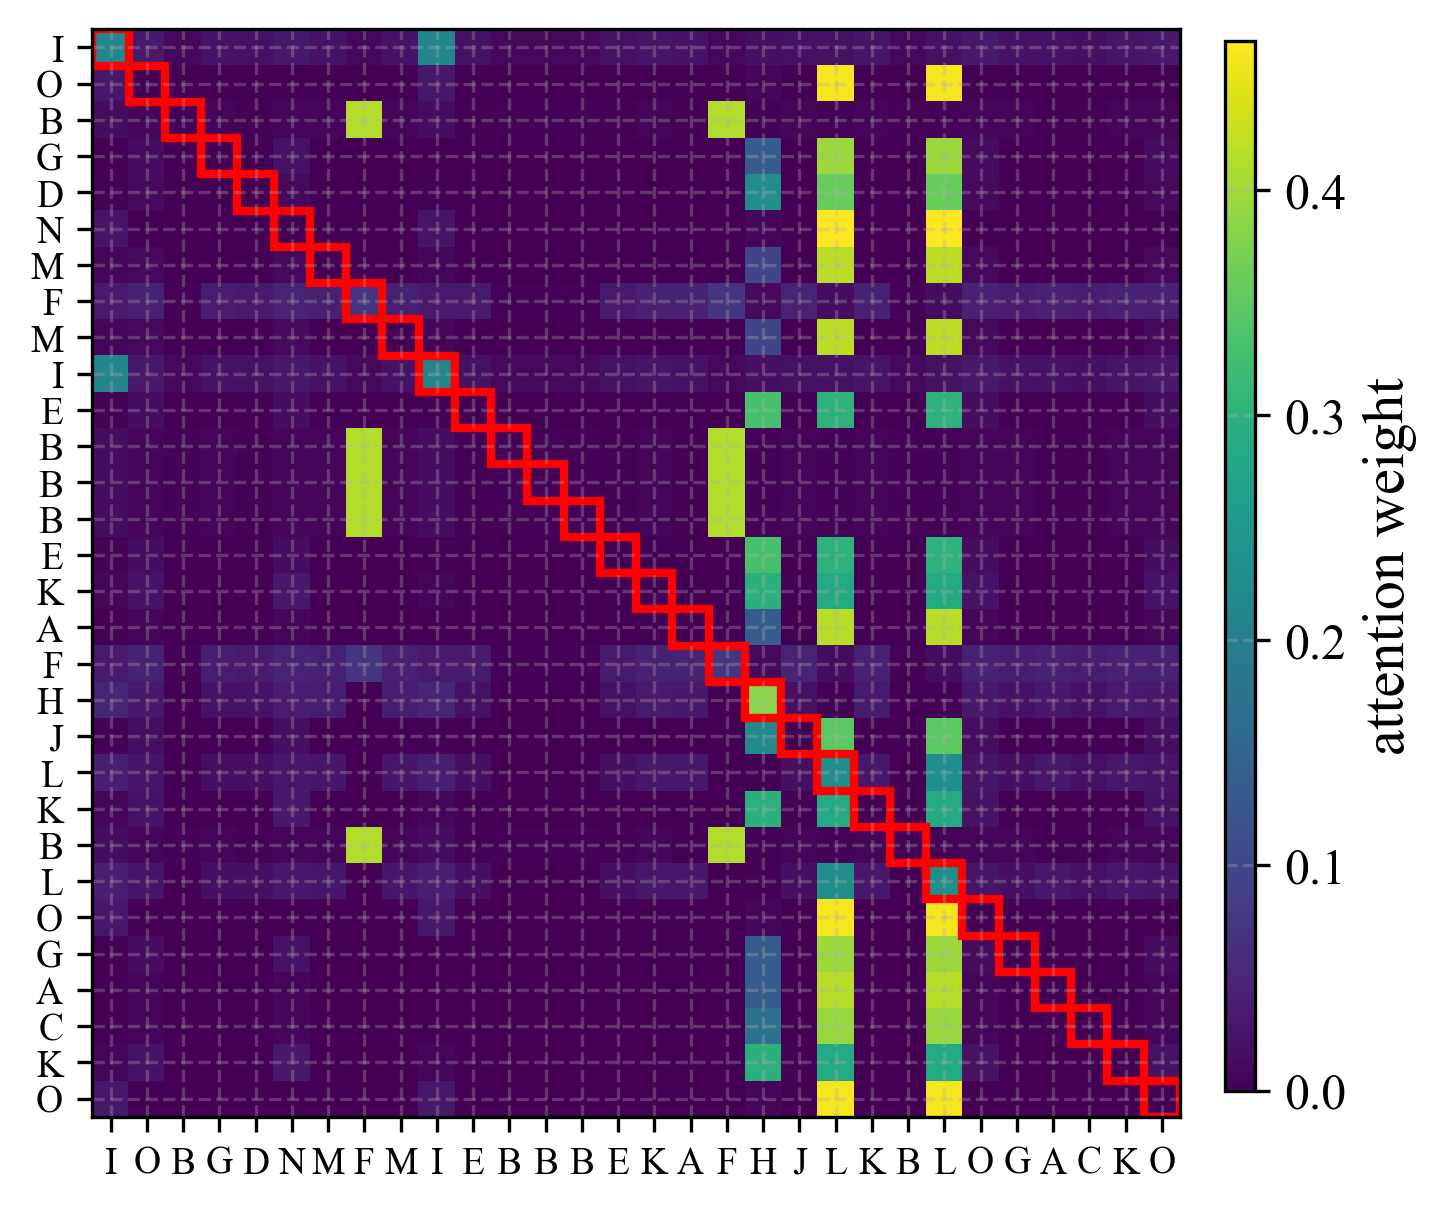

Processing file: attn_11.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_11_run3.png


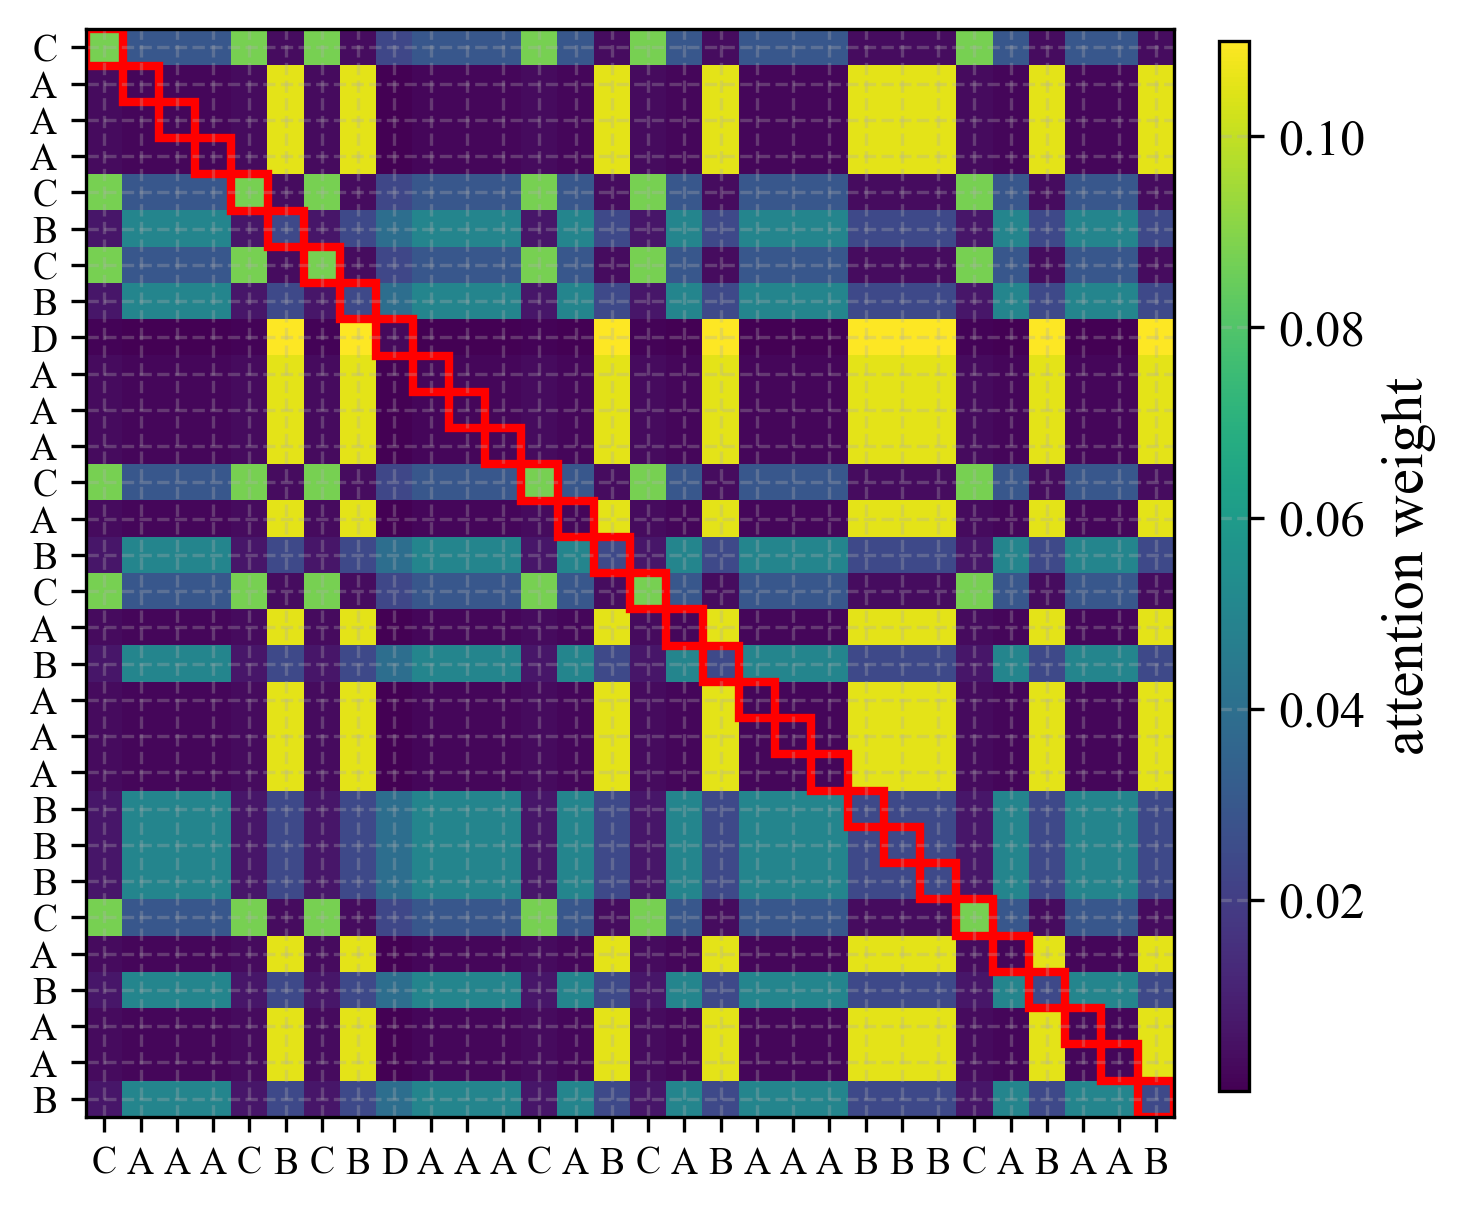

Processing file: attn_12.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_12_run3.png


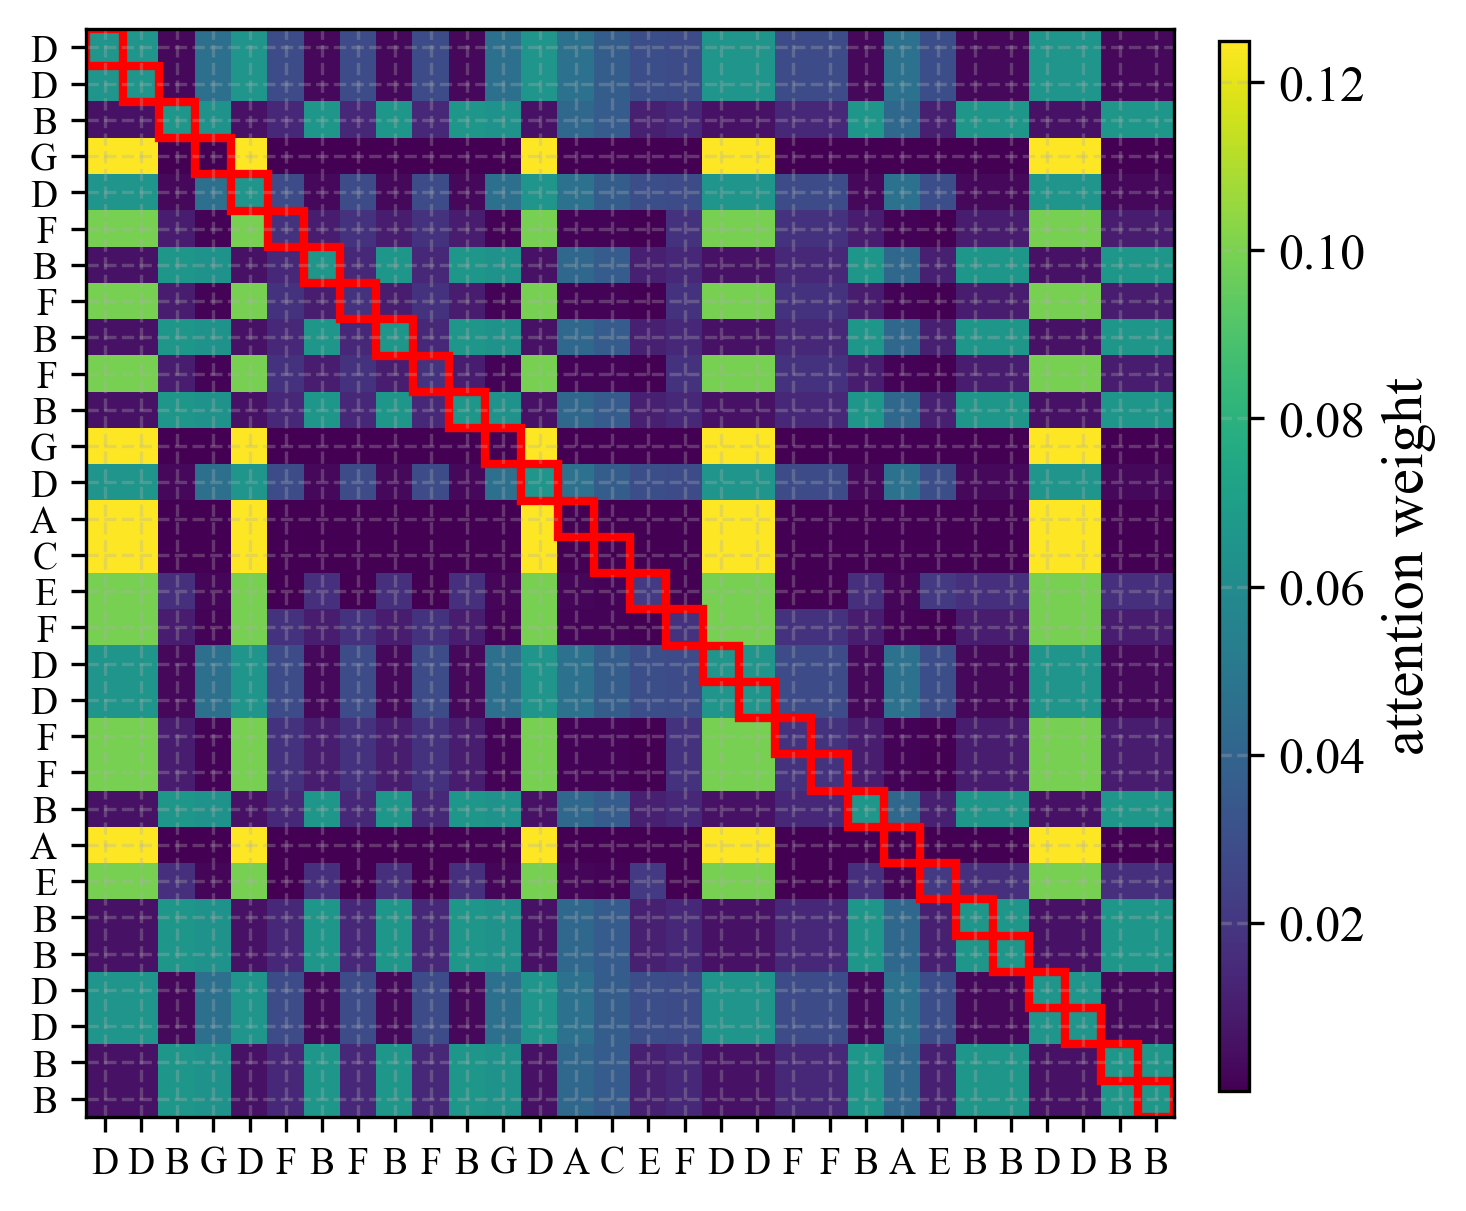

Processing file: attn_13.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_13_run3.png


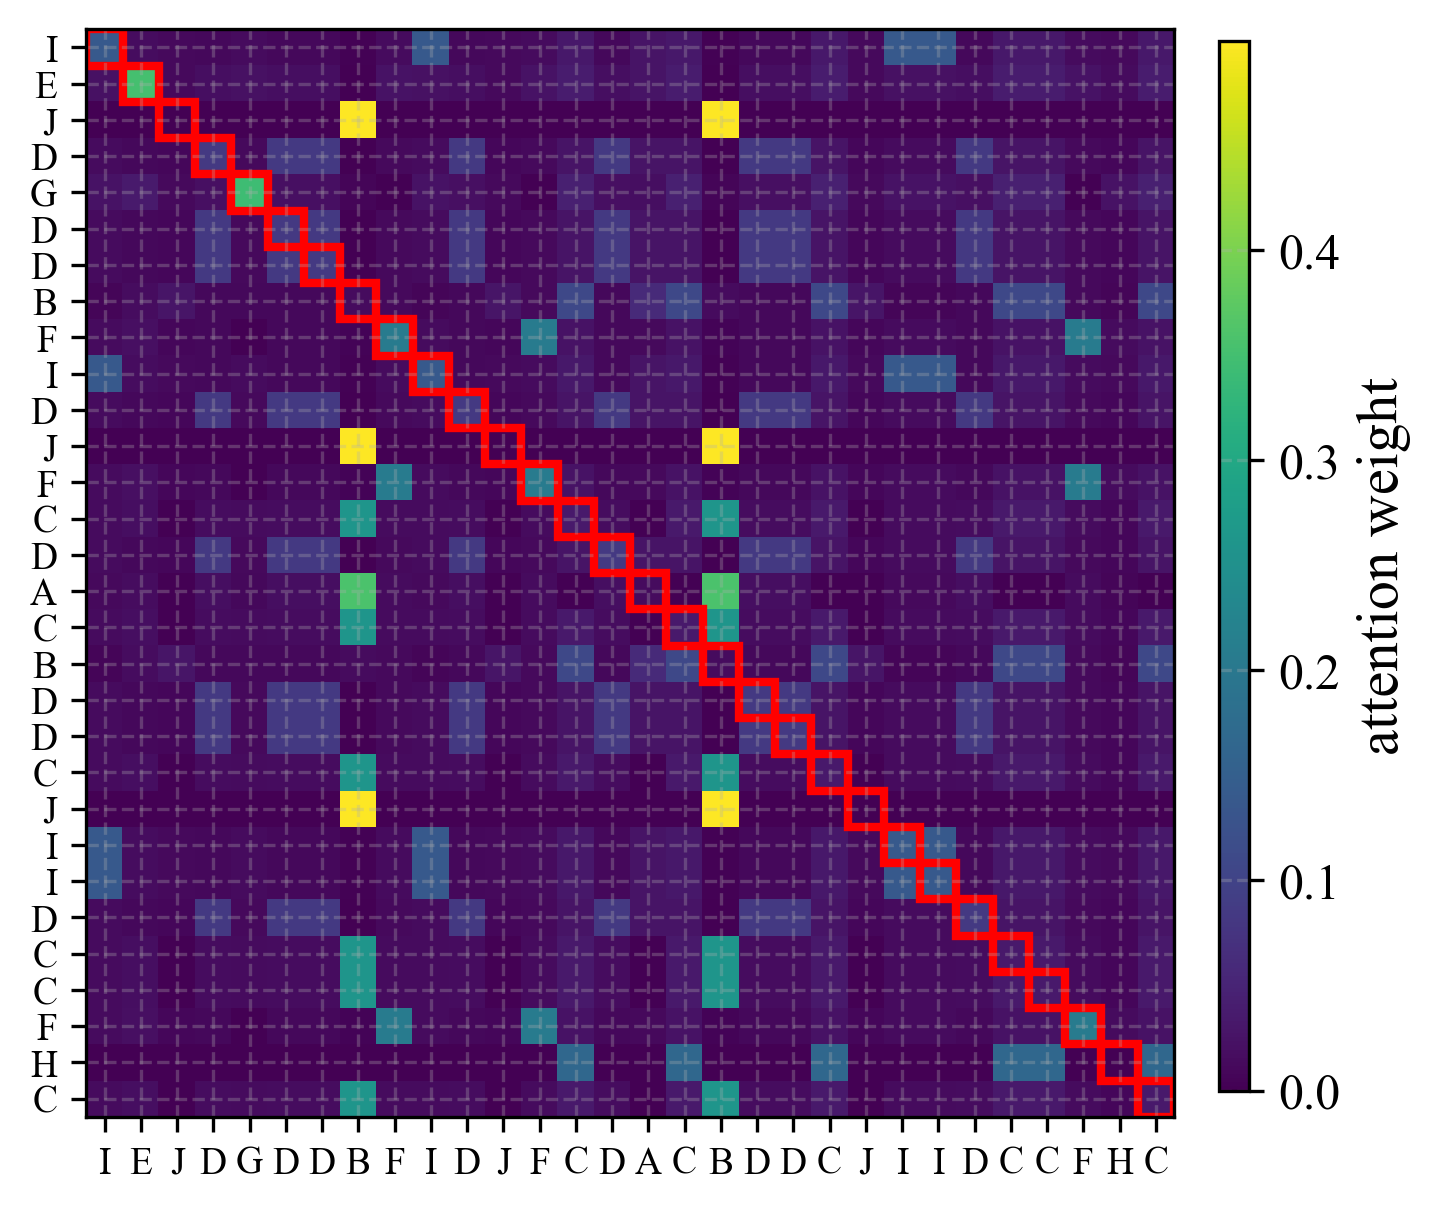

Processing file: attn_14.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_14_run3.png


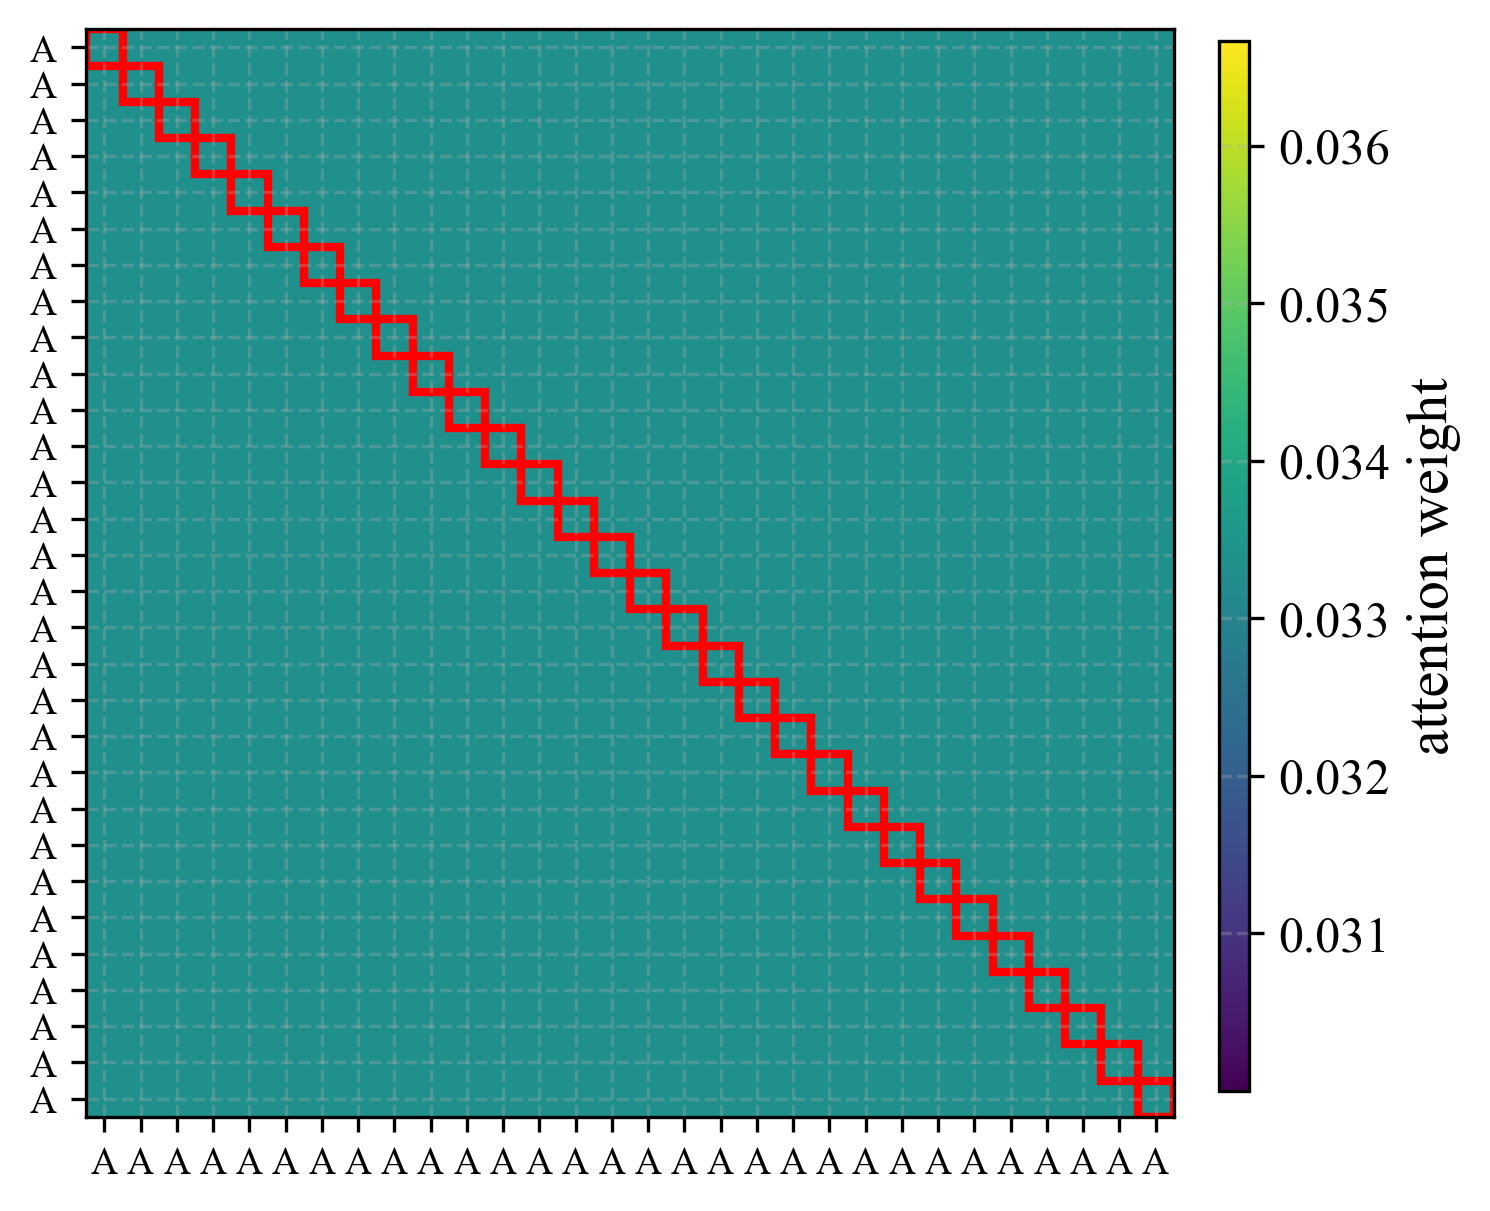

Processing file: attn_2.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_2_run3.png


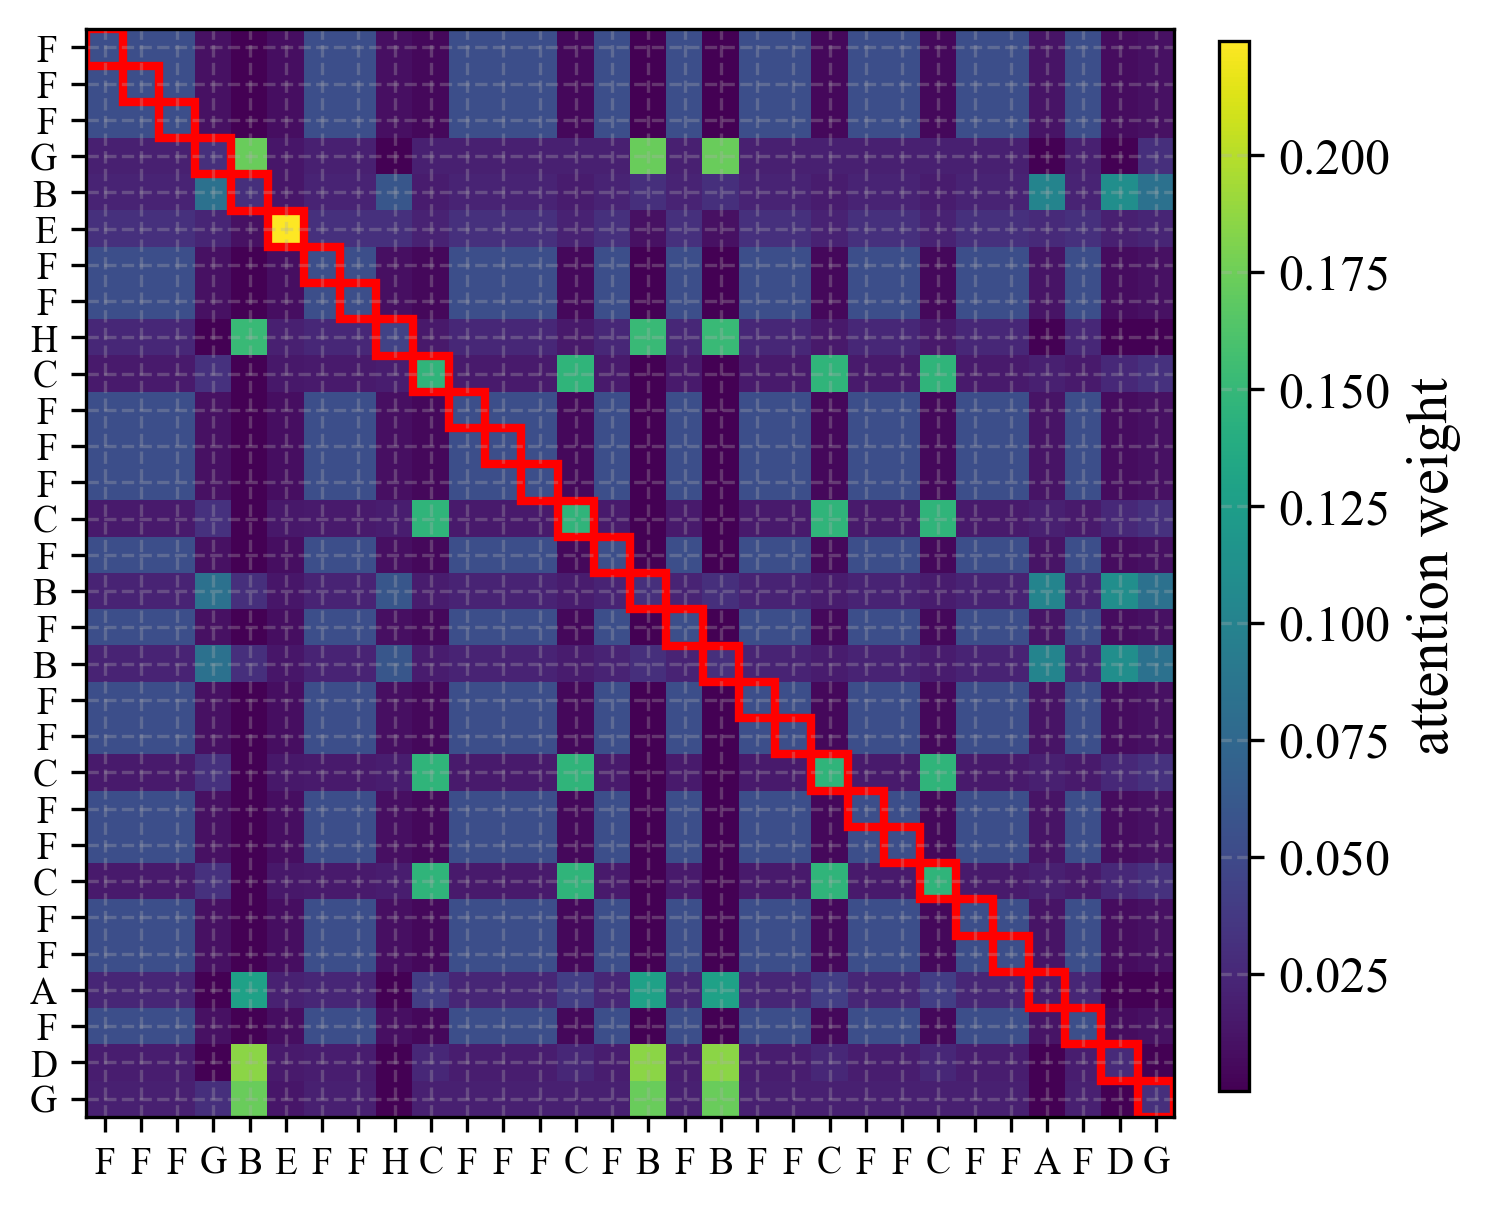

Processing file: attn_3.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_3_run3.png


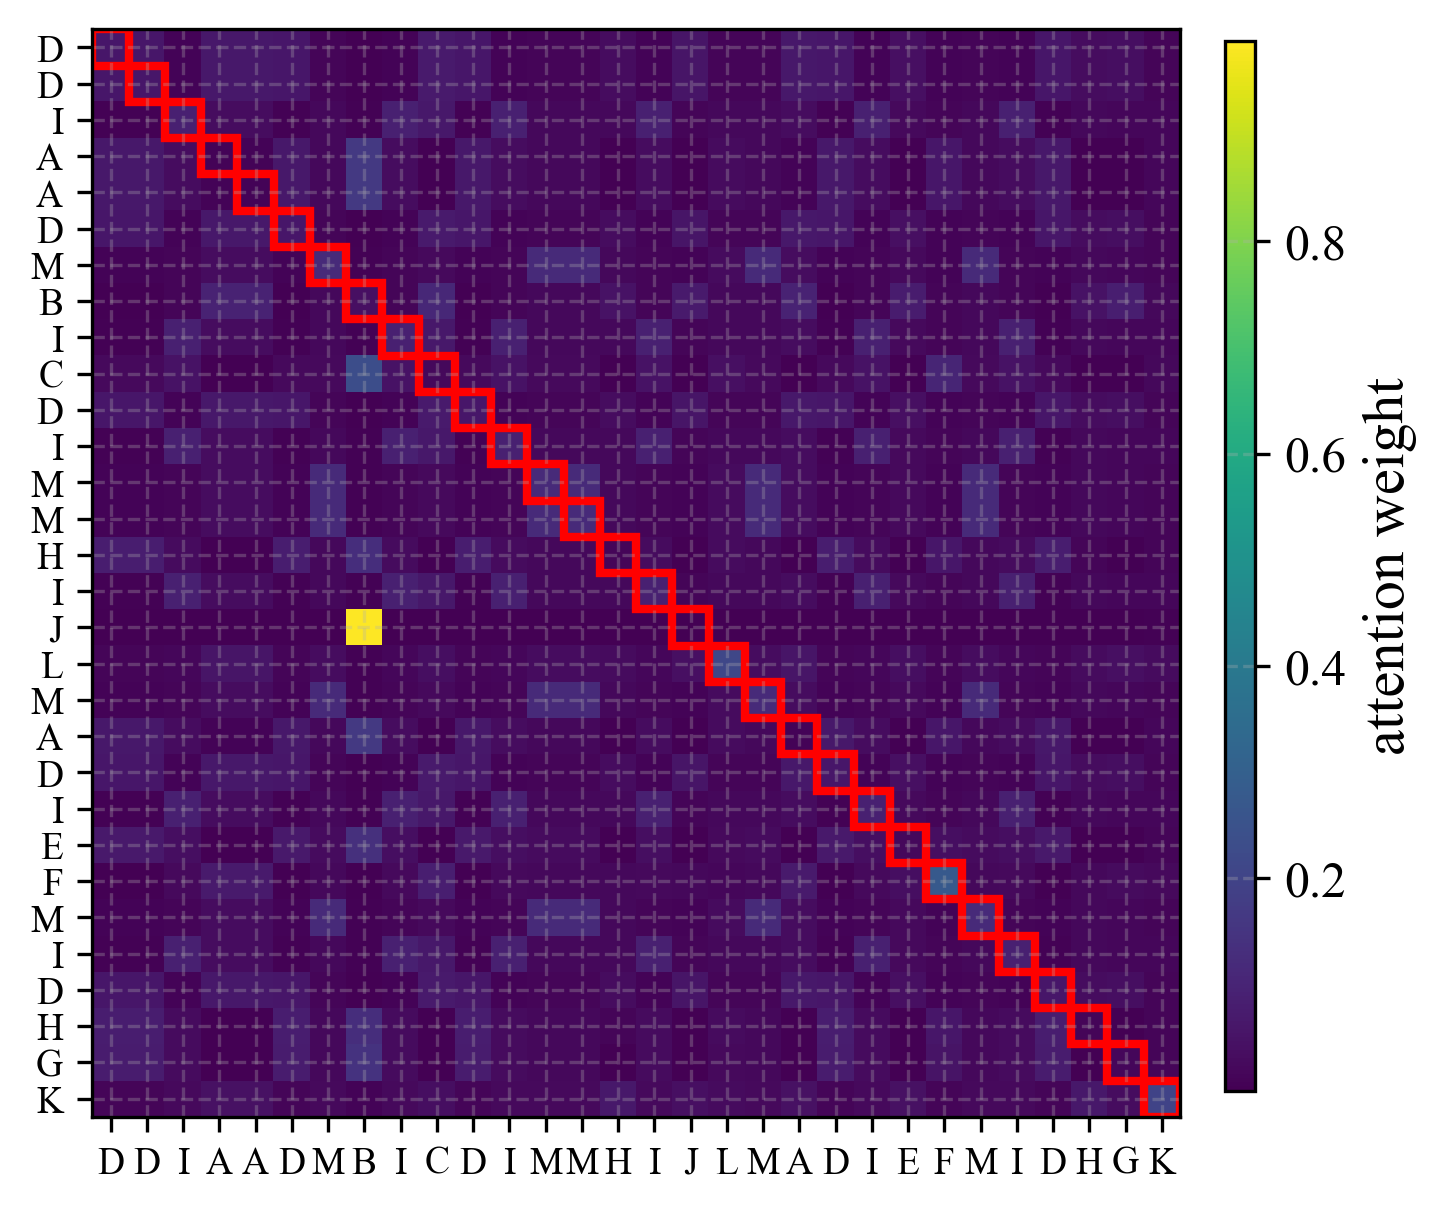

Processing file: attn_4.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_4_run3.png


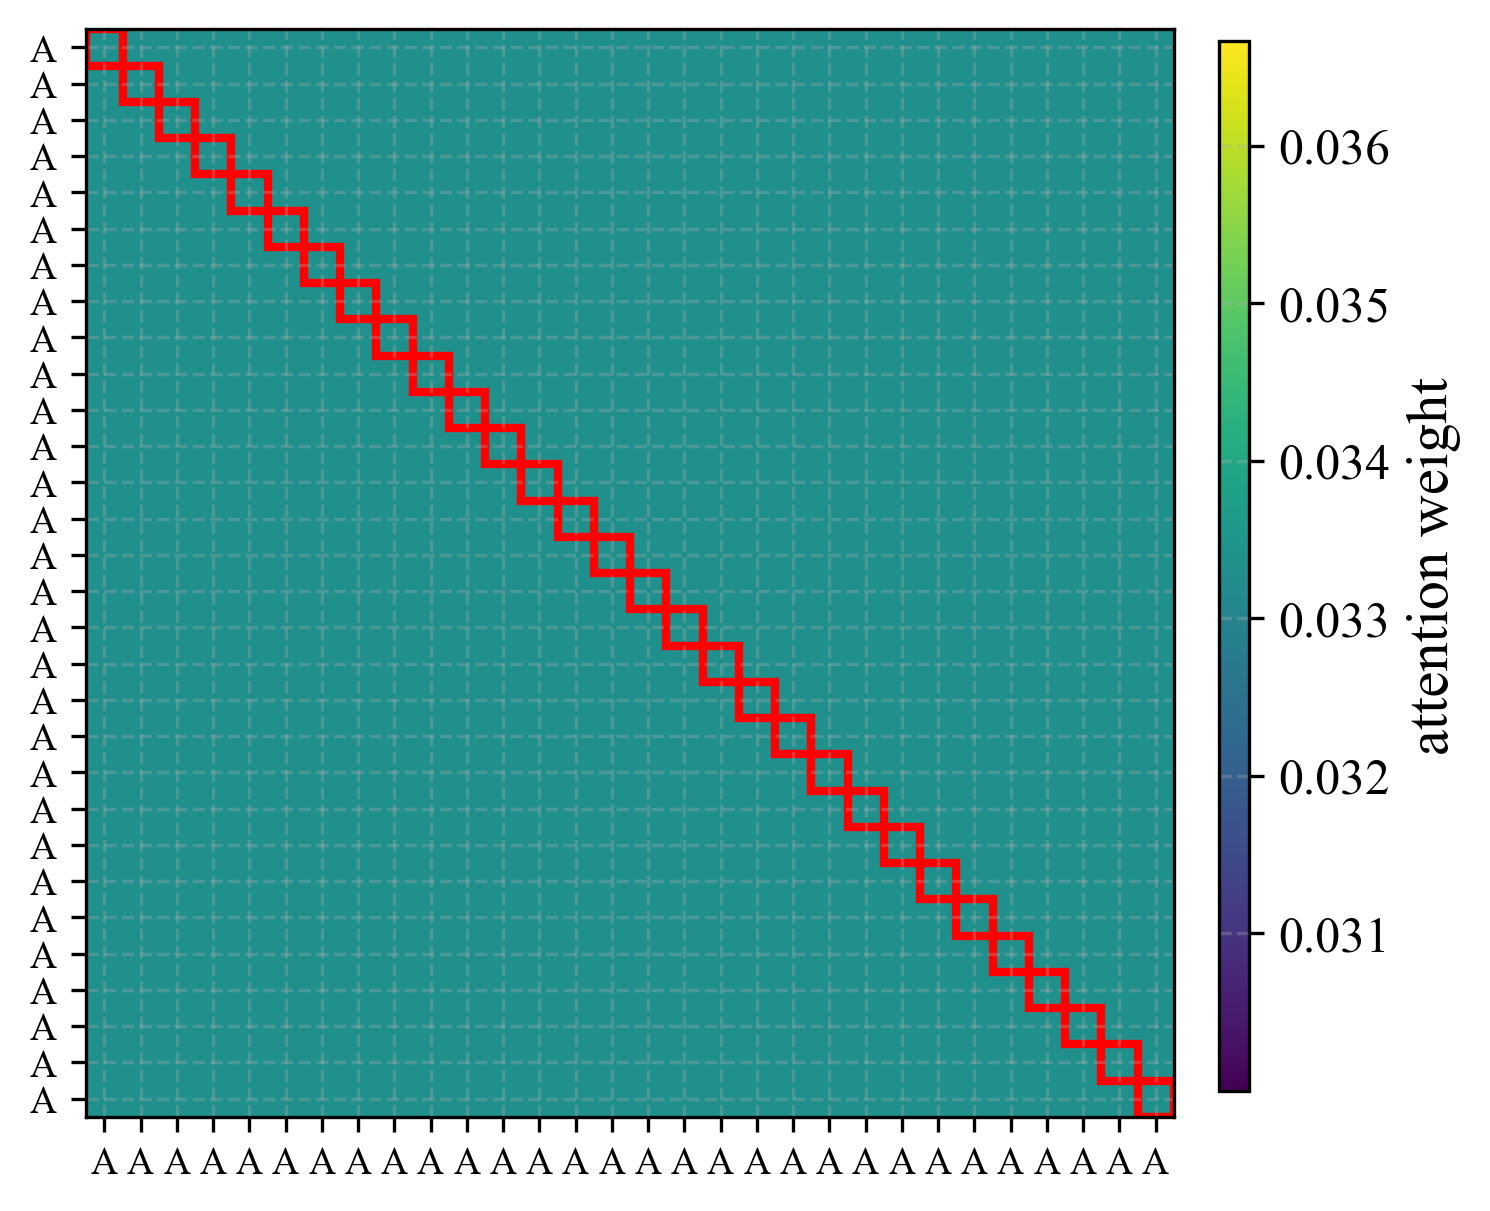

Processing file: attn_5.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_5_run3.png


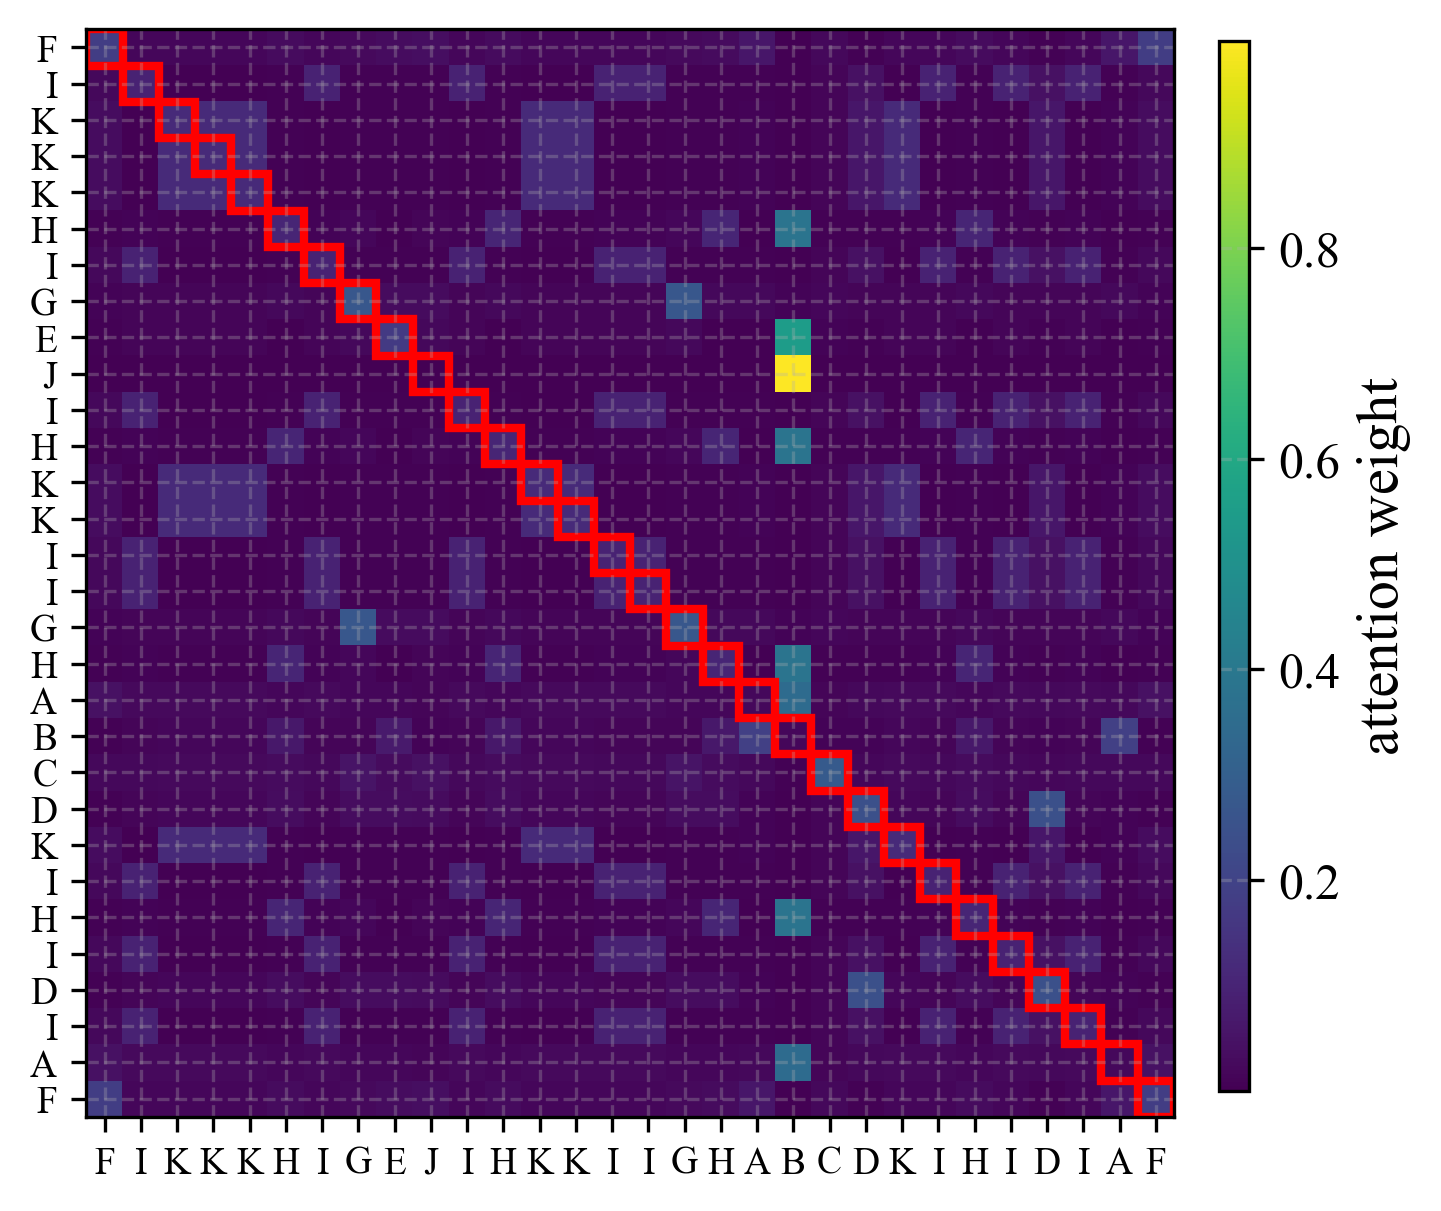

Processing file: attn_6.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_6_run3.png


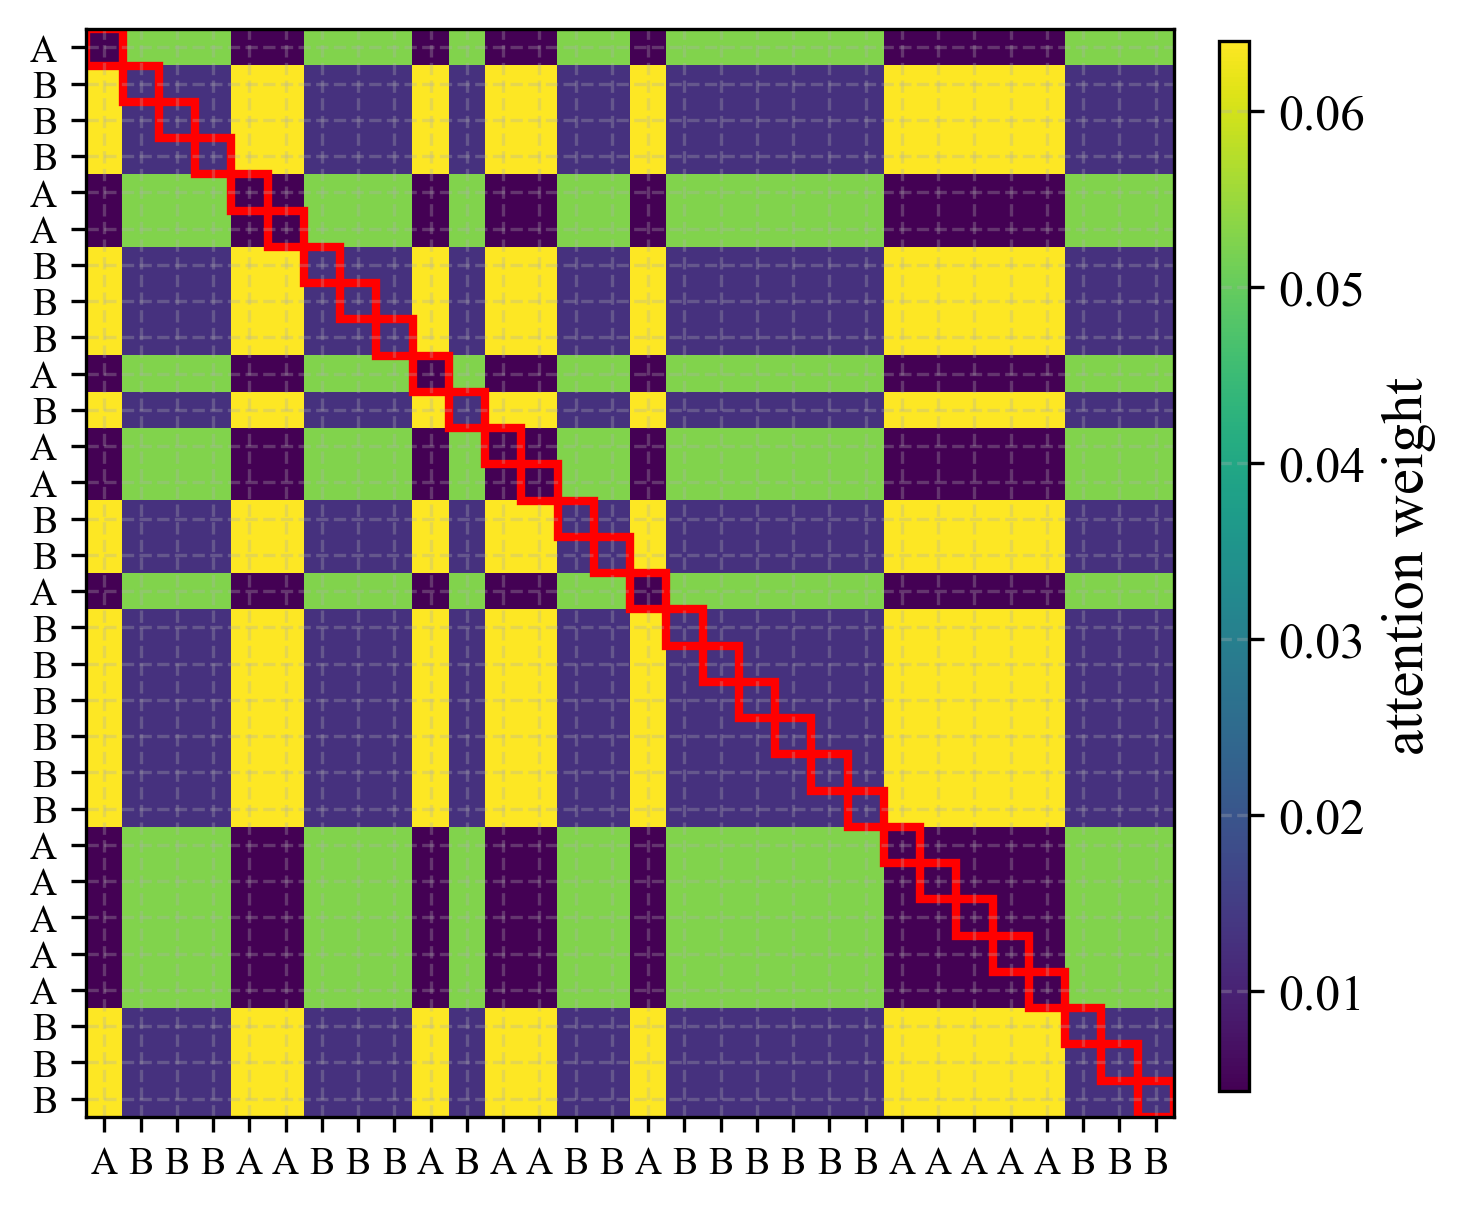

Processing file: attn_7.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_7_run3.png


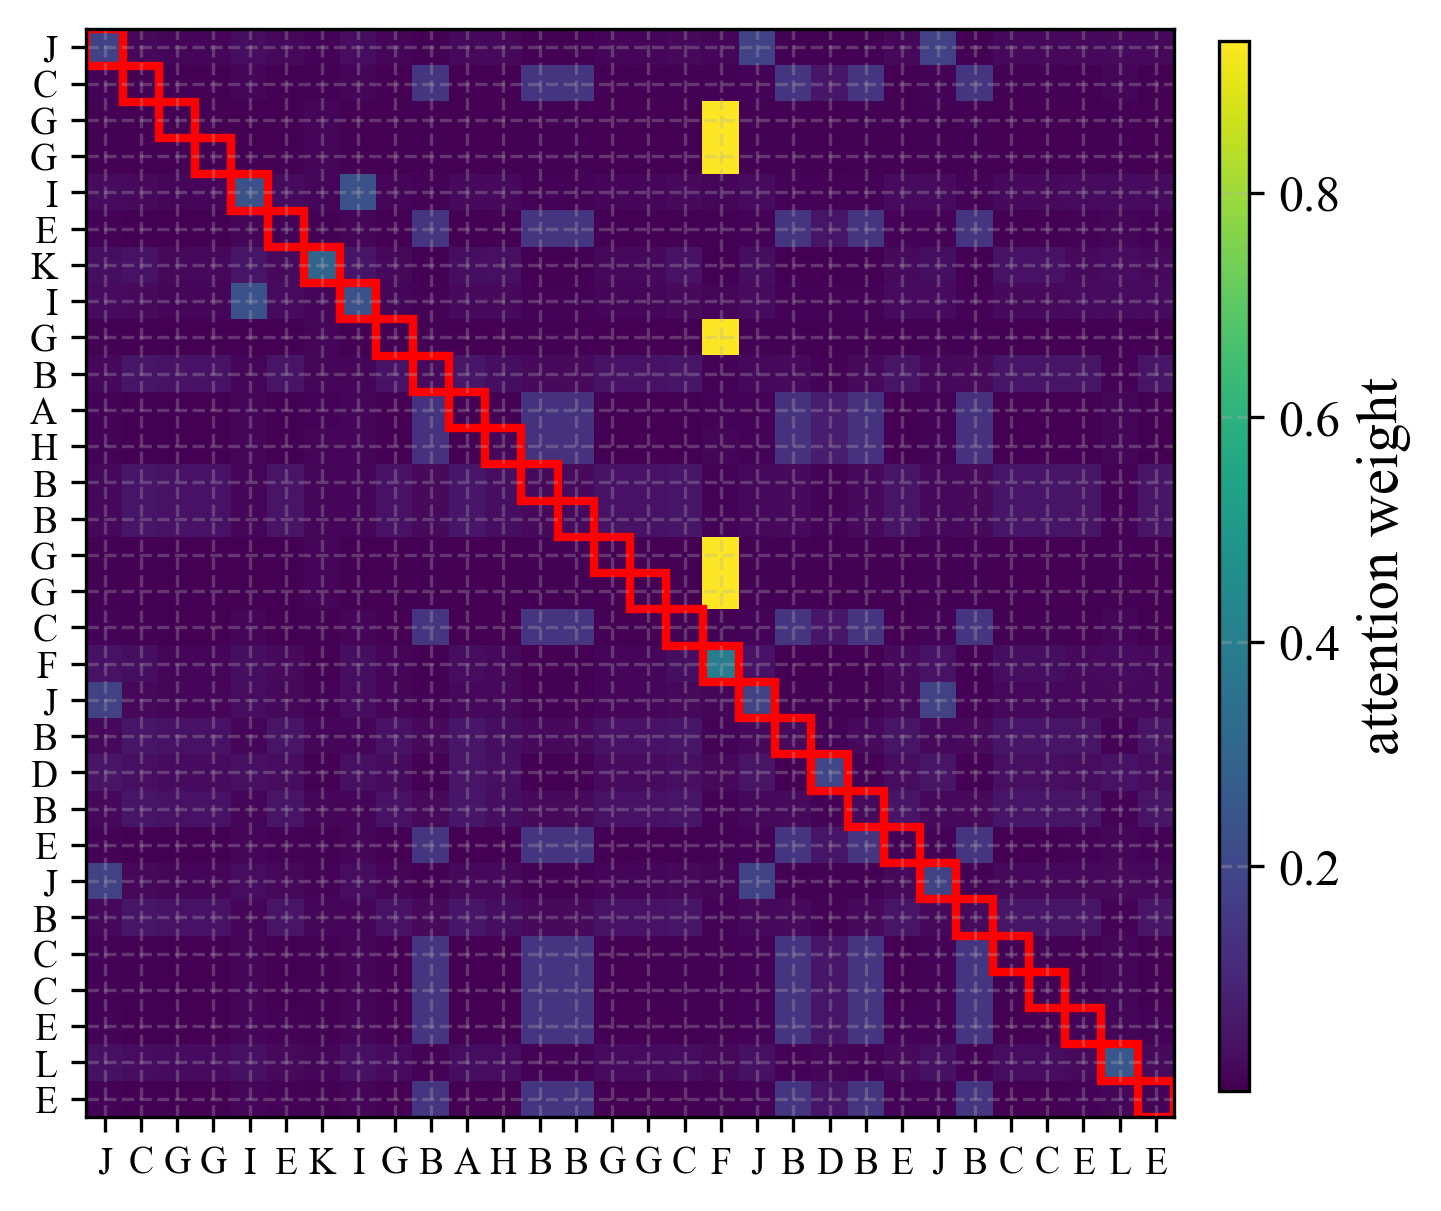

Processing file: attn_8.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_8_run3.png


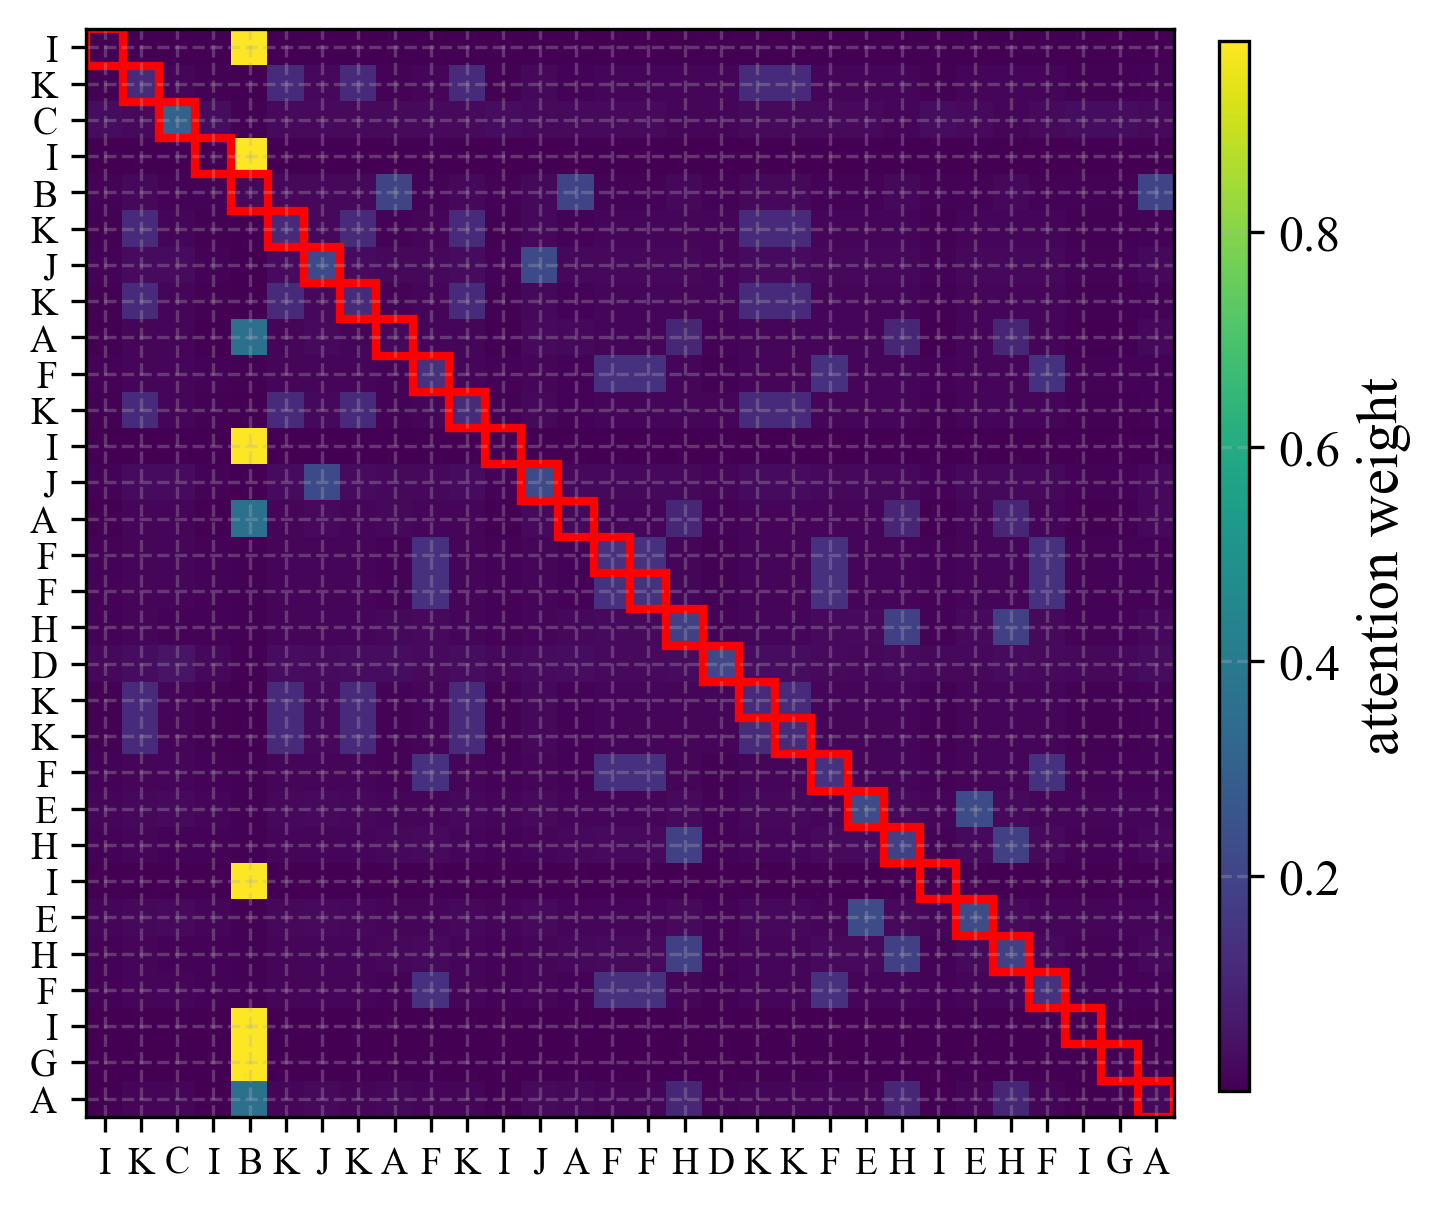

Processing file: attn_9.pkl
✅ Saved plot: ../results/run_20251217_1517/plots/attn_9_run3.png


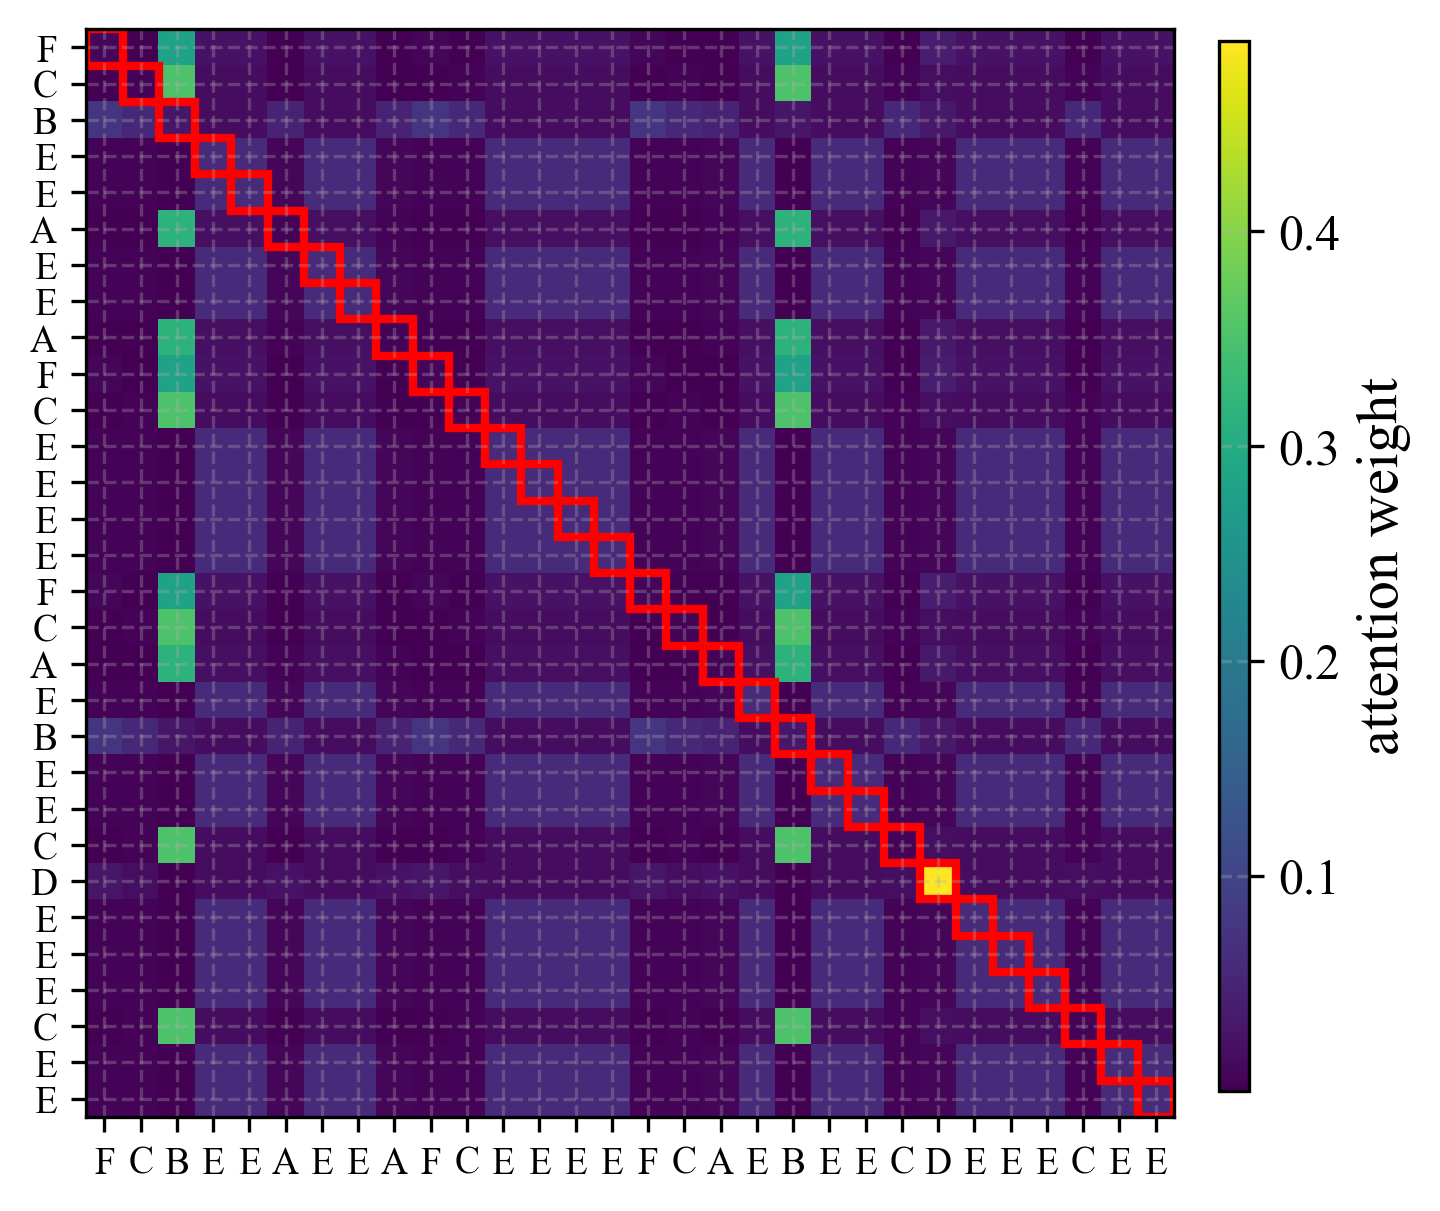

In [58]:
# Load attention and sequences
attn_files = sorted(glob.glob(os.path.join(run_dir, "attn_*.pkl")))
preds_files = sorted(glob.glob(os.path.join(run_dir, "preds_*.pkl")))

print(f"Found {len(attn_files)} attention files and {len(preds_files)} preds files")

# --- Configuration des chemins ---
# Assurez-vous que plot_path est défini avant la boucle
plot_path = os.path.join(run_dir, "plots") # Exemple de dossier de sortie
os.makedirs(plot_path, exist_ok=True) # Crée le dossier s'il n'existe pas

# --- Paramètres ---
NUM_EXAMPLES = 1 
RUN_IDX = 3
alphabet = list(string.ascii_uppercase)

print(f"Les images seront sauvegardées dans : {plot_path}")

for attn_path, preds_path in zip(attn_files, preds_files):

    print(f"Processing file: {os.path.basename(attn_path)}")

    # Load attention
    with open(attn_path, "rb") as f:
        attn_data = pickle.load(f)
    attn_all_runs = np.array(attn_data["attention_matrices"])

    # Load sequences
    with open(preds_path, "rb") as f:
        preds_data = pickle.load(f)
    seq_all_runs = preds_data["sequence_samples"]

    N_runs, N_samples, T, _ = attn_all_runs.shape

    # --- Select examples ---
    attn_examples = attn_all_runs[RUN_IDX, :NUM_EXAMPLES, :, :]
    seq_examples = seq_all_runs[RUN_IDX][:NUM_EXAMPLES]

    # Determine global min/max for colorbar
    vmin = attn_examples.min()
    vmax = attn_examples.max()

    # --- Plot matrices side by side ---
    fig, axes = plt.subplots(1, NUM_EXAMPLES, figsize=(5*NUM_EXAMPLES, 5))

    # Gestion axes unique vs multiple
    if NUM_EXAMPLES == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx in range(NUM_EXAMPLES):
        attn_matrix = attn_examples[idx]
        seq = seq_examples[idx]

        # Sequence → letters
        if seq.ndim == 2:
            token_seq = seq[:,0]
        elif seq.ndim == 1:
            token_seq = seq
        else:
            raise ValueError(f"Unexpected sequence shape: {seq.shape}")

        token_seq = token_seq[:T]
        token_labels = [alphabet[int(x) % len(alphabet)] for x in token_seq]
    
        ax = axes[idx]
        im = ax.imshow(attn_matrix, cmap="viridis", vmin=vmin, vmax=vmax)

        # Axis labels
        ax.set_xticks(np.arange(T))
        ax.set_xticklabels(token_labels, rotation=0, fontsize=9)
        ax.set_yticks(np.arange(T))
        ax.set_yticklabels(token_labels, fontsize=9)

        # Diagonal in red
        for i in range(T):
            rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

    # --- Add colorbar ---
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="attention weight")

    # --- SAVE ---
    # 1. Récupérer le nom de base sans le chemin (ex: 'attn_data_01.pkl')
    base_name = os.path.basename(attn_path)
    # 2. Enlever l'extension .pkl (ex: 'attn_data_01')
    file_root = os.path.splitext(base_name)[0]
    # 3. Créer le nouveau nom .png
    save_name = f"{file_root}_run{RUN_IDX}.png"
    # 4. Joindre avec le dossier de destination
    save_full = os.path.join(plot_path, save_name)
    
    # bbox_inches='tight' enlève les marges blanches excessives
    fig.savefig(save_full, dpi=150, bbox_inches='tight') 
    
    print(f"✅ Saved plot: {save_full}")
    
    plt.show() # Optionnel si vous sauvegardez beaucoup de fichiers
    # plt.close(fig) # IMPORTANT : Ferme la figure pour libérer la mémoire (RAM)

✅ Figure sauvegardée : ../results/run_20251217_1517/plots/Combined_Spectra_Attention_HorizontalColorbars.png


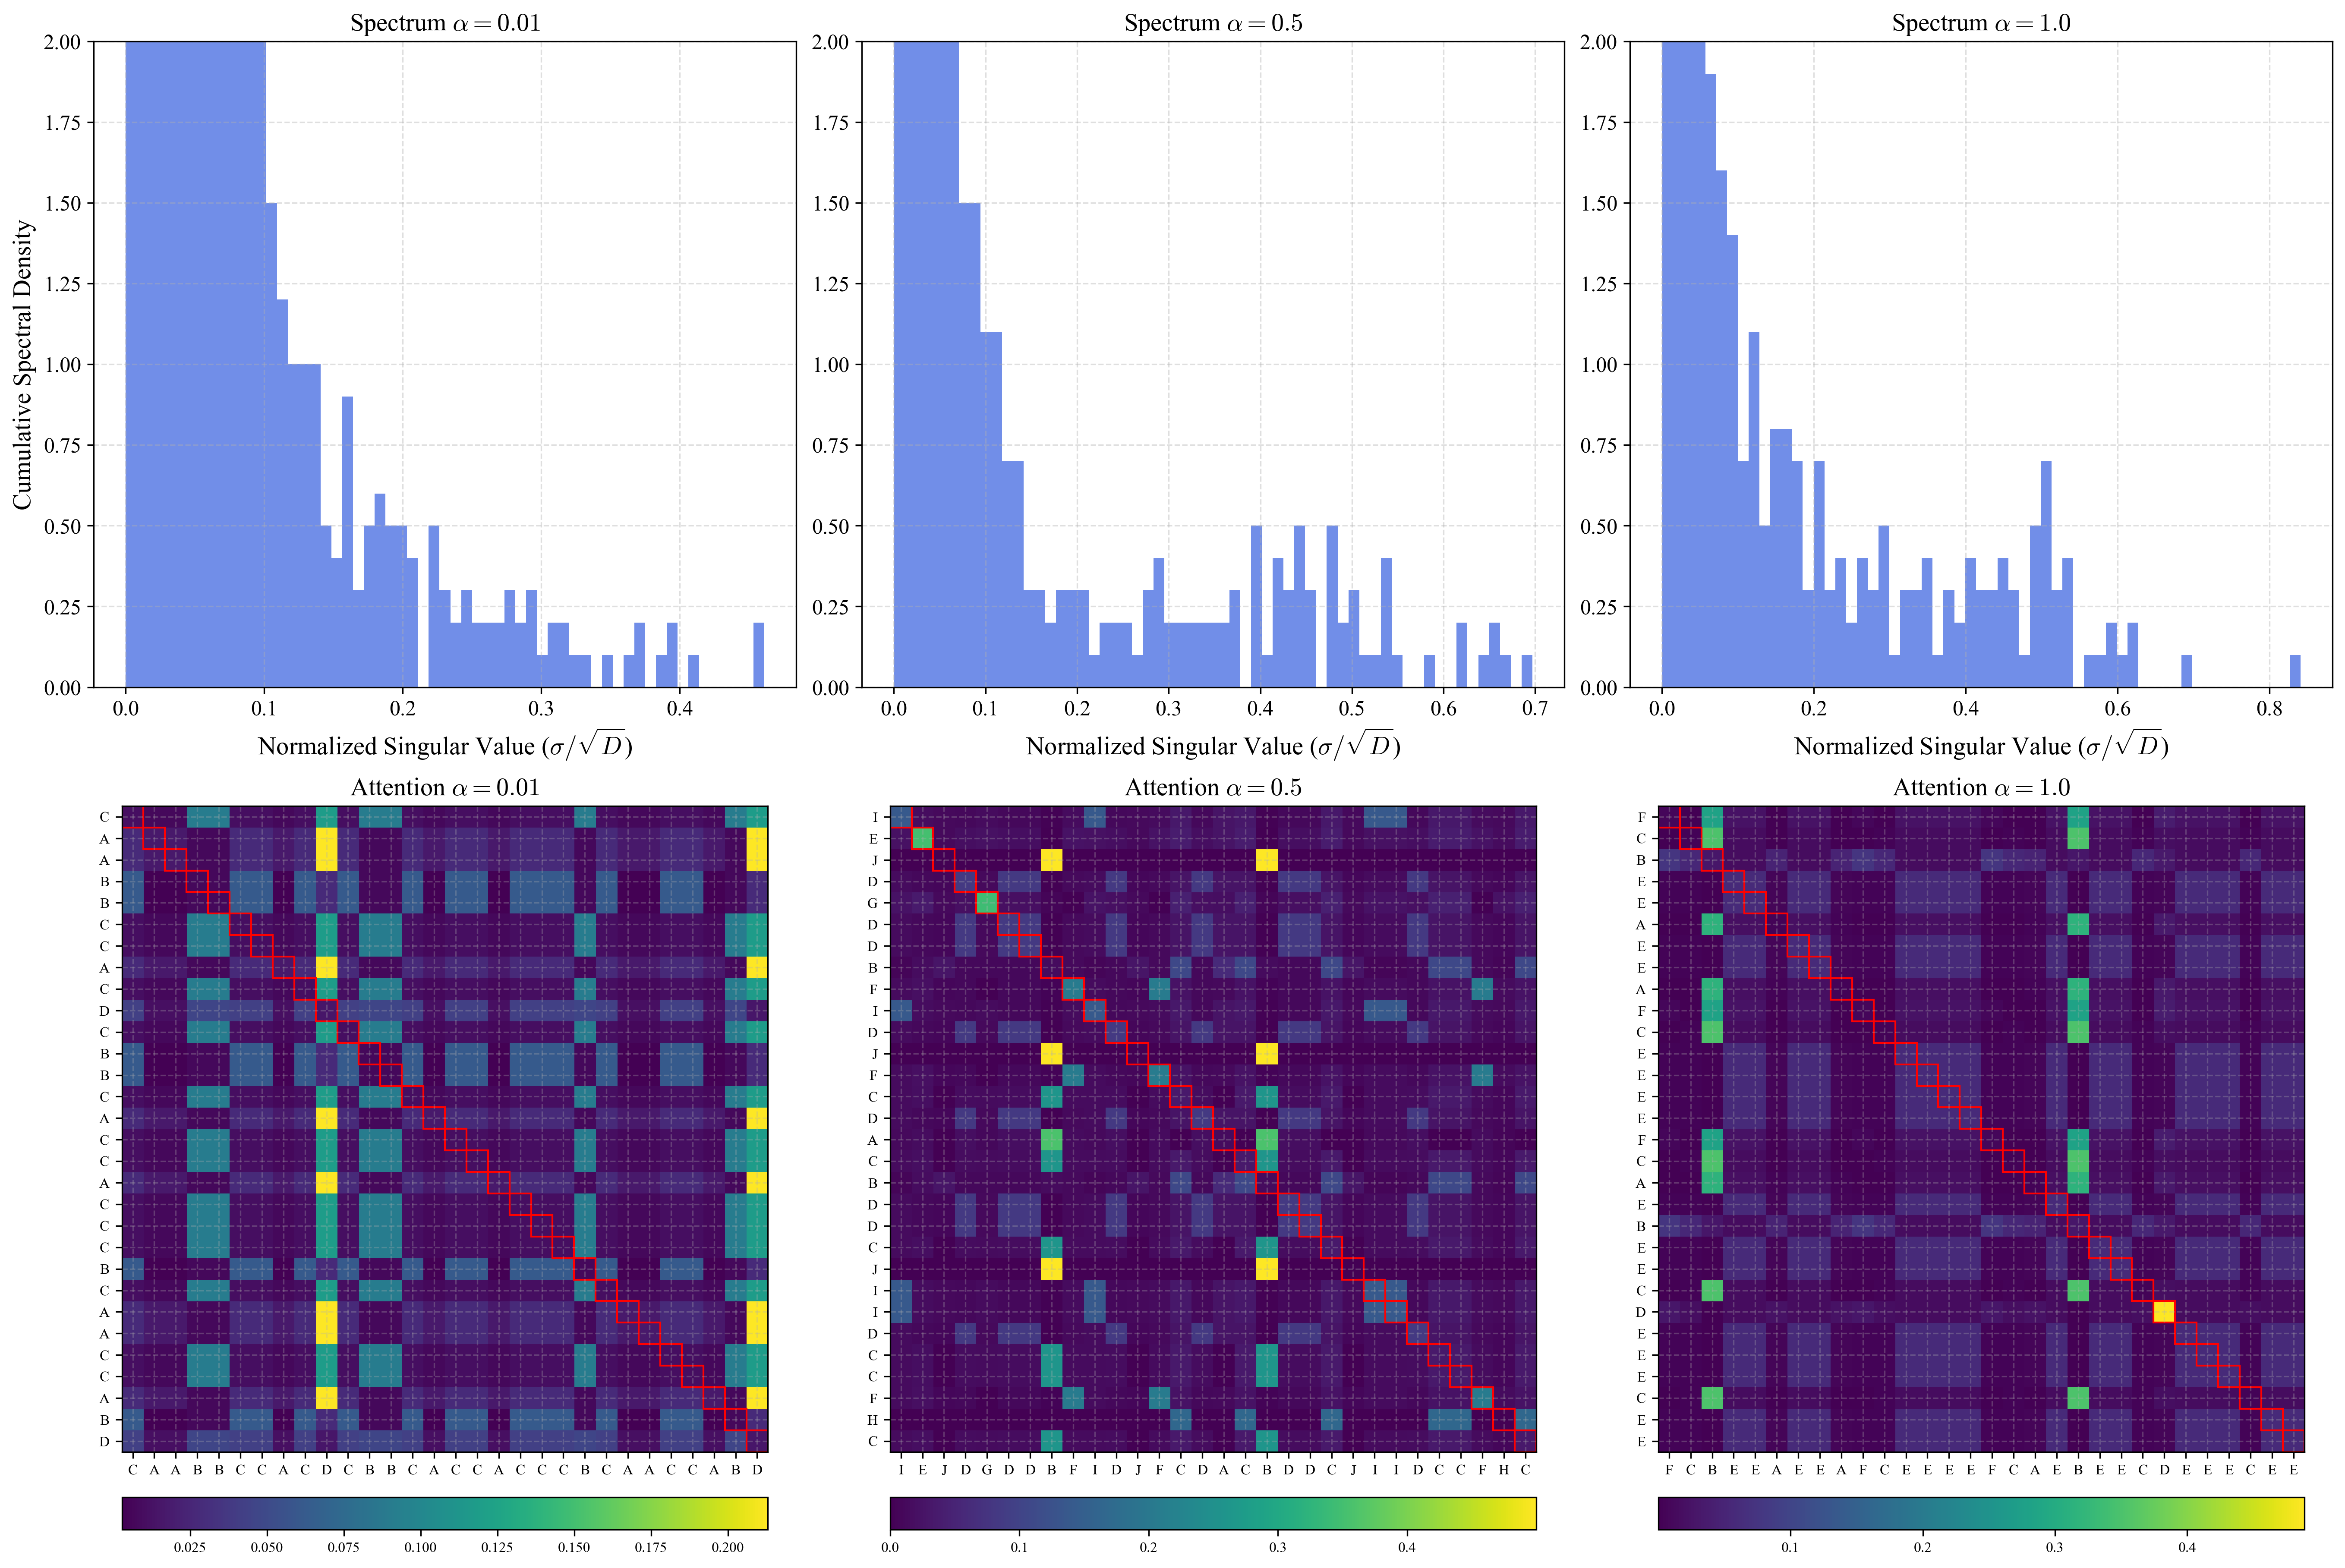

In [59]:
# ==========================================
# 1. CONFIGURATION
# ==========================================

# Indices et Titres
INDICES_TO_PLOT = [0, 5, 14] 
TITLES = [r"$\alpha = 0.01$", r"$\alpha = 0.5$", r"$\alpha = 1.0$"]

RUN_IDX = 3       
SAMPLE_IDX = 0    
alphabet = list(string.ascii_uppercase)

heavy_files = sorted(glob.glob(os.path.join(run_dir, "heavy_data_*.pkl")))
attn_files = sorted(glob.glob(os.path.join(run_dir, "attn_*.pkl")))
preds_files = sorted(glob.glob(os.path.join(run_dir, "preds_*.pkl")))

# ==========================================
# 2. GÉNÉRATION DE LA FIGURE
# ==========================================

# On augmente un peu la hauteur (12) pour accommoder les colorbars en bas
fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)

for col, file_idx in enumerate(INDICES_TO_PLOT):
    
    current_title = TITLES[col]

    # --- CHARGEMENT ---
    with open(heavy_files[file_idx], "rb") as f:
        h_data = pickle.load(f)
    W_runs = h_data.get("W_runs", [])
    
    with open(attn_files[file_idx], "rb") as f:
        a_data = pickle.load(f)
    with open(preds_files[file_idx], "rb") as f:
        p_data = pickle.load(f)
        
    # --- PLOT 1 : SPECTRE (Haut) ---
    ax_spec = axes[0, col]
    
    if len(W_runs) > 0:
        all_singvals = []
        for W in W_runs:
            s = np.linalg.eigvalsh(W)
            all_singvals.append(s)
        all_singvals = np.concatenate(all_singvals)
        
        bins = np.linspace(all_singvals.min(), all_singvals.max(), 60)
        hist, _ = np.histogram(all_singvals, bins=bins)
        hist = hist / len(W_runs)
        
        ax_spec.bar((bins[:-1] + bins[1:]) / 2, hist, width=np.diff(bins), alpha=0.75, color="royalblue")
    
    ax_spec.set_title(f"Spectrum {current_title}", fontsize=14)
    ax_spec.set_xlabel(r"Normalized Singular Value ($\sigma / \sqrt{D}$)")
    ax_spec.set_ylim(0, 2) 
    ax_spec.grid(True, linestyle="--", alpha=0.4)
    if col == 0:
        ax_spec.set_ylabel("Cumulative Spectral Density")

    # --- PLOT 2 : MATRICE (Bas) ---
    ax_attn = axes[1, col]
    
    attn_matrix = np.array(a_data["attention_matrices"])[RUN_IDX, SAMPLE_IDX]
    seq = p_data["sequence_samples"][RUN_IDX][SAMPLE_IDX]
    T = attn_matrix.shape[0]

    # Séquence -> Lettres
    if seq.ndim == 2: seq = seq[:, 0]
    token_seq = seq[:T]
    token_labels = [alphabet[int(x) % len(alphabet)] for x in token_seq]

    # Affichage
    im = ax_attn.imshow(attn_matrix, cmap="viridis") 
    
    ax_attn.set_title(f"Attention {current_title}", fontsize=14, loc='center')
    
    # Axes
    ax_attn.set_xticks(np.arange(T))
    ax_attn.set_xticklabels(token_labels, fontsize=8)
    ax_attn.set_yticks(np.arange(T))
    ax_attn.set_yticklabels(token_labels, fontsize=8)
    
    # Diagonale rouge
    for i in range(T):
        rect = Rectangle((i-0.5, i-0.5), 1, 1, linewidth=1, edgecolor='red', facecolor='none')
        ax_attn.add_patch(rect)

    # --- COLORBAR HORIZONTALE ---
    # orientation='horizontal' : couche la barre
    # location='bottom' : la force en bas
    # fraction=0.05 : définit l'épaisseur de la barre (5% de la hauteur du plot)
    # pad=0.15 : pousse la barre vers le bas pour laisser la place aux lettres (A, B, C...)
    cbar = plt.colorbar(im, ax=ax_attn, 
                        orientation='horizontal', 
                        location='bottom',
                        fraction=0.05, 
                        pad=0.03)
    cbar.ax.tick_params(labelsize=8)

# ==========================================
# 3. SAUVEGARDE
# ==========================================

save_name = "Combined_Spectra_Attention_HorizontalColorbars.png"
full_path = os.path.join(plot_path, save_name)

# plt.suptitle("Impact of Sample Complexity on Spectral Concentration and Attention Structure", fontsize=16)

plt.savefig(full_path, dpi=300, bbox_inches='tight')

print(f"✅ Figure sauvegardée : {full_path}")
plt.show()